# 40K Points Regression & Maximum Damage Analysis

Analyzes the correlation between unit points costs and their abilities/statistics,
then finds the highest-damage combos against templated targets.

In [1]:
import json, os, re, math, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

REPO = Path('/Users/will.mitchell/40kdc-data')
ARMY_ASSIST = Path(os.path.expanduser('~/army-assist/src/assets/json'))
DATA = REPO / 'data' / 'core'

print(f"Factions: {len([d for d in DATA.iterdir() if d.is_dir() and not d.name.startswith('_')])}")
print(f"Army-assist files: {len(list(ARMY_ASSIST.glob('*.json')))}")

Factions: 35
Army-assist files: 26


## Damage Engine

Rules-accurate 10th edition attack sequence. Key interactions:
- Lethal Hits + Devastating Wounds **don't combo** (auto-wound ≠ Critical Wound)
- Sustained Hits extra hits **don't get** Lethal Hits (only original crit benefits)
- Torrent = auto-hit = **no crits** possible
- Crits on **unmodified** rolls only; modifiers capped at ±1
- Overkill damage **lost** (no spillover to next model)
- DW mortal wounds **don't spill** on model death

In [2]:
def resolve_dice(val) -> float:
    """Convert a stat value (int, str dice expression) to expected value.
    Examples: 1 → 1.0, 'D6' → 3.5, '2D6' → 7.0, 'D6+1' → 4.5, 'D3' → 2.0, '2D3+1' → 5.0
    """
    if isinstance(val, (int, float)):
        return float(val)
    if val is None:
        return 0.0
    s = str(val).strip().upper()
    if not s or s in ('N/A', '-', '*', 'MELEE'):
        return 0.0
    # Try plain integer
    try:
        return float(s)
    except ValueError:
        pass
    # Parse dice: optional multiplier, D, sides, optional +/- constant
    m = re.match(r'^(\d*)D(\d+)\s*([+-]\s*\d+)?$', s)
    if m:
        count = int(m.group(1)) if m.group(1) else 1
        sides = int(m.group(2))
        bonus = int(m.group(3).replace(' ', '')) if m.group(3) else 0
        return count * (sides + 1) / 2.0 + bonus
    # Fallback
    try:
        return float(s)
    except ValueError:
        return 0.0



def max_dice_value(val) -> float:
    """Like resolve_dice but returns maximum possible value."""
    if isinstance(val, (int, float)):
        return float(val)
    if val is None:
        return 0.0
    s = str(val).strip().upper()
    if not s or s in ('N/A', '-', '*', 'MELEE'):
        return 0.0
    try:
        return float(s)
    except ValueError:
        pass
    m = re.match(r'^(\d*)D(\d+)\s*([+-]\s*\d+)?$', s)
    if m:
        count = int(m.group(1)) if m.group(1) else 1
        sides = int(m.group(2))
        bonus = int(m.group(3).replace(' ', '')) if m.group(3) else 0
        return count * sides + bonus  # max = count * max_per_die + bonus
    try:
        return float(s)
    except ValueError:
        return 0.0

@dataclass
class TargetProfile:
    """Defensive profile of a target unit."""
    name: str
    models: int
    T: int
    W: int
    Sv: int
    invuln: Optional[int] = None  # e.g., 4 means 4+
    fnp: Optional[int] = None     # e.g., 5 means 5+
    damage_reduction: int = 0     # e.g., 1 for Necrodermis
    keywords: list = field(default_factory=list)


@dataclass
class Buffs:
    """Accumulated buffs from abilities, detachment, stratagems, leader, enhancement."""
    hit_mod: int = 0           # +1/-1 to hit (before capping)
    wound_mod: int = 0         # +1/-1 to wound (before capping)
    reroll_hits: str = 'none'  # 'none', '1s', 'all'
    reroll_wounds: str = 'none'
    reroll_damage: bool = False
    extra_attacks: int = 0
    extra_ap: int = 0          # improve AP by this much (positive = more negative AP)
    extra_strength: int = 0
    extra_damage: int = 0
    grant_lethal_hits: bool = False
    grant_sustained_hits: int = 0  # X value
    grant_devastating_wounds: bool = False
    grant_twin_linked: bool = False
    assume_stationary: bool = True   # for Heavy keyword
    assume_charged: bool = False     # for Lance keyword
    assume_half_range: bool = True   # for Melta/Rapid Fire (max damage scenario)
    miracle_dice: int = 0             # best-of hit/wound/damage guarantee
    guaranteed_crit_hits: int = 0    # (internal) auto-6 on hit roll
    guaranteed_crit_wounds: int = 0  # (internal) auto-6 on wound roll
    guaranteed_max_damage: int = 0   # (internal) max damage on one wound
    target_toughness_mod: int = 0   # applied to target T (negative = reduce T)


def parse_weapon_keywords(keywords: list[str]) -> dict:
    """Extract structured keyword effects from a weapon's keyword list.
    All comparisons are case-insensitive.
    """
    result = {
        'torrent': False,
        'blast': False,
        'lethal_hits': False,
        'sustained_hits': 0,
        'devastating_wounds': False,
        'twin_linked': False,
        'lance': False,
        'heavy': False,
        'rapid_fire': 0,
        'melta': 0,
        'indirect_fire': False,
        'ignores_cover': False,
        'precision': False,
        'extra_attacks': False,
        'anti': [],  # list of (keyword, threshold) tuples
        'hazardous': False,
        'assault': False,
        'pistol': False,
        'psychic': False,
        'one_shot': False,
    }
    for kw in keywords:
        kw_lower = kw.lower().strip()
        if kw_lower == 'torrent':
            result['torrent'] = True
        elif kw_lower == 'blast':
            result['blast'] = True
        elif kw_lower == 'lethal hits':
            result['lethal_hits'] = True
        elif kw_lower == 'devastating wounds':
            result['devastating_wounds'] = True
        elif kw_lower == 'twin-linked':
            result['twin_linked'] = True
        elif kw_lower == 'lance':
            result['lance'] = True
        elif kw_lower == 'heavy':
            result['heavy'] = True
        elif kw_lower == 'indirect fire':
            result['indirect_fire'] = True
        elif kw_lower == 'ignores cover':
            result['ignores_cover'] = True
        elif kw_lower == 'precision':
            result['precision'] = True
        elif kw_lower == 'extra attacks':
            result['extra_attacks'] = True
        elif kw_lower == 'hazardous':
            result['hazardous'] = True
        elif kw_lower == 'assault':
            result['assault'] = True
        elif kw_lower == 'pistol':
            result['pistol'] = True
        elif kw_lower == 'psychic':
            result['psychic'] = True
        elif kw_lower == 'one shot':
            result['one_shot'] = True
        else:
            # Sustained Hits X
            m = re.match(r'sustained hits (\d+|d\d+)', kw_lower)
            if m:
                result['sustained_hits'] = int(resolve_dice(m.group(1)))
                continue
            # Rapid Fire X
            m = re.match(r'rapid fire (\d+|d\d+)', kw_lower)
            if m:
                result['rapid_fire'] = int(resolve_dice(m.group(1)))
                continue
            # Melta X
            m = re.match(r'melta (\d+)', kw_lower)
            if m:
                result['melta'] = int(m.group(1))
                continue
            # Anti-KEYWORD X+
            m = re.match(r'anti-(.+?)\s+(\d+)\+', kw_lower)
            if m:
                anti_kw = m.group(1).strip()
                anti_threshold = int(m.group(2))
                result['anti'].append((anti_kw, anti_threshold))
                continue
    return result


def _clamp(val, lo, hi):
    return max(lo, min(hi, val))


def expected_damage(
    weapon_stats: dict,     # {A, BS or WS, S, AP, D} + keywords list
    weapon_type: str,       # 'ranged' or 'melee'
    n_models: int,          # number of attacking models
    target: TargetProfile,
    buffs: Buffs = None,
) -> dict:
    """Compute expected damage from a weapon profile against a target.
    
    Returns dict with:
      - 'models_killed' (for multi-model targets) or 'wounds_inflicted' (single model)
      - 'damage_per_model': damage from one attacking model
      - intermediate values for debugging
    """
    if buffs is None:
        buffs = Buffs()
    
    stats = weapon_stats
    kw = parse_weapon_keywords(stats.get('keywords', []))
    
    # Miracle Dice: pick the best of guaranteed hit/wound/damage
    if buffs.miracle_dice > 0:
        from copy import copy
        best_result = None
        for _field in ['guaranteed_crit_hits', 'guaranteed_crit_wounds', 'guaranteed_max_damage']:
            b = copy(buffs)
            b.miracle_dice = 0
            setattr(b, _field, buffs.miracle_dice)
            r = expected_damage(weapon_stats, weapon_type, n_models, target, b)
            if best_result is None or r.get('wounds_inflicted', 0) > best_result.get('wounds_inflicted', 0):
                best_result = r
        return best_result

    # --- STEP 1: Attack count ---
    base_A = resolve_dice(stats.get('A', 0)) + buffs.extra_attacks
    if kw['blast']:
        base_A += target.models // 5
    if kw['rapid_fire'] and buffs.assume_half_range:
        base_A += kw['rapid_fire']
    
    total_attacks = base_A * n_models
    if total_attacks <= 0:
        return {'models_killed': 0, 'wounds_inflicted': 0, 'damage_per_model': 0, 'total_attacks': 0}
    
    # --- STEP 2: Hit rolls ---
    skill_key = 'BS' if weapon_type == 'ranged' else 'WS'
    skill = stats.get(skill_key)
    if skill is None or skill == 0:
        if kw['torrent']:
            skill = 6  # won't matter, auto-hits
        else:
            return {'models_killed': 0, 'wounds_inflicted': 0, 'damage_per_model': 0, 'total_attacks': total_attacks}
    
    if kw['torrent']:
        normal_hits = total_attacks
        crit_hits = 0.0
    else:
        # Hit modifier: sum from buffs + Heavy, capped at +1/-1
        raw_hit_mod = buffs.hit_mod
        if kw['heavy'] and buffs.assume_stationary:
            raw_hit_mod += 1
        hit_mod = _clamp(raw_hit_mod, -1, 1)
        
        effective_bs = _clamp(skill - hit_mod, 2, 6)
        
        # P(miss) — nat 1 always misses
        p_miss = max(1, effective_bs - 1) / 6.0
        p_crit_hit = 1.0 / 6.0  # unmodified 6
        p_normal_hit = max(0.0, 1.0 - p_miss - p_crit_hit)
        
        # Rerolls (before modifiers)
        if buffs.reroll_hits == 'all':
            p_hit_total = p_normal_hit + p_crit_hit
            p_normal_hit += p_miss * (p_normal_hit / max(p_hit_total, 1e-9)) * p_hit_total
            p_crit_hit_new = p_crit_hit + p_miss * p_crit_hit
            p_normal_hit = p_normal_hit + p_miss * p_normal_hit - (p_crit_hit_new - p_crit_hit) * 0  # redo clean
            # Clean recalculation
            p_normal_hit_orig = max(0.0, 1.0 - max(1, effective_bs - 1) / 6.0 - 1.0/6.0)
            p_crit_orig = 1.0/6.0
            p_miss_orig = 1.0 - p_normal_hit_orig - p_crit_orig
            p_crit_hit = p_crit_orig + p_miss_orig * p_crit_orig
            p_normal_hit = p_normal_hit_orig + p_miss_orig * p_normal_hit_orig
        elif buffs.reroll_hits == '1s':
            # Reroll natural 1s only (1/6 chance of rolling a 1)
            p_reroll = 1.0 / 6.0
            p_normal_hit_orig = max(0.0, 1.0 - max(1, effective_bs - 1) / 6.0 - 1.0/6.0)
            p_crit_orig = 1.0/6.0
            p_crit_hit = p_crit_orig + p_reroll * p_crit_orig
            p_normal_hit = p_normal_hit_orig + p_reroll * p_normal_hit_orig
        
        normal_hits = total_attacks * p_normal_hit
        crit_hits = total_attacks * p_crit_hit
    
    # Guaranteed crit hits: auto-6s that replace regular attacks
    if buffs.guaranteed_crit_hits > 0 and total_attacks > 0:
        guaranteed = min(buffs.guaranteed_crit_hits, total_attacks)
        if not kw['torrent']:  # Torrent auto-hits, no crits to inject
            ratio = (total_attacks - guaranteed) / total_attacks
            normal_hits *= ratio
            crit_hits = crit_hits * ratio + guaranteed

    # --- STEP 3: Process critical hits ---
    # Sustained Hits: use weapon's value OR buff's grant, whichever is higher (don't stack)
    sustained_x = max(kw['sustained_hits'], buffs.grant_sustained_hits)
    additional_hits = crit_hits * sustained_x  # auto-successful, need wound rolls
    
    # Lethal Hits
    has_lethal = kw['lethal_hits'] or buffs.grant_lethal_hits
    if has_lethal:
        auto_wounds = crit_hits  # bypass wound roll, NOT a Critical Wound
        hits_to_wound = normal_hits + additional_hits
    else:
        auto_wounds = 0.0
        hits_to_wound = normal_hits + crit_hits + additional_hits
    
    # --- STEP 4: Wound rolls ---
    S = resolve_dice(stats.get('S', 0)) + buffs.extra_strength
    T = max(1, target.T + buffs.target_toughness_mod)
    
    if S <= 0 or T <= 0:
        return {'models_killed': 0, 'wounds_inflicted': 0, 'damage_per_model': 0, 'total_attacks': total_attacks}
    
    if S >= 2 * T:
        wound_threshold = 2
    elif S > T:
        wound_threshold = 3
    elif S == T:
        wound_threshold = 4
    elif 2 * S >= T:  # S < T but S > T/2
        wound_threshold = 5
    else:  # S <= T/2
        wound_threshold = 6
    
    # Wound modifier: buffs + Lance, capped at +1/-1
    raw_wound_mod = buffs.wound_mod
    if kw['lance'] and buffs.assume_charged:
        raw_wound_mod += 1
    wound_mod = _clamp(raw_wound_mod, -1, 1)
    effective_wound = _clamp(wound_threshold - wound_mod, 2, 6)
    
    # Critical wound threshold (default 6, Anti-X can lower it)
    crit_wound_threshold = 6
    target_kw_lower = [k.lower() for k in target.keywords]
    for anti_kw, anti_val in kw['anti']:
        if anti_kw.lower() in target_kw_lower:
            crit_wound_threshold = min(crit_wound_threshold, anti_val)
    
    # Wound probabilities
    p_crit_wound = (7 - crit_wound_threshold) / 6.0
    p_wound_base = (7 - effective_wound) / 6.0
    # Natural 6 always wounds, natural 1 always fails
    p_wound_total = max(p_crit_wound, p_wound_base)
    p_non_crit_wound = max(0.0, p_wound_total - p_crit_wound)
    
    # Twin-linked or reroll wounds
    has_twin_linked = kw['twin_linked'] or buffs.grant_twin_linked
    if has_twin_linked or buffs.reroll_wounds == 'all':
        p_fail_wound = 1.0 - p_wound_total
        p_crit_wound_final = p_crit_wound + p_fail_wound * p_crit_wound
        p_non_crit_wound_final = p_non_crit_wound + p_fail_wound * p_non_crit_wound
    elif buffs.reroll_wounds == '1s':
        p_reroll = 1.0 / 6.0
        p_crit_wound_final = p_crit_wound + p_reroll * p_crit_wound
        p_non_crit_wound_final = p_non_crit_wound + p_reroll * p_non_crit_wound
    else:
        p_crit_wound_final = p_crit_wound
        p_non_crit_wound_final = p_non_crit_wound
    
    crit_wounds = hits_to_wound * p_crit_wound_final
    non_crit_wounds = hits_to_wound * p_non_crit_wound_final
    
    # Guaranteed crit wounds: auto-6s that replace regular wound rolls
    if buffs.guaranteed_crit_wounds > 0 and hits_to_wound > 0:
        gw = min(buffs.guaranteed_crit_wounds, hits_to_wound)
        ratio_w = (hits_to_wound - gw) / hits_to_wound
        crit_wounds = crit_wounds * ratio_w + gw
        non_crit_wounds *= ratio_w

    # --- STEP 5: Process critical wounds ---
    has_dw = kw['devastating_wounds'] or buffs.grant_devastating_wounds
    if has_dw:
        dw_wounds = crit_wounds  # mortal wounds, skip save
        normal_wounds = auto_wounds + non_crit_wounds
    else:
        dw_wounds = 0.0
        normal_wounds = auto_wounds + non_crit_wounds + crit_wounds
    
    # --- STEP 6: Saving throws (normal wounds only) ---
    AP = stats.get('AP', 0) - buffs.extra_ap  # extra_ap makes AP more negative
    modified_save = target.Sv - AP  # AP is negative, so Sv - (-2) = Sv + 2
    effective_save = modified_save
    if target.invuln is not None:
        effective_save = min(modified_save, target.invuln)
    
    p_save = _clamp((7 - effective_save) / 6.0, 0.0, 5.0/6.0)  # nat 1 fails
    p_fail_save = 1.0 - p_save
    
    unsaved_wounds = normal_wounds * p_fail_save
    
    # --- STEP 7: Inflict damage ---
    base_D = resolve_dice(stats.get('D', 0)) + buffs.extra_damage
    if kw['melta'] and buffs.assume_half_range:
        base_D += kw['melta']
    # Damage reduction (e.g., Necrodermis), min 1
    eff_D = max(base_D - target.damage_reduction, 1.0)
    
    # Reroll damage
    if buffs.reroll_damage and isinstance(stats.get('D'), str):
        # Approximate reroll: if dice, expected value is higher
        # E[max(D, D)] ≈ E[D] * 1.167 for D6, but "reroll damage" typically means
        # reroll the whole damage roll. Simplification: +16.7% for D6, +12.5% for D3
        raw_D = resolve_dice(stats.get('D', 0))
        eff_D = max(raw_D * 1.167 + buffs.extra_damage + (kw['melta'] if buffs.assume_half_range else 0) - target.damage_reduction, 1.0)
    

    # Guaranteed max damage: upgrade N wounds to max possible damage
    if buffs.guaranteed_max_damage > 0:
        max_D_raw = max_dice_value(stats.get('D', 0)) + buffs.extra_damage
        if kw['melta'] and buffs.assume_half_range:
            max_D_raw += kw['melta']
        max_eff_D = max(max_D_raw - target.damage_reduction, 1.0)
        total_wnd = unsaved_wounds + dw_wounds
        if total_wnd > 0 and max_eff_D > eff_D:
            gmd = min(buffs.guaranteed_max_damage, total_wnd)
            eff_D = (eff_D * (total_wnd - gmd) + max_eff_D * gmd) / total_wnd

    # FNP
    p_fnp = (7 - target.fnp) / 6.0 if target.fnp else 0.0
    fnp_passthrough = 1.0 - p_fnp
    
    # --- Compute kills / wounds ---
    if target.models > 1:
        # Multi-model target: account for overkill waste
        # effective_D_per_wound accounts for FNP on each wound point
        eff_D_after_fnp = eff_D * fnp_passthrough
        if eff_D_after_fnp > 0:
            wounds_per_kill = math.ceil(target.W / eff_D_after_fnp)
        else:
            wounds_per_kill = float('inf')
        normal_kills = unsaved_wounds / wounds_per_kill if wounds_per_kill > 0 else 0
        
        # DW path: mortal wounds, no save, no spill on model death
        dw_eff = min(eff_D, target.W) * fnp_passthrough
        dw_kills = dw_wounds * dw_eff / target.W if target.W > 0 else 0
        
        total_kills = min(normal_kills + dw_kills, target.models)
        return {
            'models_killed': total_kills,
            'wounds_inflicted': total_kills * target.W,  # proxy
            'damage_per_model': (normal_kills + dw_kills) * target.W / n_models if n_models > 0 else 0,
            'total_attacks': total_attacks,
            'unsaved_wounds': unsaved_wounds,
            'dw_wounds': dw_wounds,
        }
    else:
        # Single model target
        normal_dmg = unsaved_wounds * eff_D * fnp_passthrough
        dw_dmg = dw_wounds * eff_D * fnp_passthrough
        total_wounds = min(normal_dmg + dw_dmg, target.W)
        return {
            'models_killed': 1.0 if total_wounds >= target.W else 0.0,
            'wounds_inflicted': total_wounds,
            'damage_per_model': (normal_dmg + dw_dmg) / n_models if n_models > 0 else 0,
            'total_attacks': total_attacks,
            'unsaved_wounds': unsaved_wounds,
            'dw_wounds': dw_wounds,
        }

print("Damage engine defined.")

Damage engine defined.


In [3]:
# --- Damage Engine Unit Tests ---

guardsman = TargetProfile("Guardsman", models=20, T=3, W=1, Sv=5)
intercessor = TargetProfile("Intercessor", models=10, T=4, W=2, Sv=3)
terminator = TargetProfile("Terminator", models=5, T=5, W=3, Sv=2, invuln=4, keywords=['Infantry', 'Terminator'])
armiger = TargetProfile("Armiger", models=1, T=9, W=14, Sv=3, invuln=5, keywords=['Vehicle', 'Walker'])
nightbringer = TargetProfile("Nightbringer", models=1, T=11, W=16, Sv=3, invuln=4,
                             fnp=5, damage_reduction=1, keywords=['Monster', 'Character'])

no_buffs = Buffs(assume_stationary=True, assume_half_range=True)

# Test 1: Bolter vs Guardsman
# 1 shot, BS3+, S4, AP0, D1 vs T3/Sv5+
# Hit: 4/6, Wound (S4>T3 → 3+): 4/6, Save (5+ with AP0 → 5+, fails 4/6), D=1
# Expected: 4/6 * 4/6 * 4/6 * 1 = 64/216 ≈ 0.296
bolter = {'A': 1, 'BS': 3, 'S': 4, 'AP': 0, 'D': 1, 'keywords': []}
r = expected_damage(bolter, 'ranged', 1, guardsman, no_buffs)
print(f"Bolter vs guardsman: {r['models_killed']:.4f} kills (expected ~0.296)")
assert abs(r['models_killed'] - 64/216) < 0.01, f"Got {r['models_killed']}"

# Test 2: Lascannon vs Armiger
# 1 shot, BS3+, S12, AP-3, D(D6+1=4.5) vs T9/Sv3+/5++
# Hit: 4/6, Wound (S12>T9 → 3+): 4/6
# Save: modified = 3-(-3)=6+, invuln=5+; use 5+. P(save)=2/6, P(fail)=4/6
# D=4.5
# Expected: 4/6 * 4/6 * 4/6 * 4.5 = 1.333
lascannon = {'A': 1, 'BS': 3, 'S': 12, 'AP': -3, 'D': 'D6+1', 'keywords': []}
r = expected_damage(lascannon, 'ranged', 1, armiger, no_buffs)
print(f"Lascannon vs armiger: {r['wounds_inflicted']:.3f} wounds (expected ~1.333)")
assert abs(r['wounds_inflicted'] - 4/6 * 4/6 * 4/6 * 4.5) < 0.05

# Test 3: Multi-melta at half range vs Armiger (Melta 2)
# 1 shot, BS3+, S9, AP-4, D(D6+2=5.5) + Melta 2 = 7.5 vs T9/Sv3+/5++
# Hit: 4/6, Wound (S9=T9 → 4+): 3/6
# Save: 3-(-4)=7+, invuln=5+; use 5+. P(fail)=4/6
# Expected: 4/6 * 3/6 * 4/6 * 7.5 ≈ 1.667
multimelta = {'A': 1, 'BS': 3, 'S': 9, 'AP': -4, 'D': 'D6+2', 'keywords': ['Melta 2']}
r = expected_damage(multimelta, 'ranged', 1, armiger, no_buffs)
print(f"Multi-melta vs armiger: {r['wounds_inflicted']:.3f} wounds (expected ~1.667)")
assert abs(r['wounds_inflicted'] - 4/6 * 3/6 * 4/6 * 7.5) < 0.05

# Test 4: Torrent weapon — should produce 0 crit hits
flamer = {'A': 'D6', 'BS': None, 'S': 4, 'AP': 0, 'D': 1, 'keywords': ['Torrent', 'Ignores Cover']}
r = expected_damage(flamer, 'ranged', 1, guardsman, no_buffs)
# 3.5 auto-hits, wound 3+ (4/6), save 5+ fails 4/6, D1
# 3.5 * 4/6 * 4/6 = 1.556
print(f"Flamer vs guardsman: {r['models_killed']:.3f} kills (expected ~1.556)")
assert abs(r['models_killed'] - 3.5 * 4/6 * 4/6) < 0.05

# Test 5: Lethal Hits + Devastating Wounds DON'T COMBO
# Weapon with both: crit hits auto-wound via Lethal, but auto-wound ≠ crit wound, so DW never fires
# Use a simple weapon: 6 attacks, BS2+, S4, AP-1, D2
# With both LH+DW: the crit hits should auto-wound and go to save, NOT bypass save
dw_lh_weapon = {'A': 6, 'BS': 2, 'S': 4, 'AP': -1, 'D': 2,
                 'keywords': ['Lethal Hits', 'Devastating Wounds']}
r = expected_damage(dw_lh_weapon, 'ranged', 1, terminator, no_buffs)
# DW should be 0 since Lethal auto-wounds are not Critical Wounds
# The wound roll crits from normal+sustained hits CAN trigger DW, but lethal hits
# intercept the crit hits before wound roll.
# With Lethal: crit hits (1/6 of 6 = 1 attack) → auto-wound → save
# Non-crit hits (4/6 of 6 = 4) → wound roll → some crit wounds trigger DW
# So DW should fire from wound roll crits of the 4 normal hits, not from lethal
print(f"LH+DW: dw_wounds={r['dw_wounds']:.3f} (should be from wound roll crits of non-lethal hits only)")
# Verify: 4 normal hits * p_crit_wound(1/6) = 0.667 DW wounds
assert r['dw_wounds'] > 0, "DW should still fire from wound roll crits of non-lethal hits"
print(f"  (4 normal hits need wound rolls, their crit wounds trigger DW: {r['dw_wounds']:.3f})")

# Test 6: Blast against horde (+1A per 5 models)
heavy_bolter = {'A': 3, 'BS': 3, 'S': 5, 'AP': -1, 'D': 2, 'keywords': ['Blast', 'Heavy']}
r = expected_damage(heavy_bolter, 'ranged', 1, guardsman, no_buffs)
# Blast: +20//5 = +4A → 7 attacks total, Heavy: +1 to hit (BS3+ → 2+)
print(f"Heavy bolter (blast) vs 20 guardsmen: {r['total_attacks']:.0f} attacks, {r['models_killed']:.2f} kills")
assert r['total_attacks'] == 7  # 3 base + 4 blast

# Test 7: D2 weapon vs W1 target — overkill waste
# Each unsaved wound kills 1 model (D=2 but W=1, excess wasted)
plasma = {'A': 2, 'BS': 3, 'S': 7, 'AP': -2, 'D': 2, 'keywords': []}
r = expected_damage(plasma, 'ranged', 1, guardsman, no_buffs)
# Hit 4/6, Wound (S7>=2*T3 → 2+) 5/6, Save (5-(-2)=7+ → auto-fail): 6/6, D2 but W1
# Each unsaved wound kills 1 model. wounds_per_kill = ceil(1/2) = 1
# kills = unsaved / 1 = 4/6 * 5/6 * 1 = 20/36 ≈ 0.556 per attack, × 2A = 1.111
print(f"Plasma vs guardsman: {r['models_killed']:.3f} kills (D2 wasted on W1, expect ~1.111)")
assert abs(r['models_killed'] - 2 * 4/6 * 5/6 * 1.0) < 0.05

# Test 8: Nightbringer's defenses (FNP 5+, -1D)
# Lascannon D6+1 (4.5) → -1D → 3.5 eff_D, then FNP 5+ (2/3 pass through)
# Wound throughput: 4/6 hit * wound(S12 vs T11: S>T → 3+) 4/6 * save(invuln 4+, fail 3/6)
# = 4/6 * 4/6 * 3/6 = 0.222 unsaved wounds
# Damage: 0.222 * 3.5 * 2/3 = 0.519
r = expected_damage(lascannon, 'ranged', 1, nightbringer, no_buffs)
expected_w = 4/6 * 4/6 * 3/6 * (4.5-1) * 2/3
print(f"Lascannon vs Nightbringer: {r['wounds_inflicted']:.3f} wounds (expected ~{expected_w:.3f})")
assert abs(r['wounds_inflicted'] - expected_w) < 0.05

print("\n✓ All damage engine tests passed!")

Bolter vs guardsman: 0.2963 kills (expected ~0.296)
Lascannon vs armiger: 1.333 wounds (expected ~1.333)
Multi-melta vs armiger: 1.667 wounds (expected ~1.667)
Flamer vs guardsman: 1.556 kills (expected ~1.556)
LH+DW: dw_wounds=0.667 (should be from wound roll crits of non-lethal hits only)
  (4 normal hits need wound rolls, their crit wounds trigger DW: 0.667)
Heavy bolter (blast) vs 20 guardsmen: 7 attacks, 3.24 kills
Plasma vs guardsman: 1.111 kills (D2 wasted on W1, expect ~1.111)
Lascannon vs Nightbringer: 0.519 wounds (expected ~0.519)

✓ All damage engine tests passed!


## Data Loading

Load all structured data from 40kdc-data and ability/stratagem text from army-assist.
Join via name → `name_to_id()` matching.

In [4]:
import unicodedata

def name_to_id(name: str) -> str:
    """Replicate the TypeScript nameToId transform: NFD normalize, strip diacritics,
    lowercase, replace non-alphanumeric with hyphens, collapse multiple hyphens,
    strip leading/trailing hyphens."""
    s = unicodedata.normalize('NFD', name)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')  # strip diacritics
    s = s.lower()
    s = re.sub(r'[^a-z0-9]+', '-', s)  # non-alphanumeric → hyphen
    s = re.sub(r'-+', '-', s)  # collapse
    s = s.strip('-')
    return s

# --- Load 40kdc-data ---
factions_list = sorted([d.name for d in DATA.iterdir() if d.is_dir() and not d.name.startswith('_')])

def load_faction_json(faction: str, filename: str):
    path = DATA / faction / filename
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return []

all_units = []
all_weapons = {}  # keyed by (faction_id, weapon_id) for dedup
all_detachments = []
all_enhancements = []
all_stratagems = []
all_leader_attachments = []
all_unit_compositions = []

for faction in factions_list:
    for u in load_faction_json(faction, 'units.json'):
        u['_faction'] = faction
        all_units.append(u)
    for w in load_faction_json(faction, 'weapons.json'):
        key = (faction, w['id'])
        all_weapons[key] = w
    for d in load_faction_json(faction, 'detachments.json'):
        d['_faction'] = faction
        all_detachments.append(d)
    for e in load_faction_json(faction, 'enhancements.json'):
        e['_faction'] = faction
        all_enhancements.append(e)
    for s in load_faction_json(faction, 'stratagems.json'):
        s['_faction'] = faction
        all_stratagems.append(s)
    for la in load_faction_json(faction, 'leader-attachments.json'):
        la['_faction'] = faction
        all_leader_attachments.append(la)
    for uc in load_faction_json(faction, 'unit-compositions.json'):
        uc['_faction'] = faction
        all_unit_compositions.append(uc)

# Build weapon lookup: faction → weapon_id → weapon data
weapon_lookup = {}
for (faction, wid), w in all_weapons.items():
    weapon_lookup.setdefault(faction, {})[wid] = w

# Build leader attachment lookup: bodyguard_id → [leader_ids]
bodyguard_leaders = {}  # (faction, bodyguard_id) → [leader_id, ...]
leader_bodyguards = {}  # (faction, leader_id) → [bodyguard_id, ...]
for la in all_leader_attachments:
    faction = la['_faction']
    lid = la['leader_id']
    for bid in la.get('eligible_bodyguard_ids', []):
        bodyguard_leaders.setdefault((faction, bid), []).append(lid)
        leader_bodyguards.setdefault((faction, lid), []).append(bid)

# Unit lookup by (faction, id)
unit_lookup = {(u['_faction'], u['id']): u for u in all_units}

print(f"Loaded {len(all_units)} units, {len(all_weapons)} weapon entries, "
      f"{len(all_detachments)} detachments, {len(all_enhancements)} enhancements, "
      f"{len(all_stratagems)} stratagems, {len(all_leader_attachments)} leader attachments")

Loaded 1183 units, 2360 weapon entries, 190 detachments, 754 enhancements, 1140 stratagems, 308 leader attachments


In [5]:
# --- Load army-assist data ---
def load_army_assist(filename):
    with open(ARMY_ASSIST / filename) as f:
        return json.load(f)

aa_datasheets = load_army_assist('Datasheets.json')
aa_abilities = load_army_assist('Datasheets_abilities.json')
aa_global_abilities = load_army_assist('Abilities.json')
aa_stratagems = load_army_assist('Stratagems.json')
aa_enhancements = load_army_assist('Enhancements.json')
aa_detachment_abilities = load_army_assist('Detachment_abilities.json')

# Build army-assist lookups
aa_ds_by_id = {ds['id']: ds for ds in aa_datasheets}
aa_abilities_by_ds = {}  # datasheet_id → [abilities]
for ab in aa_abilities:
    aa_abilities_by_ds.setdefault(ab['datasheet_id'], []).append(ab)

# Map army-assist datasheet names to 40kdc IDs
aa_name_to_dsid = {}  # name_to_id(name) → datasheet_id
for ds in aa_datasheets:
    nid = name_to_id(ds['name'])
    aa_name_to_dsid[nid] = ds['id']

# Join: for each 40kdc unit, find matching army-assist datasheet
unit_abilities = {}  # (faction, unit_id) → [abilities from army-assist]
matched = 0
unmatched = 0
for u in all_units:
    uid = u['id']
    faction = u['_faction']
    # Try direct name_to_id match
    dsid = aa_name_to_dsid.get(uid)
    if dsid and dsid in aa_abilities_by_ds:
        unit_abilities[(faction, uid)] = aa_abilities_by_ds[dsid]
        matched += 1
    else:
        unit_abilities[(faction, uid)] = []
        unmatched += 1

print(f"Army-assist data: {len(aa_datasheets)} datasheets, {len(aa_abilities)} ability entries")
print(f"Join results: {matched} matched, {unmatched} unmatched ({matched/(matched+unmatched)*100:.1f}% hit rate)")

# Build detachment abilities lookup: (faction_id, detachment_name) → description
aa_det_abilities_lookup = {}  # faction_id → detachment_name → [abilities]
for da in aa_detachment_abilities:
    fid = da.get('faction_id', '')
    det = da.get('detachment', '')
    aa_det_abilities_lookup.setdefault(fid, {}).setdefault(det, []).append(da)

# Build stratagems lookup: faction_id → detachment → [stratagems]
aa_strat_lookup = {}
for s in aa_stratagems:
    fid = s.get('faction_id', '')
    det = s.get('detachment', '')
    aa_strat_lookup.setdefault(fid, {}).setdefault(det, []).append(s)

# Build enhancements lookup: faction_id → detachment → [enhancements]
aa_enh_lookup = {}
for e in aa_enhancements:
    fid = e.get('faction_id', '')
    det = e.get('detachment', '')
    aa_enh_lookup.setdefault(fid, {}).setdefault(det, []).append(e)

# Build faction rules lookup: faction_id → [faction abilities]
aa_faction_rules = {}
for ab in aa_global_abilities:
    fid = ab.get('faction_id', '')
    aa_faction_rules.setdefault(fid, []).append(ab)

print(f"Detachment abilities: {len(aa_detachment_abilities)} entries across {len(aa_det_abilities_lookup)} factions")
print(f"Stratagems: {len(aa_stratagems)} entries")
print(f"Enhancements: {len(aa_enhancements)} entries")
print(f"Faction rules: {sum(len(v) for v in aa_faction_rules.values())} entries")

Army-assist data: 1184 datasheets, 5017 ability entries
Join results: 1166 matched, 17 unmatched (98.6% hit rate)
Detachment abilities: 206 entries across 23 factions
Stratagems: 1151 entries
Enhancements: 754 entries
Faction rules: 55 entries


## Buff Extraction Engine

Regex-based extraction of mechanical effects from ability/stratagem/enhancement/detachment
descriptions. Distinguishes reroll-all vs reroll-1s (dramatically different value per the rules).

In [6]:
def extract_buffs_from_text(description: str) -> dict:
    """Extract structured buff effects from an ability/stratagem description.
    Returns dict of buff type -> value/True/False.
    Uses [^.]* instead of .* to prevent matching across sentence boundaries.
    
    Reroll classification:
    - "re-roll hit rolls" (plural, no qualifier) -> reroll ALL hits
    - "re-roll the Hit roll" (the = each attack's) -> reroll ALL hits
    - "re-roll a/one Hit roll" (singular indefinite) -> reroll ONE (~Command Re-roll, skipped)
    - "re-roll hit rolls of 1" -> reroll 1s only
    """
    if not description:
        return {}
    d = description.lower()
    buffs = {}
    
    # --- Hit rerolls ---
    # "re-roll a/one hit roll" = single reroll per phase (weak, ~Command Re-roll)
    # We skip these -- they're not meaningful enough to model as a persistent buff.
    # "re-roll hit rolls" (plural) or "re-roll the hit roll" = reroll ALL
    # "re-roll hit rolls of 1" = reroll 1s
    if re.search(r're-roll[^.]*hit rolls? of 1', d):
        buffs['reroll_hits_1s'] = True
    elif re.search(r're-roll[^.]*(?:the |all )?hit rolls(?! of [12])', d):
        # Plural "rolls" -- this is reroll all hits
        buffs['reroll_hits_all'] = True
    elif re.search(r're-roll the hit roll(?! of)', d):
        # "the hit roll" (singular definite) = each attack can reroll = reroll all
        buffs['reroll_hits_all'] = True
    # Note: "re-roll a hit roll" and "re-roll one hit roll" are intentionally
    # NOT captured -- they're single rerolls per phase, not persistent buffs.
    
    # --- Wound rerolls (same logic) ---
    if re.search(r're-roll[^.]*wound rolls? of 1', d):
        buffs['reroll_wounds_1s'] = True
    elif re.search(r're-roll[^.]*(?:the |all )?wound rolls(?! of [12])', d):
        buffs['reroll_wounds_all'] = True
    elif re.search(r're-roll the wound roll(?! of)', d):
        buffs['reroll_wounds_all'] = True
    
    # --- Other hit/wound modifiers ---
    m = re.search(r'add (\d+) to[^.]*hit roll', d)
    if m:
        buffs['plus_to_hit'] = int(m.group(1))
    m = re.search(r'subtract (\d+) from[^.]*hit roll', d)
    if m:
        buffs['minus_to_hit'] = int(m.group(1))
    m = re.search(r'add (\d+) to[^.]*wound roll', d)
    if m:
        buffs['plus_to_wound'] = int(m.group(1))
    m = re.search(r'subtract (\d+) from[^.]*wound roll', d)
    if m:
        buffs['minus_to_wound'] = int(m.group(1))
    
    # --- Damage modifiers ---
    if re.search(r're-roll[^.]*(?:the |all )?damage roll', d):
        buffs['reroll_damage'] = True
    m = re.search(r'subtract (\d+) from the damage', d)
    if m:
        buffs['damage_reduction'] = int(m.group(1))
    
    # --- Keyword grants ---
    if re.search(r'\[?lethal hits\]?', d):
        buffs['grant_lethal_hits'] = True
    m = re.search(r'\[?sustained hits (\d+)\]?', d)
    if m:
        buffs['grant_sustained_hits'] = int(m.group(1))
    if re.search(r'\[?devastating wounds\]?', d):
        buffs['grant_devastating_wounds'] = True
    
    # --- Attack/stat modifiers ---
    m = re.search(r'(?:add|gets?) (\d+)[^.]*(?:additional|extra) attack', d)
    if m:
        buffs['extra_attacks'] = int(m.group(1))
    m2 = re.search(r'add (\d+) to the attacks characteristic', d)
    if m2:
        buffs['extra_attacks'] = int(m2.group(1))
    m = re.search(r'improve[^.]*armour penetration[^.]*by (\d+)', d)
    if m:
        buffs['extra_ap'] = int(m.group(1))
    m = re.search(r'add (\d+) to the strength', d)
    if m:
        buffs['extra_strength'] = int(m.group(1))
    
    # --- Defensive buffs ---
    m = re.search(r'feel no pain (\d+)\+', d)
    if m:
        buffs['feel_no_pain'] = int(m.group(1))
    m = re.search(r'invulnerable save[^.]*?(\d+)\+', d)
    if m:
        buffs['invuln_save'] = int(m.group(1))
    
    # --- Special ---
    if re.search(r'fights? first', d):
        buffs['fight_first'] = True
    if re.search(r'(?:mortal wounds?)', d):
        buffs['has_mortal_output'] = True
    if re.search(r'(?:wound rolls? of 1-3 always fail|irrespective of)', d):
        buffs['transhuman'] = True
    if re.search(r'ignores? cover', d):
        buffs['ignores_cover'] = True
    
    # --- Expanded patterns for faction rules and unit abilities ---
    # "add 1 to the Attacks characteristics" (Waaagh!, various)
    m = re.search(r'add (\d+) to the[^.]*attacks characteristic', d)
    if m:
        buffs['extra_attacks'] = max(buffs.get('extra_attacks', 0), int(m.group(1)))
    # "add 1 to the Strength characteristics" (Waaagh!)
    m = re.search(r'add (\d+) to the[^.]*strength characteristic', d)
    if m:
        buffs['extra_strength'] = max(buffs.get('extra_strength', 0), int(m.group(1)))
    # Keyword grants from faction rules: "[SUSTAINED HITS 1] ability" or "gain the [LETHAL HITS]"
    if re.search(r'(?:gain|have)[^.]*\[?lethal hits\]?[^.]*ability', d):
        buffs['grant_lethal_hits'] = True
    m = re.search(r'(?:gain|have)[^.]*\[?sustained hits (\d+)\]?[^.]*ability', d)
    if m:
        buffs['grant_sustained_hits'] = max(buffs.get('grant_sustained_hits', 0), int(m.group(1)))
    # "subtract 1 from the Toughness characteristic" (Nurgle's Gift on enemies = effective +1 wound)
    if re.search(r'subtract \d+ from[^.]*toughness characteristic', d):
        buffs['plus_to_wound'] = max(buffs.get('plus_to_wound', 0), 1)
    # Dark Pacts: choose Lethal Hits or Sustained Hits 1 — take the better one (Lethal)
    if re.search(r'select one of the following.*lethal hits', d):
        buffs['grant_lethal_hits'] = True
    # "can re-roll the Wound roll" (singular definite = reroll all, like Oath of Moment pattern)
    if re.search(r'can re-roll the wound roll(?! of)', d):
        buffs['reroll_wounds_all'] = True
    # "can re-roll the Hit roll" (e.g., Oath of Moment in full description)
    if re.search(r'can re-roll the hit roll(?! of)', d):
        buffs['reroll_hits_all'] = True
    
    return buffs


def text_to_buffs_object(descriptions: list[str], phase: str = 'shooting') -> Buffs:
    """Combine buff extractions from multiple description texts into a Buffs object.
    Respects stacking rules: same buff from multiple sources -> use best, not sum.
    Hit/wound mods capped at +1/-1.
    """
    b = Buffs()
    for desc in descriptions:
        extracted = extract_buffs_from_text(desc)
        if extracted.get('reroll_hits_all'):
            b.reroll_hits = 'all'
        elif extracted.get('reroll_hits_1s') and b.reroll_hits != 'all':
            b.reroll_hits = '1s'
        if extracted.get('reroll_wounds_all'):
            b.reroll_wounds = 'all'
        elif extracted.get('reroll_wounds_1s') and b.reroll_wounds != 'all':
            b.reroll_wounds = '1s'
        if extracted.get('reroll_damage'):
            b.reroll_damage = True
        if extracted.get('plus_to_hit'):
            b.hit_mod = max(b.hit_mod, extracted['plus_to_hit'])
        if extracted.get('plus_to_wound'):
            b.wound_mod = max(b.wound_mod, extracted['plus_to_wound'])
        if extracted.get('extra_attacks'):
            b.extra_attacks += extracted['extra_attacks']
        if extracted.get('extra_ap'):
            b.extra_ap = max(b.extra_ap, extracted['extra_ap'])
        if extracted.get('extra_strength'):
            b.extra_strength = max(b.extra_strength, extracted['extra_strength'])
        if extracted.get('grant_lethal_hits'):
            b.grant_lethal_hits = True
        if extracted.get('grant_sustained_hits'):
            b.grant_sustained_hits = max(b.grant_sustained_hits, extracted['grant_sustained_hits'])
        if extracted.get('grant_devastating_wounds'):
            b.grant_devastating_wounds = True
        if extracted.get('grant_twin_linked'):
            b.grant_twin_linked = True
    return b


# --- Map 40kdc faction IDs to army-assist faction codes ---
FOURTYDC_TO_AA = {
    'adepta-sororitas': 'AS', 'adeptus-astartes': 'SM', 'adeptus-custodes': 'AC',
    'adeptus-mechanicus': 'AdM', 'aeldari': 'AE', 'agents-of-the-imperium': 'AoI',
    'astra-militarum': 'AM', 'black-templars': 'SM', 'blood-angels': 'SM',
    'chaos-daemons': 'CD', 'chaos-knights': 'QI', 'chaos-space-marines': 'CSM',
    'crimson-fists': 'SM', 'dark-angels': 'SM', 'death-guard': 'DG',
    'deathwatch': 'SM', 'drukhari': 'DRU', 'emperors-children': 'EC',
    'genestealer-cults': 'GC', 'grey-knights': 'GK', 'imperial-fists': 'SM',
    'imperial-knights': 'QT', 'iron-hands': 'SM', 'leagues-of-votann': 'LoV',
    'necrons': 'NEC', 'orks': 'ORK', 'raven-guard': 'SM',
    'salamanders': 'SM', 'space-wolves': 'SM', 'tau-empire': 'TAU',
    'thousand-sons': 'TS', 'tyranids': 'TYR', 'ultramarines': 'SM',
    'white-scars': 'SM', 'world-eaters': 'WE',
}

# Verify the fix
print("Reroll regex tests:")
tests = [
    ("re-roll one Hit roll, one Wound roll or one Damage roll", "Ironstorm -> should be EMPTY"),
    ("re-roll the Hit roll", "Oath of Moment -> should be reroll_hits_all"),
    ("re-roll a Hit roll of 1", "Captain aura -> should be reroll_hits_1s"),
    ("re-roll hit rolls", "Generic full reroll -> should be reroll_hits_all"),
    ("you can re-roll the Hit roll", "Oath expanded -> should be reroll_hits_all"),
    ("re-roll a Wound roll of 1", "Lieutenant -> should be reroll_wounds_1s"),
    ("re-roll wound rolls", "Full wound rerolls -> should be reroll_wounds_all"),
]
for text, expected in tests:
    result = extract_buffs_from_text(text)
    reroll_keys = {k: v for k, v in result.items() if 'reroll' in k}
    print(f"  {str(reroll_keys) if reroll_keys else '{}':<40s} <- {expected}")


Reroll regex tests:
  {'reroll_damage': True}                  <- Ironstorm -> should be EMPTY
  {'reroll_hits_all': True}                <- Oath of Moment -> should be reroll_hits_all
  {'reroll_hits_1s': True}                 <- Captain aura -> should be reroll_hits_1s
  {'reroll_hits_all': True}                <- Generic full reroll -> should be reroll_hits_all
  {'reroll_hits_all': True}                <- Oath expanded -> should be reroll_hits_all
  {'reroll_wounds_1s': True}               <- Lieutenant -> should be reroll_wounds_1s
  {'reroll_wounds_all': True}              <- Full wound rerolls -> should be reroll_wounds_all


In [7]:
# --- Load Ability DSL data ---
# Prefer structured DSL from enrichment/ where available, fall back to regex extraction

def load_dsl_abilities():
    """Load all ability DSL files from enrichment directories."""
    dsl_by_faction = {}  # faction → [abilities]
    enrichment_dir = REPO / 'data' / 'enrichment'
    for faction_dir in sorted(enrichment_dir.iterdir()):
        if not faction_dir.is_dir() or faction_dir.name.startswith('_'):
            continue
        ab_path = faction_dir / 'abilities.json'
        if ab_path.exists():
            with open(ab_path) as f:
                dsl_by_faction[faction_dir.name] = json.load(f)
    return dsl_by_faction

dsl_abilities = load_dsl_abilities()
print(f"Loaded DSL abilities for {len(dsl_abilities)} factions, "
      f"{sum(len(v) for v in dsl_abilities.values())} total entries")

# Build lookup: (faction, unit_id) -> [DSL abilities]
dsl_by_unit = {}  # (faction, unit_id) -> [abilities]
dsl_by_faction_rule = {}  # faction -> [faction-type abilities]
for faction, abilities_list in dsl_abilities.items():
    for ab in abilities_list:
        ab_type = ab.get('ability_type', '')
        if ab_type == 'faction':
            dsl_by_faction_rule.setdefault(faction, []).append(ab)
        for uid in ab.get('unit_ids', []):
            dsl_by_unit.setdefault((faction, uid), []).append(ab)


def is_offensive_effect(effect):
    """Check if an effect is offensive (modifies our attacks, not enemy attacks on us)."""
    if not effect:
        return False
    target = effect.get('target', '')
    # Defensive targets: attacker hitting us, self-protection
    if target in ('attacker',):
        return False
    etype = effect.get('type', '')
    # Defensive effect types
    if etype in ('feel-no-pain', 'invulnerable-save', 'ward', 'damage-reduction',
                 'attack-restriction', 'leadership-modifier', 'objective-control-modifier'):
        return False
    # Roll modifiers that subtract from enemy rolls (defensive)
    if etype == 'roll-modifier':
        mod = effect.get('modifier', {})
        if mod.get('operation') == 'subtract' and target in ('attacker', 'enemy-within-aura'):
            return False
    return True


def walk_effect_to_buffs(effect, buffs):
    """Recursively walk a DSL effect tree, applying offensive effects to a Buffs object.
    Assumes all conditions are met (hill-climbing mode). Skips defensive effects.
    """
    if not effect:
        return
    
    etype = effect.get('type', '')
    
    # --- Composite effects ---
    if etype == 'conditional':
        # Assume condition is met (hill-climbing)
        walk_effect_to_buffs(effect.get('effect'), buffs)
        return
    
    if etype == 'sequence':
        for step in effect.get('steps', []):
            walk_effect_to_buffs(step, buffs)
        return
    
    if etype == 'choice':
        # Score each option and pick the best for offense
        best_option = None
        best_score = -1
        for opt in effect.get('options', []):
            score = _score_offensive_effect(opt)
            if score > best_score:
                best_score = score
                best_option = opt
        if best_option:
            walk_effect_to_buffs(best_option, buffs)
        return
    
    if etype == 'dice-gated':
        # Assume success for offensive effects
        on_success = effect.get('on_success')
        if on_success and is_offensive_effect(on_success):
            walk_effect_to_buffs(on_success, buffs)
        return
    
    if etype == 'dice-pool-allocation':
        # Pick the best N options (N = max_activations)
        max_act = effect.get('max_activations', 1)
        options = effect.get('options', [])
        scored = [(i, _score_offensive_effect(opt.get('effect', {}))) for i, opt in enumerate(options)]
        scored.sort(key=lambda x: x[1], reverse=True)
        for idx, _ in scored[:max_act]:
            walk_effect_to_buffs(options[idx].get('effect', {}), buffs)
        return
    
    # --- Skip defensive effects ---
    if not is_offensive_effect(effect):
        return
    
    # --- Single effects ---
    mod = effect.get('modifier', {})
    
    if etype == 'stat-modifier':
        stat = mod.get('stat', '')
        op = mod.get('operation', 'add')
        val = mod.get('value', 0)
        if not stat or not val:
            return  # stub, skip
        if stat == 'A' and op == 'add':
            buffs.extra_attacks += val
        elif stat == 'S' and op == 'add':
            buffs.extra_strength = max(buffs.extra_strength, val)
        elif stat == 'AP' and op == 'add':
            buffs.extra_ap = max(buffs.extra_ap, abs(val))
    
        # Enemy debuffs: reduce target T or worsen target Sv
        target = effect.get('target', '')
        if stat == 'T' and op == 'subtract' and target in ('enemy-within-aura', 'enemy'):
            buffs.target_toughness_mod = min(buffs.target_toughness_mod, -val)
        elif stat == 'Sv' and op == 'subtract' and target in ('enemy-within-aura', 'enemy'):
            buffs.extra_ap = max(buffs.extra_ap, val)  # -1 enemy Sv == +1 AP

    elif etype == 'roll-modifier':
        roll = mod.get('roll', '')
        op = mod.get('operation', 'add')
        val = mod.get('value', 0)
        if roll == 'hit' and op == 'add':
            buffs.hit_mod = max(buffs.hit_mod, val)
        elif roll == 'wound' and op == 'add':
            buffs.wound_mod = max(buffs.wound_mod, val)
        elif op == 'guarantee-crit':
            buffs.miracle_dice = max(buffs.miracle_dice, val)
    
    elif etype == 're-roll':
        roll = mod.get('roll', '')
        condition = mod.get('condition', '')
        if roll == 'hit':
            if condition == 'any-fail':
                buffs.reroll_hits = 'all'
            elif condition == 'natural-1' and buffs.reroll_hits != 'all':
                buffs.reroll_hits = '1s'
        elif roll == 'wound':
            if condition == 'any-fail':
                buffs.reroll_wounds = 'all'
            elif condition == 'natural-1' and buffs.reroll_wounds != 'all':
                buffs.reroll_wounds = '1s'
        elif roll == 'damage':
            buffs.reroll_damage = True
    
    elif etype == 'keyword-grant':
        # Handle both "keyword" (singular, WE DSL) and "keywords" (array, converter)
        kw_list = mod.get('keywords', [])
        if isinstance(kw_list, str):
            kw_list = [kw_list]
        single_kw = mod.get('keyword', '')
        if single_kw:
            kw_list.append(single_kw)
        keywords = [k.lower() for k in kw_list]
        if 'lethal hits' in keywords:
            buffs.grant_lethal_hits = True
        for k in keywords:
            m = re.match(r'sustained hits (\d+)', k)
            if m:
                buffs.grant_sustained_hits = max(buffs.grant_sustained_hits, int(m.group(1)))
        if 'devastating wounds' in keywords:
            buffs.grant_devastating_wounds = True
    
    elif etype == 'fight-first':
        pass  # Not a damage modifier per se
    
    elif etype == 'mortal-wounds':
        pass  # Handled separately in damage calc, not a buff


def _score_offensive_effect(effect):
    """Score an effect for offensive value (higher = better for damage)."""
    if not effect:
        return 0
    if not is_offensive_effect(effect):
        return 0
    etype = effect.get('type', '')
    mod = effect.get('modifier', {})
    score = 0
    
    if etype == 'stat-modifier':
        stat = mod.get('stat', '')
        val = abs(mod.get('value', 0))
        if stat == 'A': score = val * 3
        elif stat == 'S': score = val * 2
        elif stat == 'AP': score = val * 2
        elif stat == 'T': score = val * 4  # enemy T debuff very valuable
        elif stat == 'Sv': score = val * 3  # enemy Sv debuff = AP
    elif etype == 're-roll':
        if mod.get('condition') == 'any-fail': score = 5
        else: score = 2
    elif etype == 'roll-modifier':
        if mod.get('operation') == 'guarantee-crit':
            score = mod.get('value', 0) * 6
        else:
            score = abs(mod.get('value', 0)) * 3
    elif etype == 'keyword-grant':
        kw_list = mod.get('keywords', [])
        if isinstance(kw_list, str): kw_list = [kw_list]
        single_kw = mod.get('keyword', '')
        if single_kw: kw_list.append(single_kw)
        kws = [k.lower() for k in kw_list]
        if 'lethal hits' in kws: score = 4
        if 'devastating wounds' in kws: score = 3
        if any('sustained' in k for k in kws): score = 3
    elif etype in ('sequence', 'conditional', 'choice', 'dice-pool-allocation'):
        # Recurse
        if etype == 'sequence':
            score = sum(_score_offensive_effect(s) for s in effect.get('steps', []))
        elif etype == 'conditional':
            score = _score_offensive_effect(effect.get('effect'))
        elif etype == 'choice':
            score = max((_score_offensive_effect(o) for o in effect.get('options', [])), default=0)
        elif etype == 'dice-pool-allocation':
            scores = sorted((_score_offensive_effect(o.get('effect', {})) for o in effect.get('options', [])), reverse=True)
            score = sum(scores[:effect.get('max_activations', 1)])
    return score


def dsl_to_buffs(faction, unit_id, phase='shooting'):
    """Build a Buffs object from DSL abilities for a unit + faction rules.
    Walks effect trees, assumes offensive conditions met, picks best choices.
    """
    b = Buffs()
    b.assume_stationary = (phase == 'shooting')
    b.assume_charged = (phase == 'fight')
    b.assume_half_range = True
    
    # Unit abilities
    for ab in dsl_by_unit.get((faction, unit_id), []):
        walk_effect_to_buffs(ab.get('effect'), b)
    
    # Faction rules
    for ab in dsl_by_faction_rule.get(faction, []):
        walk_effect_to_buffs(ab.get('effect'), b)
    
    return b

print("DSL-to-Buffs adapter defined.")

# Quick test: World Eaters Kharn should get Blessings of Khorne buffs
print(f"  Faction rules for WE: {len(dsl_by_faction_rule.get('world-eaters', []))}")
print(f"  Unit abilities for Kharn: {len(dsl_by_unit.get(('world-eaters', 'kharn-the-betrayer'), []))}")
for ab in dsl_by_faction_rule.get('world-eaters', []):
    print(f"  Faction rule: {ab['ability_id']}, effect type={ab['effect']['type']}")
test_buffs = dsl_to_buffs('world-eaters', 'kharn-the-betrayer', 'fight')
print(f"Kharn buffs: attacks+{test_buffs.extra_attacks}, strength+{test_buffs.extra_strength}, "
      f"hits={test_buffs.reroll_hits}, wounds={test_buffs.reroll_wounds}, "
      f"lethal={test_buffs.grant_lethal_hits}, sustained={test_buffs.grant_sustained_hits}")


Loaded DSL abilities for 23 factions, 2396 total entries
DSL-to-Buffs adapter defined.
  Faction rules for WE: 1
  Unit abilities for Kharn: 3
  Faction rule: blessings-of-khorne, effect type=conditional
Kharn buffs: attacks+0, strength+0, hits=none, wounds=none, lethal=True, sustained=1


In [8]:
# --- Leader Buff Utilities ---

def merge_buffs(base: Buffs, overlay: Buffs) -> Buffs:
    """Merge two Buffs objects, taking the best of each field.
    Rerolls: 'all' > '1s' > 'none'. Ints: max. Bools: OR.
    extra_attacks NOT stacked (leader attacks counted separately).
    Phase flags copied from base.
    """
    def best_reroll(a, b):
        order = {'all': 2, '1s': 1, 'none': 0}
        return a if order.get(a, 0) >= order.get(b, 0) else b

    return Buffs(
        hit_mod=max(base.hit_mod, overlay.hit_mod),
        wound_mod=max(base.wound_mod, overlay.wound_mod),
        reroll_hits=best_reroll(base.reroll_hits, overlay.reroll_hits),
        reroll_wounds=best_reroll(base.reroll_wounds, overlay.reroll_wounds),
        reroll_damage=base.reroll_damage or overlay.reroll_damage,
        extra_attacks=base.extra_attacks,  # leader attacks are separate
        extra_ap=max(base.extra_ap, overlay.extra_ap),
        extra_strength=max(base.extra_strength, overlay.extra_strength),
        extra_damage=max(base.extra_damage, overlay.extra_damage),
        grant_lethal_hits=base.grant_lethal_hits or overlay.grant_lethal_hits,
        grant_sustained_hits=max(base.grant_sustained_hits, overlay.grant_sustained_hits),
        grant_devastating_wounds=base.grant_devastating_wounds or overlay.grant_devastating_wounds,
        grant_twin_linked=base.grant_twin_linked or overlay.grant_twin_linked,
        assume_stationary=base.assume_stationary,
        assume_charged=base.assume_charged,
        assume_half_range=base.assume_half_range,
        miracle_dice=max(base.miracle_dice, overlay.miracle_dice),
        guaranteed_crit_hits=max(base.guaranteed_crit_hits, overlay.guaranteed_crit_hits),
        guaranteed_crit_wounds=max(base.guaranteed_crit_wounds, overlay.guaranteed_crit_wounds),
        guaranteed_max_damage=max(base.guaranteed_max_damage, overlay.guaranteed_max_damage),
        target_toughness_mod=min(base.target_toughness_mod, overlay.target_toughness_mod),
    )


def get_leader_dsl_buffs(faction: str, leader_id: str, phase: str) -> Buffs:
    """Build a Buffs object for a leader's buff contribution.
    Uses DSL abilities (preferred) with text-extracted fallback.
    Includes faction rules (same as dsl_to_buffs).
    """
    dsl_abs = dsl_by_unit.get((faction, leader_id), [])
    if dsl_abs:
        return dsl_to_buffs(faction, leader_id, phase)
    # Fallback: text extraction from army-assist abilities
    descs = [a.get('description', '') for a in unit_abilities.get((faction, leader_id), [])
             if a.get('description')]
    if not descs:
        b = Buffs()
        b.assume_stationary = (phase == 'shooting')
        b.assume_charged = (phase == 'fight')
        return b
    buffs = text_to_buffs_object(descs, phase)
    buffs.assume_stationary = (phase == 'shooting')
    buffs.assume_charged = (phase == 'fight')
    return buffs


# Quick test: merge should pick 'all' over '1s'
_b1 = Buffs(reroll_hits='1s', hit_mod=1)
_b2 = Buffs(reroll_hits='all', wound_mod=1, grant_lethal_hits=True)
_merged = merge_buffs(_b1, _b2)
assert _merged.reroll_hits == 'all'
assert _merged.hit_mod == 1
assert _merged.wound_mod == 1
assert _merged.grant_lethal_hits == True
assert _merged.extra_attacks == 0  # not stacked
print("Leader buff utilities defined and tested.")

Leader buff utilities defined and tested.


In [9]:
# --- Movement Feature Extraction from DSL ---
# Walks ability DSL effect trees to detect movement-related abilities
# that the regression model was previously blind to.

SURGE_MOVE_TYPES = {'blood-surge', 'surge-move', 'horde-move'}
PILE_IN_MOVE_TYPES = {'pile-in-consolidation', 'extended-pile-in', 'extended-consolidation'}
REACTIVE_MOVE_TYPES = {'reactive-move'}

def _find_movement_effects(effect: dict, results: list):
    """Recursively walk an effect tree, collecting movement-modifier nodes."""
    if not isinstance(effect, dict):
        return
    etype = effect.get('type', '')

    if etype == 'movement-modifier':
        results.append(effect.get('modifier', {}))
    elif etype == 'attack-restriction':
        mod = effect.get('modifier', {})
        if mod.get('restriction') == 'no-advance':
            results.append({'move_type': 'advance-denial', **mod})

    # Recurse into nested effects
    if 'effect' in effect and isinstance(effect['effect'], dict):
        _find_movement_effects(effect['effect'], results)
    for step in effect.get('steps', []):
        _find_movement_effects(step, results)
    for opt in effect.get('options', []):
        if 'effect' in opt:
            _find_movement_effects(opt['effect'], results)
    if 'on_success' in effect and isinstance(effect.get('on_success'), dict):
        _find_movement_effects(effect['on_success'], results)


def _check_m_debuff(effect: dict, feats: dict):
    """Check for stat-modifier effects that reduce enemy M."""
    if not isinstance(effect, dict):
        return
    etype = effect.get('type', '')
    if etype == 'stat-modifier':
        mod = effect.get('modifier', {})
        target = effect.get('target', '')
        if (mod.get('stat') == 'M' and mod.get('operation') == 'subtract'
                and target in ('enemy-within-aura', 'all-enemy')):
            feats['has_opponent_move_debuff'] = True
    if 'effect' in effect and isinstance(effect['effect'], dict):
        _check_m_debuff(effect['effect'], feats)
    for step in effect.get('steps', []):
        _check_m_debuff(step, feats)


def dsl_to_movement_features(faction: str, unit_id: str) -> dict:
    """Extract movement ability features for a unit from DSL data.

    Checks:
    1. Unit's own abilities for movement effects
    2. Faction rule for movement effects
    3. Leader abilities that would buff this unit's movement (via leader-attachments)
    """
    feats = {
        'has_surge_move': False,
        'has_extended_pile_in': False,
        'has_move_after_shoot': False,
        'has_reactive_move': False,
        'has_opponent_move_debuff': False,
        'has_leader_movement_buff': False,
    }

    # Collect all abilities for this unit + faction rules
    unit_abilities = dsl_by_unit.get((faction, unit_id), [])
    faction_abilities = dsl_by_faction_rule.get(faction, [])

    for ability in list(unit_abilities) + list(faction_abilities):
        effect = ability.get('effect', {})
        movement_mods = []
        _find_movement_effects(effect, movement_mods)

        for mod in movement_mods:
            mt = mod.get('move_type', '')
            if mt in SURGE_MOVE_TYPES:
                feats['has_surge_move'] = True
            elif mt in PILE_IN_MOVE_TYPES:
                feats['has_extended_pile_in'] = True
            elif mt == 'move-after-shoot':
                feats['has_move_after_shoot'] = True
            elif mt in REACTIVE_MOVE_TYPES:
                feats['has_reactive_move'] = True
            elif mt == 'advance-denial':
                feats['has_opponent_move_debuff'] = True

        # Check for M stat debuffs on enemies
        _check_m_debuff(effect, feats)

    # Check leader abilities: does any attachable leader grant movement buffs?
    leader_ids = bodyguard_leaders.get((faction, unit_id), [])
    for lid in leader_ids:
        leader_abilities = dsl_by_unit.get((faction, lid), [])
        for ability in leader_abilities:
            effect = ability.get('effect', {})
            movement_mods = []
            _find_movement_effects(effect, movement_mods)
            for mod in movement_mods:
                mt = mod.get('move_type', '')
                if mt in PILE_IN_MOVE_TYPES:
                    feats['has_leader_movement_buff'] = True
                    feats['has_extended_pile_in'] = True

            # Check if leader overrides M stat for led unit
            if effect.get('type') == 'conditional':
                inner = effect.get('effect', {})
                if (inner.get('type') == 'stat-modifier'
                        and inner.get('modifier', {}).get('stat') == 'M'
                        and inner.get('modifier', {}).get('operation') == 'set'):
                    feats['has_leader_movement_buff'] = True

    return feats


# Quick validation
test_feats = dsl_to_movement_features('world-eaters', 'khorne-berzerkers')
print(f"Berzerkers movement features: {test_feats}")
assert test_feats['has_surge_move'], "Blood Surge should be detected"
assert not test_feats['has_reactive_move'], "Surge != reactive"

# Count units with each feature across all factions
from collections import Counter
movement_counts = Counter()
for (faction, uid), _ in dsl_by_unit.items():
    mf = dsl_to_movement_features(faction, uid)
    for k, v in mf.items():
        if v:
            movement_counts[k] += 1
print(f"\nMovement feature prevalence:")
for feat, count in movement_counts.most_common():
    print(f"  {feat}: {count} units")

Berzerkers movement features: {'has_surge_move': True, 'has_extended_pile_in': True, 'has_move_after_shoot': False, 'has_reactive_move': False, 'has_opponent_move_debuff': False, 'has_leader_movement_buff': True}

Movement feature prevalence:
  has_extended_pile_in: 34 units
  has_leader_movement_buff: 11 units
  has_surge_move: 3 units
  has_opponent_move_debuff: 3 units
  has_move_after_shoot: 1 units
  has_reactive_move: 1 units


## Feature Engineering

Build the regression dataset: stat features, weapon aggregates (computed via damage engine),
keyword features, ability features, buff features, structural features.

In [10]:
def get_best_detachment_buffs(faction: str) -> tuple[str, list[str]]:
    """For a faction, find the detachment whose rule provides the best offensive buff.
    Returns (detachment_name, [description_texts])."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    det_abilities = aa_det_abilities_lookup.get(aa_code, {})
    
    best_det = None
    best_score = -1
    best_descs = []
    
    for det_name, abilities in det_abilities.items():
        descs = [a.get('description', '') for a in abilities if a.get('description')]
        score = 0
        for desc in descs:
            extracted = extract_buffs_from_text(desc)
            if extracted.get('reroll_hits_all'): score += 5
            elif extracted.get('reroll_hits_1s'): score += 2
            if extracted.get('reroll_wounds_all'): score += 5
            elif extracted.get('reroll_wounds_1s'): score += 2
            if extracted.get('grant_lethal_hits'): score += 4
            if extracted.get('grant_sustained_hits'): score += 3
            if extracted.get('grant_devastating_wounds'): score += 3
            if extracted.get('plus_to_hit'): score += 3
            if extracted.get('plus_to_wound'): score += 3
            if extracted.get('extra_ap'): score += 2
            if extracted.get('extra_attacks'): score += 2
        
        if score > best_score:
            best_score = score
            best_det = det_name
            best_descs = descs
    
    return best_det or '', best_descs


def get_best_stratagem_buff(faction: str, detachment: str, phase: str) -> tuple[str, str]:
    """Find the best damage-boosting stratagem for a faction/detachment/phase.
    Returns (stratagem_name, description)."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    strats = aa_strat_lookup.get(aa_code, {}).get(detachment, [])
    
    best_strat = None
    best_score = -1
    best_desc = ''
    
    for s in strats:
        # Filter by phase
        strat_phases = [p.lower() for p in s.get('phases', [])]
        if phase.lower() not in strat_phases and not any(phase.lower() in p for p in strat_phases):
            continue
        
        desc = s.get('description', '')
        extracted = extract_buffs_from_text(desc)
        score = 0
        if extracted.get('reroll_hits_all'): score += 5
        elif extracted.get('reroll_hits_1s'): score += 2
        if extracted.get('reroll_wounds_all'): score += 5
        elif extracted.get('reroll_wounds_1s'): score += 2
        if extracted.get('grant_lethal_hits'): score += 4
        if extracted.get('grant_sustained_hits'): score += 3
        if extracted.get('grant_devastating_wounds'): score += 3
        if extracted.get('plus_to_hit'): score += 3
        if extracted.get('plus_to_wound'): score += 3
        if extracted.get('extra_ap'): score += 2
        if extracted.get('extra_attacks'): score += 2
        if extracted.get('extra_strength'): score += 2
        
        if score > best_score:
            best_score = score
            best_strat = s.get('name', '')
            best_desc = desc
    
    return best_strat or '', best_desc


def compute_unit_total_damage(unit: dict, faction: str, target: TargetProfile,
                               buffs: Buffs = None, phase: str = 'shooting') -> float:
    """Compute total expected damage from a unit's weapons against a target.
    For ranged: fires all ranged weapons. For melee: fights with all melee weapons.
    Extra Attacks weapons are additive.
    """
    if buffs is None:
        buffs = Buffs()
    
    faction_weapons = weapon_lookup.get(faction, {})
    wtype = 'ranged' if phase == 'shooting' else 'melee'
    
    # Determine model count (minimum squad size)
    points = unit.get('points', [])
    if not points:
        return 0.0
    min_pts = min(points, key=lambda p: p.get('models', 999))
    n_models = min_pts.get('models', 1)
    
    total_damage = 0.0
    for wid in unit.get('weapon_ids', []):
        w = faction_weapons.get(wid)
        if not w or w.get('type') != wtype:
            continue
        for prof in w.get('profiles', []):
            stats = {**prof.get('stats', {}), 'keywords': prof.get('keywords', [])}
            result = expected_damage(stats, wtype, n_models, target, buffs)
            total_damage += result.get('wounds_inflicted', 0)
    
    return total_damage


def _build_buff_stack(faction, unit_id, phase):
    """Build the full buff stack: DSL unit abilities + faction rule + best detachment + best stratagem."""
    buffs = dsl_to_buffs(faction, unit_id, phase)
    det_name, det_descs = get_best_detachment_buffs(faction)
    strat_name, strat_desc = get_best_stratagem_buff(faction, det_name, phase.capitalize())
    text_descs = det_descs + ([strat_desc] if strat_desc else [])
    text_buffs = text_to_buffs_object(text_descs)

    # Merge: DSL buffs take precedence, text buffs fill gaps
    if text_buffs.reroll_hits == 'all' and buffs.reroll_hits != 'all':
        buffs.reroll_hits = 'all'
    elif text_buffs.reroll_hits == '1s' and buffs.reroll_hits == 'none':
        buffs.reroll_hits = '1s'
    if text_buffs.reroll_wounds == 'all' and buffs.reroll_wounds != 'all':
        buffs.reroll_wounds = 'all'
    elif text_buffs.reroll_wounds == '1s' and buffs.reroll_wounds == 'none':
        buffs.reroll_wounds = '1s'
    buffs.hit_mod = max(buffs.hit_mod, text_buffs.hit_mod)
    buffs.wound_mod = max(buffs.wound_mod, text_buffs.wound_mod)
    buffs.extra_ap = max(buffs.extra_ap, text_buffs.extra_ap)
    buffs.extra_strength = max(buffs.extra_strength, text_buffs.extra_strength)
    buffs.grant_lethal_hits = buffs.grant_lethal_hits or text_buffs.grant_lethal_hits
    buffs.grant_sustained_hits = max(buffs.grant_sustained_hits, text_buffs.grant_sustained_hits)
    buffs.grant_devastating_wounds = buffs.grant_devastating_wounds or text_buffs.grant_devastating_wounds
    return buffs


# 4 archetypal reference targets for damage features
ARCHETYPE_TARGETS = {
    'horde': TargetProfile("Horde", models=20, T=3, W=1, Sv=5, keywords=['Infantry']),
    'elite': TargetProfile("Elite", models=5, T=5, W=3, Sv=2, invuln=4, keywords=['Infantry', 'Terminator']),
    'vehicle': TargetProfile("Vehicle", models=1, T=9, W=14, Sv=3, invuln=5, keywords=['Vehicle', 'Walker']),
    'nightmare': TargetProfile("Nightmare", models=1, T=11, W=16, Sv=3, invuln=4,
                               fnp=5, damage_reduction=1, keywords=['Monster', 'Character']),
}

def compute_unit_damage_features(unit: dict, faction: str) -> dict:
    """Compute BUFFED damage per 100pts against each archetype target.
    Applies the full buff stack: unit abilities + army rule + best detachment + best stratagem.
    Takes the better of shooting and melee for each target, AND returns per-phase averages.
    Also computes weapon keyword presence and max range.
    """
    points = unit.get('points', [])
    if not points:
        return {}
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    if cost <= 0:
        return {}
    
    feats = {}
    dmg_values = []
    ranged_dmg_values = []
    melee_dmg_values = []
    
    for arch_name, target in ARCHETYPE_TARGETS.items():
        best_dmg = 0
        ranged_dmg = 0
        melee_dmg = 0
        for phase in ['shooting', 'fight']:
            buffs = _build_buff_stack(faction, unit['id'], phase)
            dmg = compute_unit_total_damage(unit, faction, target, buffs, phase)
            best_dmg = max(best_dmg, dmg)
            if phase == 'shooting':
                ranged_dmg = dmg
            else:
                melee_dmg = dmg

        feats[f'dmg_per_100_{arch_name}'] = best_dmg / cost * 100
        dmg_values.append(best_dmg / cost * 100)
        ranged_dmg_values.append(ranged_dmg / cost * 100)
        melee_dmg_values.append(melee_dmg / cost * 100)
    
    feats['avg_dmg_per_100'] = np.mean(dmg_values)
    feats['avg_dmg_ranged_per_100'] = np.mean(ranged_dmg_values)
    feats['avg_dmg_melee_per_100'] = np.mean(melee_dmg_values)

    total_output = feats['avg_dmg_ranged_per_100'] + feats['avg_dmg_melee_per_100']
    feats['melee_damage_ratio'] = feats['avg_dmg_melee_per_100'] / (total_output + 1e-9)
    
    # Max range (strategic value not captured by damage calc)
    faction_weapons = weapon_lookup.get(faction, {})
    max_range = 0
    all_kws = set()
    n_ranged_weapons = 0
    n_melee_weapons = 0
    
    for wid in unit.get('weapon_ids', []):
        w = faction_weapons.get(wid)
        if not w:
            continue
        if w.get('type') == 'melee':
            n_melee_weapons += 1
        else:
            n_ranged_weapons += 1
        for prof in w.get('profiles', []):
            r = prof.get('range', 0)
            if isinstance(r, (int, float)):
                max_range = max(max_range, r)
            for k in prof.get('keywords', []):
                all_kws.add(k.lower())
    
    feats['rng_max_range'] = max_range
    feats['n_ranged_weapons'] = n_ranged_weapons
    feats['n_melee_weapons'] = n_melee_weapons
    feats['n_total_weapons'] = n_ranged_weapons + n_melee_weapons
    feats['has_both_phases'] = int(n_ranged_weapons > 0 and n_melee_weapons > 0)
    
    # Weapon keyword presence (binary)
    for kw_name, kw_pattern in [
        ('has_torrent', 'torrent'), ('has_blast', 'blast'),
        ('has_lethal_hits', 'lethal hits'), ('has_sustained_hits', 'sustained hits'),
        ('has_devastating_wounds', 'devastating wounds'), ('has_twin_linked', 'twin-linked'),
        ('has_melta', 'melta'), ('has_lance', 'lance'), ('has_heavy', 'heavy'),
        ('has_indirect_fire', 'indirect fire'), ('has_precision', 'precision'),
    ]:
        feats[kw_name] = int(any(kw_pattern in k for k in all_kws))
    feats['has_anti_infantry'] = int(any('anti-infantry' in k for k in all_kws))
    feats['has_anti_vehicle'] = int(any('anti-vehicle' in k for k in all_kws))
    feats['has_anti_monster'] = int(any('anti-monster' in k for k in all_kws))
    
    return feats


# 4 representative attacker weapon profiles for EHP computation
ATTACKER_ARCHETYPES = {
    'bolter': {'A': 20, 'BS': 3, 'S': 4, 'AP': 0, 'D': 1, 'keywords': []},
    'powerfist': {'A': 10, 'WS': 3, 'S': 8, 'AP': -2, 'D': 2, 'keywords': []},
    'lascannon': {'A': 4, 'BS': 3, 'S': 12, 'AP': -3, 'D': 'D6+1', 'keywords': []},
    'melta': {'A': 6, 'BS': 3, 'S': 9, 'AP': -4, 'D': 'D6', 'keywords': ['Melta 2']},
}

def compute_unit_ehp_features(unit: dict, faction: str) -> dict:
    """Compute effective HP per 100pts against representative attacker weapon archetypes.
    Builds a TargetProfile from the unit's own stats (including FNP and damage reduction
    from abilities) and measures how many wounds each attacker deals.
    """
    points = unit.get('points', [])
    if not points:
        return {}
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    n_models = min_pts.get('models', 1)
    if cost <= 0 or n_models <= 0:
        return {}

    profiles = unit.get('profiles', [])
    if not profiles:
        return {}
    prof = profiles[0]

    # Get defensive buffs from abilities (FNP, invuln, damage reduction)
    abilities = unit_abilities.get((faction, unit['id']), [])
    fnp_val = None
    dmg_red = 0
    ability_invuln = None
    for a in abilities:
        name = a.get('name', '').lower()
        param = a.get('parameter', '')
        if 'feel no pain' in name and param:
            m = re.search(r'(\d+)', str(param))
            if m:
                v = int(m.group(1))
                fnp_val = min(fnp_val, v) if fnp_val is not None else v
        desc = a.get('description', '')
        if desc:
            extracted = extract_buffs_from_text(desc)
            if extracted.get('damage_reduction'):
                dmg_red = max(dmg_red, extracted['damage_reduction'])
            if extracted.get('invuln_save'):
                v = extracted['invuln_save']
                ability_invuln = min(ability_invuln, v) if ability_invuln is not None else v

    base_invuln = prof.get('invuln_sv') or None
    best_invuln = None
    if base_invuln is not None and ability_invuln is not None:
        best_invuln = min(base_invuln, ability_invuln)
    elif base_invuln is not None:
        best_invuln = base_invuln
    elif ability_invuln is not None:
        best_invuln = ability_invuln

    target = TargetProfile(
        name=unit.get('name', ''),
        models=n_models,
        T=prof.get('T', 3),
        W=prof.get('W', 1),
        Sv=prof.get('Sv', 7),
        invuln=best_invuln,
        fnp=fnp_val,
        damage_reduction=dmg_red,
        keywords=[k for k in unit.get('keywords', [])],
    )

    total_hp = n_models * prof.get('W', 1)
    no_buffs = Buffs(assume_stationary=True, assume_half_range=True)

    feats = {}
    ehp_values = []
    for arch_name, weapon_stats in ATTACKER_ARCHETYPES.items():
        wtype = 'melee' if 'WS' in weapon_stats else 'ranged'
        result = expected_damage(weapon_stats, wtype, 1, target, no_buffs)
        dmg_dealt = result.get('wounds_inflicted', 0)
        if dmg_dealt > 0:
            ehp = total_hp / dmg_dealt * (100 / cost)
        else:
            ehp = total_hp * 10 * (100 / cost)  # cap for invulnerable units
        feats[f'ehp_vs_{arch_name}'] = ehp
        ehp_values.append(ehp)

    feats['avg_ehp_per_100'] = np.mean(ehp_values)
    return feats


def compute_unit_ability_features(unit: dict, faction: str) -> dict:
    """Extract ability features from army-assist ability data."""
    abilities = unit_abilities.get((faction, unit['id']), [])
    feats = {}
    
    ability_names = [a.get('name', '').lower() for a in abilities]
    feats['has_deep_strike'] = int(any('deep strike' in n for n in ability_names))
    feats['has_stealth'] = int(any(n == 'stealth' for n in ability_names))
    feats['has_infiltrators'] = int(any('infiltrator' in n for n in ability_names))
    feats['has_lone_operative'] = int(any('lone operative' in n for n in ability_names))
    feats['has_leader'] = int(any(n == 'leader' for n in ability_names))
    feats['has_hover'] = int(any(n == 'hover' for n in ability_names))
    
    feats['has_scouts'] = 0; feats['scout_distance'] = 0
    feats['has_deadly_demise'] = 0; feats['dd_value'] = 0
    feats['has_fnp'] = 0; feats['fnp_value'] = 7
    feats['has_firing_deck'] = 0; feats['fd_capacity'] = 0
    
    for a in abilities:
        name = a.get('name', '').lower()
        param = a.get('parameter', '')
        if 'scouts' in name and param:
            feats['has_scouts'] = 1
            m = re.search(r'(\d+)', str(param))
            if m: feats['scout_distance'] = int(m.group(1))
        if 'deadly demise' in name:
            feats['has_deadly_demise'] = 1
            feats['dd_value'] = resolve_dice(param) if param else 0
        if 'feel no pain' in name and param:
            feats['has_fnp'] = 1
            m = re.search(r'(\d+)', str(param))
            if m: feats['fnp_value'] = min(feats['fnp_value'], int(m.group(1)))
        if 'firing deck' in name and param:
            feats['has_firing_deck'] = 1
            m = re.search(r'(\d+)', str(param))
            if m: feats['fd_capacity'] = int(m.group(1))
    
    feats['n_core_abilities'] = sum(1 for a in abilities if a.get('type') == 'Core')
    feats['n_other_abilities'] = sum(1 for a in abilities if a.get('type') == 'Other')
    feats['n_wargear_abilities'] = sum(1 for a in abilities if a.get('type') == 'Wargear')
    feats['n_total_abilities'] = len(abilities)
    
    all_phases = set()
    for a in abilities:
        for p in a.get('phases', []): all_phases.add(p.lower())
    feats['n_phases_covered'] = len(all_phases)
    
    for a in abilities:
        desc = a.get('description', '')
        if not desc: continue
        extracted = extract_buffs_from_text(desc)
        for key, val in extracted.items():
            feat_key = f'has_{key}' if not key.startswith('has_') else key
            if isinstance(val, bool):
                feats[feat_key] = feats.get(feat_key, 0) | int(val)
            elif isinstance(val, (int, float)):
                feats[feat_key] = max(feats.get(feat_key, 0), val)
    
    return feats


# --- Build the full feature DataFrame ---
rows = []
for u in all_units:
    faction = u['_faction']
    points = u.get('points', [])
    if not points or not any(p.get('cost', 0) > 0 for p in points):
        continue
    profiles = u.get('profiles', [])
    if not profiles: continue
    prof = profiles[0]
    
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    n_models = min_pts.get('models', 1)
    if cost <= 0 or n_models <= 0: continue
    ppm = cost / n_models
    
    row = {
        'unit_id': u['id'], 'unit_name': u.get('name', ''), 'faction': faction,
        'cost': cost, 'n_models': n_models, 'ppm': ppm, 'log_ppm': np.log(ppm),
        'role': u.get('role', ''),
        'M': resolve_dice(prof.get('M', 0)), 'T': prof.get('T', 0),
        'W': prof.get('W', 0), 'Sv': prof.get('Sv', 7),
        'invuln_sv': prof.get('invuln_sv') or 7, 'Ld': prof.get('Ld', 7),
        'OC': prof.get('OC', 0),
        'save_quality': 7 - prof.get('Sv', 7),
        'invuln_quality': 7 - (prof.get('invuln_sv') or 7),
    }
    
    kws = [k.lower() for k in u.get('keywords', [])]
    for kw_name, kw_val in [
        ('is_infantry', 'infantry'), ('is_vehicle', 'vehicle'), ('is_monster', 'monster'),
        ('is_character', 'character'), ('is_battleline', 'battleline'),
        ('is_titanic', 'titanic'), ('is_fly', 'fly'), ('is_epic_hero', 'epic hero'),
    ]:
        row[kw_name] = int(kw_val in kws)
    row['is_dedicated_transport'] = int(u.get('role', '') == 'dedicated-transport')
    
    row.update(compute_unit_damage_features(u, faction))
    row.update(compute_unit_ability_features(u, faction))
    row.update(compute_unit_ehp_features(u, faction))
    
    mc = u.get('model_count', {})
    row['min_model_count'] = mc.get('min', n_models)
    row['max_model_count'] = mc.get('max', n_models)
    row['n_leader_options'] = len(bodyguard_leaders.get((faction, u['id']), []))
    row['n_wargear_options'] = sum(1 for wg in load_faction_json(faction, 'wargear-options.json')
                                   if wg.get('unit_id') == u['id'])

    # Transport capacity
    tc = u.get('transport_capacity', {})
    row['transport_capacity'] = tc.get('capacity', 0) if isinstance(tc, dict) else 0

    row.update(dsl_to_movement_features(faction, u['id']))
    rows.append(row)

df = pd.DataFrame(rows)
for c in df.columns:
    if c.startswith('has_') or c.startswith('n_') or c.startswith('dmg_') or c.startswith('ehp_') or c.startswith('avg_'):
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

df = df[df['role'] != 'fortification'].copy()
df = df[df['cost'] > 0].copy()

print(f"Feature DataFrame: {len(df)} units x {len(df.columns)} features")
print(f"Points range: {df['cost'].min()}-{df['cost'].max()}, PPM range: {df['ppm'].min():.0f}-{df['ppm'].max():.0f}")
print(f"\nDamage feature summary (per 100pts):")
for col in ['dmg_per_100_horde', 'dmg_per_100_elite', 'dmg_per_100_vehicle', 'dmg_per_100_nightmare', 'avg_dmg_per_100']:
    print(f"  {col:<25s} mean={df[col].mean():.1f}  median={df[col].median():.1f}  max={df[col].max():.1f}")
print(f"\nNew features:")
print(f"  Melee/Ranged: avg_ranged={df['avg_dmg_ranged_per_100'].mean():.1f}, avg_melee={df['avg_dmg_melee_per_100'].mean():.1f}, melee_ratio={df['melee_damage_ratio'].mean():.2f}")
print(f"  EHP (per 100pts): bolter={df['ehp_vs_bolter'].mean():.1f}, powerfist={df['ehp_vs_powerfist'].mean():.1f}, lascannon={df['ehp_vs_lascannon'].mean():.1f}, melta={df['ehp_vs_melta'].mean():.1f}")
print(f"  Weapons: ranged={df['n_ranged_weapons'].mean():.1f}, melee={df['n_melee_weapons'].mean():.1f}, both_phases={df['has_both_phases'].mean():.1%}")
print(f"  Transport: {(df['transport_capacity'] > 0).sum()} units with capacity, mean={df.loc[df['transport_capacity'] > 0, 'transport_capacity'].mean():.0f}")

Feature DataFrame: 992 units x 109 features
Points range: 25-2100, PPM range: 4-2100

Damage feature summary (per 100pts):
  dmg_per_100_horde         mean=20.4  median=9.8  max=234.0
  dmg_per_100_elite         mean=11.7  median=6.6  max=149.4
  dmg_per_100_vehicle       mean=13.6  median=8.1  max=156.6
  dmg_per_100_nightmare     mean=5.8  median=2.9  max=99.4
  avg_dmg_per_100           mean=12.9  median=7.1  max=159.8

New features:
  Melee/Ranged: avg_ranged=9.5, avg_melee=7.9, melee_ratio=0.47
  EHP (per 100pts): bolter=7.5, powerfist=2.2, lascannon=2.2, melta=1.6
  Weapons: ranged=2.9, melee=1.6, both_phases=86.1%
  Transport: 83 units with capacity, mean=15


### Feature Distributions
Distributions of the key engineered features across all 992 units.

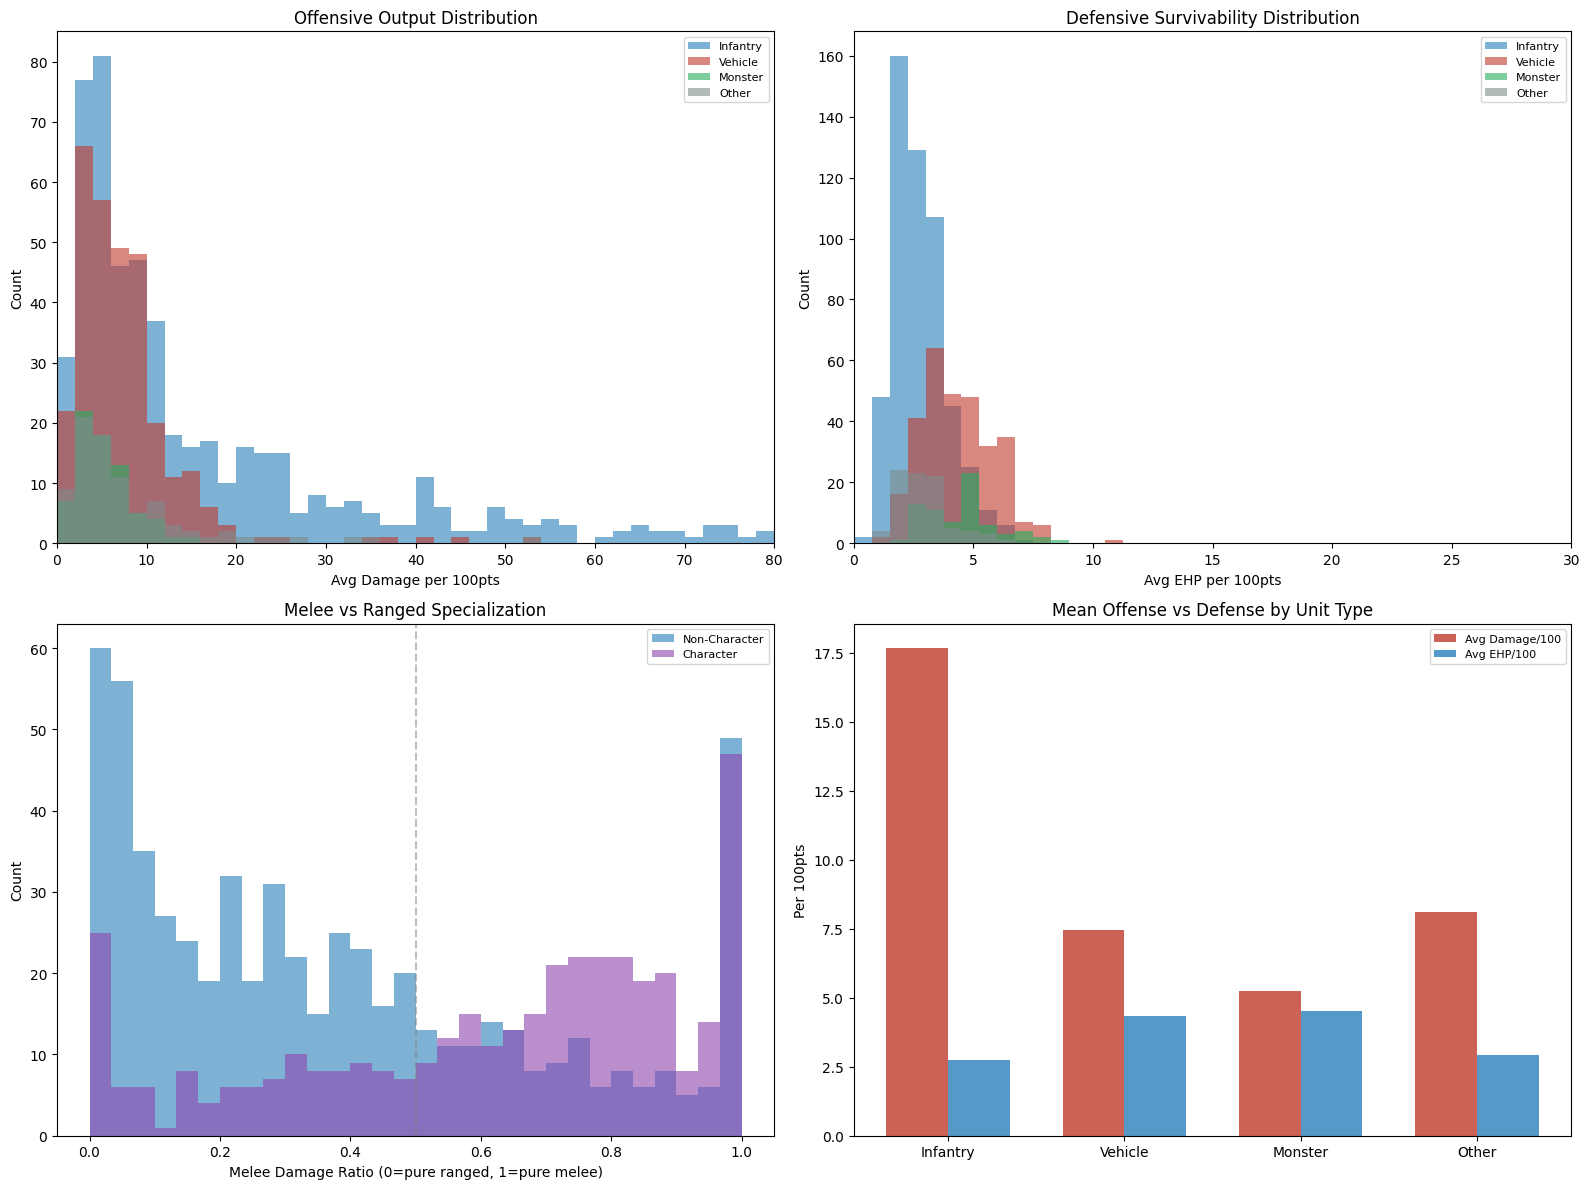

Saved feature_distributions.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

type_colors = {'Infantry': '#2980b9', 'Vehicle': '#c0392b', 'Monster': '#27ae60', 'Other': '#7f8c8d'}
def unit_type(row):
    if row['is_monster']: return 'Monster'
    if row['is_vehicle']: return 'Vehicle'
    if row['is_infantry']: return 'Infantry'
    return 'Other'
df['_unit_type'] = df.apply(unit_type, axis=1)

# (a) Damage distribution by unit type
ax = axes[0, 0]
for utype in ['Infantry', 'Vehicle', 'Monster', 'Other']:
    subset = df[df['_unit_type'] == utype]['avg_dmg_per_100']
    ax.hist(subset, bins=40, alpha=0.6, label=utype, color=type_colors[utype], range=(0, 80))
ax.set_xlabel('Avg Damage per 100pts')
ax.set_ylabel('Count')
ax.set_title('Offensive Output Distribution')
ax.legend(fontsize=8)
ax.set_xlim(0, 80)

# (b) EHP distribution by unit type
ax = axes[0, 1]
for utype in ['Infantry', 'Vehicle', 'Monster', 'Other']:
    subset = df[df['_unit_type'] == utype]['avg_ehp_per_100']
    ax.hist(subset, bins=40, alpha=0.6, label=utype, color=type_colors[utype], range=(0, 30))
ax.set_xlabel('Avg EHP per 100pts')
ax.set_ylabel('Count')
ax.set_title('Defensive Survivability Distribution')
ax.legend(fontsize=8)
ax.set_xlim(0, 30)

# (c) Melee damage ratio
ax = axes[1, 0]
chars = df[df['is_character'] == 1]['melee_damage_ratio']
non_chars = df[df['is_character'] == 0]['melee_damage_ratio']
ax.hist(non_chars, bins=30, alpha=0.6, label='Non-Character', color='#2980b9', range=(0, 1))
ax.hist(chars, bins=30, alpha=0.6, label='Character', color='#8e44ad', range=(0, 1))
ax.set_xlabel('Melee Damage Ratio (0=pure ranged, 1=pure melee)')
ax.set_ylabel('Count')
ax.set_title('Melee vs Ranged Specialization')
ax.legend(fontsize=8)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

# (d) Mean damage and EHP by unit type
ax = axes[1, 1]
type_means = df.groupby('_unit_type')[['avg_dmg_per_100', 'avg_ehp_per_100']].mean()
type_means = type_means.reindex(['Infantry', 'Vehicle', 'Monster', 'Other'])
x = np.arange(len(type_means))
w = 0.35
ax.bar(x - w/2, type_means['avg_dmg_per_100'], w, label='Avg Damage/100', color='#c0392b', alpha=0.8)
ax.bar(x + w/2, type_means['avg_ehp_per_100'], w, label='Avg EHP/100', color='#2980b9', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(type_means.index)
ax.set_ylabel('Per 100pts')
ax.set_title('Mean Offense vs Defense by Unit Type')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved feature_distributions.png")

### Offense vs Defense
Each unit plotted by its damage output and survivability per 100pts. Color indicates melee specialization.

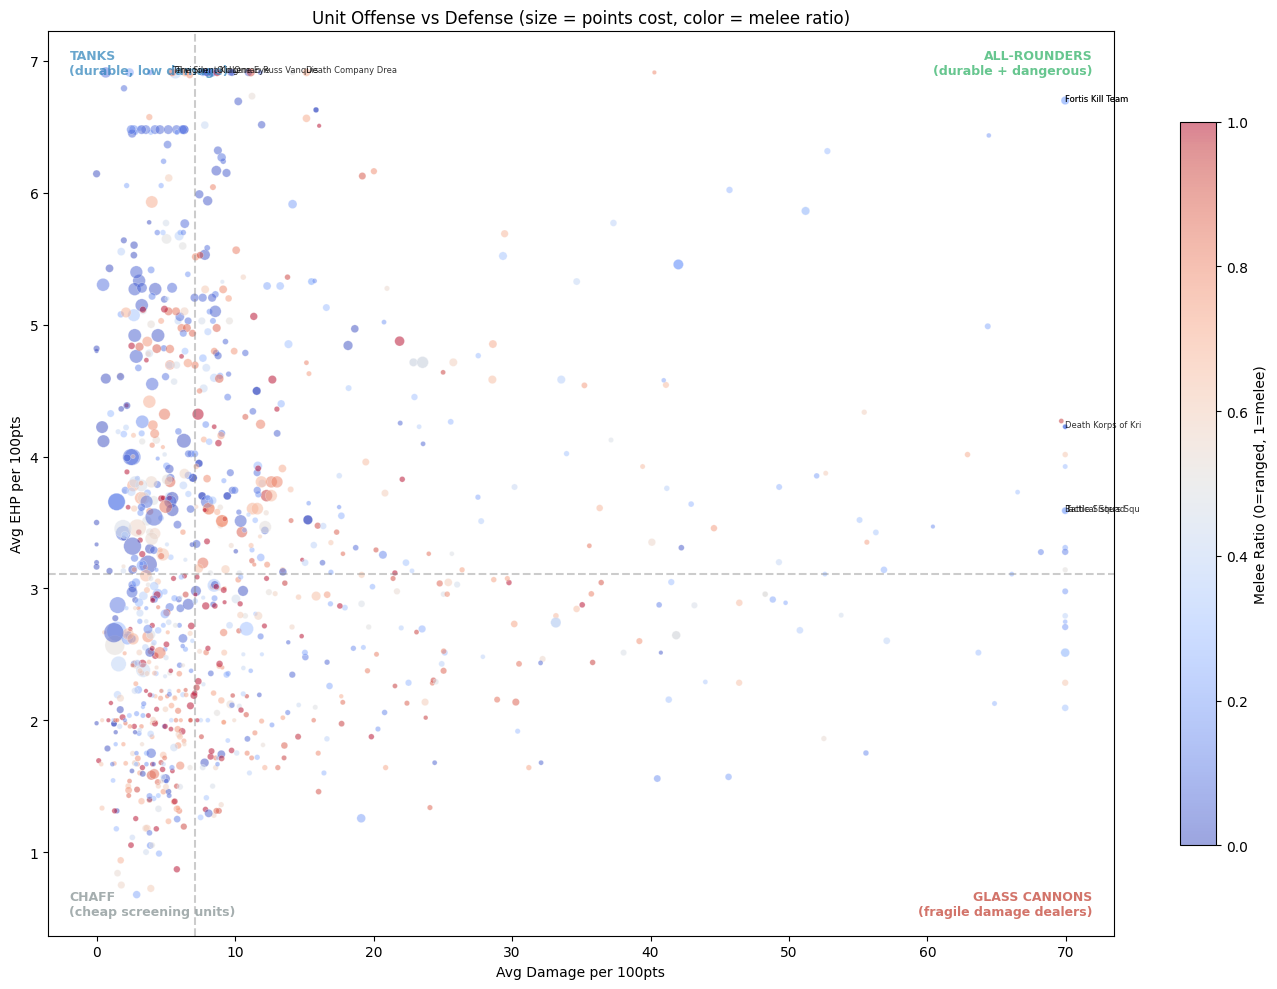

Saved offense_vs_defense.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

# Clip outliers for readability
dmg_clip = df['avg_dmg_per_100'].clip(upper=df['avg_dmg_per_100'].quantile(0.98))
ehp_clip = df['avg_ehp_per_100'].clip(upper=df['avg_ehp_per_100'].quantile(0.98))
med_dmg = dmg_clip.median()
med_ehp = ehp_clip.median()

sc = ax.scatter(dmg_clip, ehp_clip,
                c=df['melee_damage_ratio'], cmap='coolwarm', vmin=0, vmax=1,
                s=np.clip(df['cost'] / 5, 10, 200), alpha=0.5, edgecolors='white', linewidth=0.3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Melee Ratio (0=ranged, 1=melee)')

# Quadrant lines and labels
ax.axvline(med_dmg, color='gray', linestyle='--', alpha=0.4)
ax.axhline(med_ehp, color='gray', linestyle='--', alpha=0.4)
ax.text(0.02, 0.98, 'TANKS\n(durable, low damage)', transform=ax.transAxes,
        fontsize=9, va='top', ha='left', color='#2980b9', fontweight='bold', alpha=0.7)
ax.text(0.98, 0.98, 'ALL-ROUNDERS\n(durable + dangerous)', transform=ax.transAxes,
        fontsize=9, va='top', ha='right', color='#27ae60', fontweight='bold', alpha=0.7)
ax.text(0.02, 0.02, 'CHAFF\n(cheap screening units)', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='left', color='#7f8c8d', fontweight='bold', alpha=0.7)
ax.text(0.98, 0.02, 'GLASS CANNONS\n(fragile damage dealers)', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right', color='#c0392b', fontweight='bold', alpha=0.7)

# Annotate outliers
for _, row in df.nlargest(5, 'avg_dmg_per_100').iterrows():
    ax.annotate(row['unit_name'][:18], (min(row['avg_dmg_per_100'], dmg_clip.max()), row['avg_ehp_per_100']),
                fontsize=6, alpha=0.8)
for _, row in df.nlargest(5, 'avg_ehp_per_100').iterrows():
    ax.annotate(row['unit_name'][:18], (row['avg_dmg_per_100'], min(row['avg_ehp_per_100'], ehp_clip.max())),
                fontsize=6, alpha=0.8)

ax.set_xlabel('Avg Damage per 100pts')
ax.set_ylabel('Avg EHP per 100pts')
ax.set_title('Unit Offense vs Defense (size = points cost, color = melee ratio)')
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'offense_vs_defense.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved offense_vs_defense.png")

### Unit Role Taxonomy
Three views of unit roles: by battlefield type, by support capability, and all three dimensions combined.

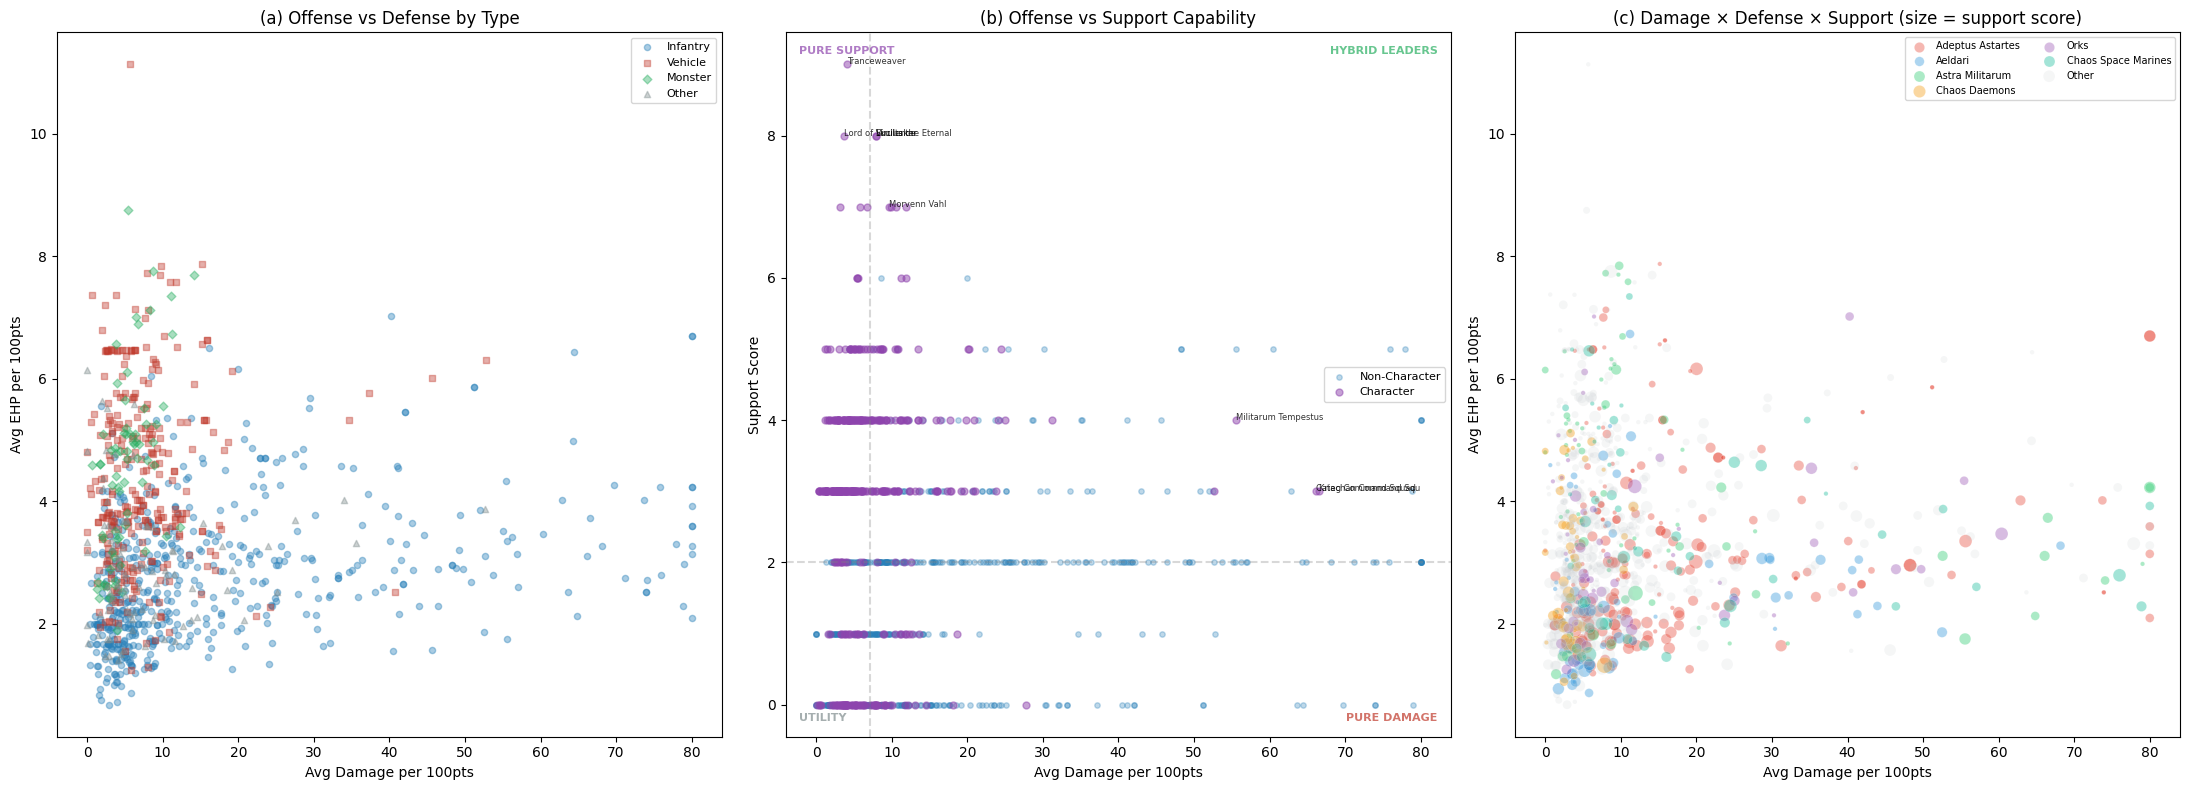

Saved unit_role_taxonomy.png


In [13]:
# Compute support score
support_cols_for_score = [
    ('has_leader', 3), ('has_reroll_hits_all', 2), ('has_reroll_hits_1s', 1),
    ('has_reroll_wounds_all', 2), ('has_reroll_wounds_1s', 1),
    ('has_plus_to_hit', 1), ('has_plus_to_wound', 1),
    ('has_grant_lethal_hits', 1), ('has_grant_sustained_hits', 1),
    ('has_grant_devastating_wounds', 1), ('has_damage_reduction', 1),
    ('has_minus_to_hit', 1), ('has_transhuman', 1), ('has_fight_first', 1),
]
df['support_score'] = sum(df.get(col, pd.Series(0, index=df.index)) * weight
                          for col, weight in support_cols_for_score
                          if col in df.columns)
df['support_score'] += (df['n_leader_options'] > 0).astype(int) * 2

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# (a) Offense vs Defense by keyword type
ax = axes[0]
type_markers = {'Infantry': 'o', 'Vehicle': 's', 'Monster': 'D', 'Other': '^'}
type_colors = {'Infantry': '#2980b9', 'Vehicle': '#c0392b', 'Monster': '#27ae60', 'Other': '#7f8c8d'}
for utype in ['Infantry', 'Vehicle', 'Monster', 'Other']:
    mask = df['_unit_type'] == utype
    ax.scatter(df.loc[mask, 'avg_dmg_per_100'].clip(upper=80),
               df.loc[mask, 'avg_ehp_per_100'].clip(upper=30),
               c=type_colors[utype], marker=type_markers[utype],
               s=20, alpha=0.4, label=utype)
ax.set_xlabel('Avg Damage per 100pts')
ax.set_ylabel('Avg EHP per 100pts')
ax.set_title('(a) Offense vs Defense by Type')
ax.legend(fontsize=8)

# (b) Offense vs Support Score
ax = axes[1]
med_dmg = df['avg_dmg_per_100'].median()
med_sup = df['support_score'].median()
chars = df['is_character'] == 1
ax.scatter(df.loc[~chars, 'avg_dmg_per_100'].clip(upper=80),
           df.loc[~chars, 'support_score'], c='#2980b9', s=15, alpha=0.3, label='Non-Character')
ax.scatter(df.loc[chars, 'avg_dmg_per_100'].clip(upper=80),
           df.loc[chars, 'support_score'], c='#8e44ad', s=25, alpha=0.5, label='Character')

ax.axvline(med_dmg, color='gray', linestyle='--', alpha=0.3)
ax.axhline(max(med_sup, 1), color='gray', linestyle='--', alpha=0.3)
ax.text(0.02, 0.98, 'PURE SUPPORT', transform=ax.transAxes,
        fontsize=8, va='top', ha='left', color='#8e44ad', fontweight='bold', alpha=0.7)
ax.text(0.98, 0.98, 'HYBRID LEADERS', transform=ax.transAxes,
        fontsize=8, va='top', ha='right', color='#27ae60', fontweight='bold', alpha=0.7)
ax.text(0.02, 0.02, 'UTILITY', transform=ax.transAxes,
        fontsize=8, va='bottom', ha='left', color='#7f8c8d', fontweight='bold', alpha=0.7)
ax.text(0.98, 0.02, 'PURE DAMAGE', transform=ax.transAxes,
        fontsize=8, va='bottom', ha='right', color='#c0392b', fontweight='bold', alpha=0.7)

# Annotate notable support characters
top_support = df[chars].nlargest(5, 'support_score')
for _, row in top_support.iterrows():
    ax.annotate(row['unit_name'][:20],
                (min(row['avg_dmg_per_100'], 80), row['support_score']),
                fontsize=6, alpha=0.8)
top_dmg_chars = df[chars].nlargest(3, 'avg_dmg_per_100')
for _, row in top_dmg_chars.iterrows():
    ax.annotate(row['unit_name'][:20],
                (min(row['avg_dmg_per_100'], 80), row['support_score']),
                fontsize=6, alpha=0.8)

ax.set_xlabel('Avg Damage per 100pts')
ax.set_ylabel('Support Score')
ax.set_title('(b) Offense vs Support Capability')
ax.legend(fontsize=8)

# (c) 3-axis bubble: damage, EHP, support size, color by top factions
ax = axes[2]
top_factions = df['faction'].value_counts().head(6).index.tolist()
fac_colors = dict(zip(top_factions, ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']))

for fac in top_factions:
    mask = df['faction'] == fac
    ax.scatter(df.loc[mask, 'avg_dmg_per_100'].clip(upper=80),
               df.loc[mask, 'avg_ehp_per_100'].clip(upper=30),
               s=df.loc[mask, 'support_score'] * 15 + 10,
               c=fac_colors[fac], alpha=0.4, label=fac.replace('-', ' ').title(), edgecolors='white', linewidth=0.3)
other_mask = ~df['faction'].isin(top_factions)
ax.scatter(df.loc[other_mask, 'avg_dmg_per_100'].clip(upper=80),
           df.loc[other_mask, 'avg_ehp_per_100'].clip(upper=30),
           s=df.loc[other_mask, 'support_score'] * 15 + 10,
           c='#bdc3c7', alpha=0.15, label='Other', edgecolors='none')
ax.set_xlabel('Avg Damage per 100pts')
ax.set_ylabel('Avg EHP per 100pts')
ax.set_title('(c) Damage × Defense × Support (size = support score)')
ax.legend(fontsize=7, ncol=2, loc='upper right')

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'unit_role_taxonomy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved unit_role_taxonomy.png")

## Regression Models

Six progressive models to isolate the pricing contribution of abilities.
OLS with HC3 robust standard errors, plus Lasso for feature selection.
Models E and F add defensive EHP, melee/ranged split, and interaction features.

In [14]:
# Define feature groups
stat_cols = ['M', 'T', 'W', 'save_quality', 'invuln_quality', 'Ld', 'OC']

# NEW: multi-target damage features replace old single-reference weapon aggregates
damage_cols = ['dmg_per_100_horde', 'dmg_per_100_elite', 'dmg_per_100_vehicle',
               'dmg_per_100_nightmare', 'avg_dmg_per_100', 'rng_max_range']

keyword_cols = ['is_infantry', 'is_vehicle', 'is_monster', 'is_character',
                'is_battleline', 'is_titanic', 'is_fly', 'is_epic_hero',
                'is_dedicated_transport']

weapon_kw_cols = ['has_torrent', 'has_blast', 'has_lethal_hits', 'has_sustained_hits',
                  'has_devastating_wounds', 'has_twin_linked', 'has_melta', 'has_lance',
                  'has_heavy', 'has_indirect_fire', 'has_precision',
                  'has_anti_infantry', 'has_anti_vehicle', 'has_anti_monster']

core_ability_cols = ['has_deep_strike', 'has_stealth', 'has_infiltrators',
                     'has_lone_operative', 'has_leader', 'has_hover',
                     'has_scouts', 'scout_distance', 'has_deadly_demise', 'dd_value',
                     'has_fnp', 'fnp_value', 'has_firing_deck', 'fd_capacity']

ability_count_cols = ['n_core_abilities', 'n_other_abilities', 'n_wargear_abilities',
                      'n_total_abilities', 'n_phases_covered']

possible_buff_cols = ['has_reroll_hits_all', 'has_reroll_hits_1s',
                      'has_reroll_wounds_all', 'has_reroll_wounds_1s',
                      'has_reroll_damage', 'has_plus_to_hit', 'has_plus_to_wound',
                      'has_extra_attacks', 'has_extra_ap', 'has_extra_strength',
                      'has_grant_lethal_hits', 'has_grant_sustained_hits',
                      'has_grant_devastating_wounds', 'has_has_mortal_output',
                      'has_fight_first', 'has_damage_reduction',
                      'has_minus_to_hit', 'has_minus_to_wound',
                      'has_transhuman', 'has_ignores_cover']
buff_cols_present = [c for c in possible_buff_cols if c in df.columns]

movement_cols = ['has_surge_move', 'has_extended_pile_in', 'has_move_after_shoot',
                 'has_reactive_move', 'has_opponent_move_debuff', 'has_leader_movement_buff']
structural_cols = ['min_model_count', 'max_model_count', 'n_leader_options', 'n_wargear_options'] + movement_cols

# New feature groups
ehp_cols = ['ehp_vs_bolter', 'ehp_vs_powerfist', 'ehp_vs_lascannon',
            'ehp_vs_melta', 'avg_ehp_per_100']

phase_split_cols = ['avg_dmg_ranged_per_100', 'avg_dmg_melee_per_100', 'melee_damage_ratio']

transport_weapon_cols = ['transport_capacity', 'n_ranged_weapons', 'n_melee_weapons',
                         'n_total_weapons', 'has_both_phases']

# Interaction terms
df['TxW'] = df['T'] * df['W']
df['fnp_quality_x_W'] = (7 - df['fnp_value']) * df['W']
df['character_leader'] = df['is_character'] * df['has_leader']
df['deepstrike_melee'] = df['has_deep_strike'] * df['melee_damage_ratio']
df['fnp_x_save'] = df['has_fnp'] * df['save_quality']

interaction_cols = ['TxW', 'fnp_quality_x_W', 'character_leader',
                    'deepstrike_melee', 'fnp_x_save']

all_new_cols = ehp_cols + phase_split_cols + transport_weapon_cols + interaction_cols

for col_list in [stat_cols, damage_cols, keyword_cols, weapon_kw_cols, 
                 core_ability_cols, ability_count_cols, buff_cols_present, structural_cols,
                 ehp_cols, phase_split_cols, transport_weapon_cols, interaction_cols]:
    for c in col_list:
        if c not in df.columns: df[c] = 0
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

y = df['log_ppm']
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    df.index, y, df.index, test_size=0.2, random_state=42
)

def run_ols(feature_cols, label, X_idx=idx_train, y_vals=None):
    if y_vals is None: y_vals = y.loc[X_idx]
    X = sm.add_constant(df.loc[X_idx, feature_cols].astype(float))
    model = sm.OLS(y_vals, X).fit(cov_type='HC3')
    X_te = sm.add_constant(df.loc[idx_test, feature_cols].astype(float))
    y_pred = model.predict(X_te)
    ss_res = ((y.loc[idx_test] - y_pred) ** 2).sum()
    ss_tot = ((y.loc[idx_test] - y.loc[idx_test].mean()) ** 2).sum()
    test_r2 = 1 - ss_res / ss_tot
    return model, test_r2

# Model A: Stats + Multi-target damage
feats_A = stat_cols + damage_cols
model_A, r2_A = run_ols(feats_A, 'Model A')

# Model B: + Keywords + Core Abilities
feats_B = feats_A + keyword_cols + weapon_kw_cols + core_ability_cols + ability_count_cols
model_B, r2_B = run_ols(feats_B, 'Model B')

# Model C: + Buff Features + Structural
feats_C = feats_B + buff_cols_present + structural_cols
model_C, r2_C = run_ols(feats_C, 'Model C')

# Model D: + Faction dummies
faction_dummies = pd.get_dummies(df['faction'], prefix='fac', drop_first=True)
feats_D = feats_C + list(faction_dummies.columns)
for c in faction_dummies.columns:
    if c not in df.columns: df[c] = faction_dummies[c]
model_D, r2_D = run_ols(feats_D, 'Model D')

# Model E: C + EHP + Phase Split + Transport/Weapons + Interactions (all new features)
feats_E_full = feats_C + all_new_cols
model_E_full, r2_E_full = run_ols(feats_E_full, 'Model E (full)')

# Model E: Trimmed — only significant new features (p < 0.1 from full model)
sig_new = [f for f in all_new_cols
           if f in model_E_full.params.index and model_E_full.pvalues[f] < 0.1]
feats_E = feats_C + sig_new
model_E, r2_E = run_ols(feats_E, 'Model E')

# Model F: E + Faction dummies
feats_F = feats_E + list(faction_dummies.columns)
model_F, r2_F = run_ols(feats_F, 'Model F')

print("=" * 75)
print(f"{'Model':<18} {'Train R2':>10} {'Test R2':>10} {'Features':>10} {'Delta':>8}")
print("-" * 75)
prev_r2 = 0
for name, model, r2 in [('A: Stats+Dmg', model_A, r2_A), ('B: +Ability', model_B, r2_B),
                         ('C: +Buffs', model_C, r2_C), ('D: C+Faction', model_D, r2_D),
                         ('E full: +All', model_E_full, r2_E_full),
                         ('E trim: +Sig', model_E, r2_E),
                         ('F: E+Faction', model_F, r2_F)]:
    delta = r2 - prev_r2 if prev_r2 > 0 else 0
    gap = model.rsquared - r2
    print(f"{name:<18} {model.rsquared:>10.4f} {r2:>10.4f} {model.df_model:>10.0f} {'+' if delta >= 0 else ''}{delta:>7.4f}")
    prev_r2 = r2
print("=" * 75)

# Show which features survived trimming
print(f"\nSignificant new features ({len(sig_new)} of {len(all_new_cols)} kept):")
for feat in sig_new:
    coef = model_E.params[feat]
    pval = model_E.pvalues[feat]
    pct = (np.exp(coef) - 1) * 100
    sig = "***" if pval < 0.001 else "** " if pval < 0.01 else "*  " if pval < 0.05 else "~  "
    print(f"  {sig} {feat:<30s} {pct:>+8.1f}%  (p={pval:.3f})")

dropped = [f for f in all_new_cols if f not in sig_new]
if dropped:
    print(f"\nDropped (p >= 0.1): {', '.join(dropped)}")

Model                Train R2    Test R2   Features    Delta
---------------------------------------------------------------------------
A: Stats+Dmg           0.8644     0.9028         12 + 0.0000
B: +Ability            0.9354     0.9458         54 + 0.0430
C: +Buffs              0.9628     0.9649         80 + 0.0191
D: C+Faction           0.9660     0.9638        102 -0.0011
E full: +All           0.9780     0.9738         96 + 0.0100
E trim: +Sig           0.9770     0.9733         89 -0.0005
F: E+Faction           0.9793     0.9710        111 -0.0023

Significant new features (10 of 18 kept):
  *** ehp_vs_bolter                      +1.6%  (p=0.000)
  *** ehp_vs_powerfist                   -8.6%  (p=0.000)
  *** ehp_vs_lascannon                   -8.0%  (p=0.000)
  *   ehp_vs_melta                       -5.8%  (p=0.035)
  *** avg_ehp_per_100                    -5.3%  (p=0.000)
  **  avg_dmg_ranged_per_100             -0.6%  (p=0.008)
  *   avg_dmg_melee_per_100              -0.6%  

/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/1172296467.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  if c not in df.columns: df[c] = faction_dummies[c]


### Model Progression
Train and test R² across all model variants, showing the incremental contribution of each feature group.

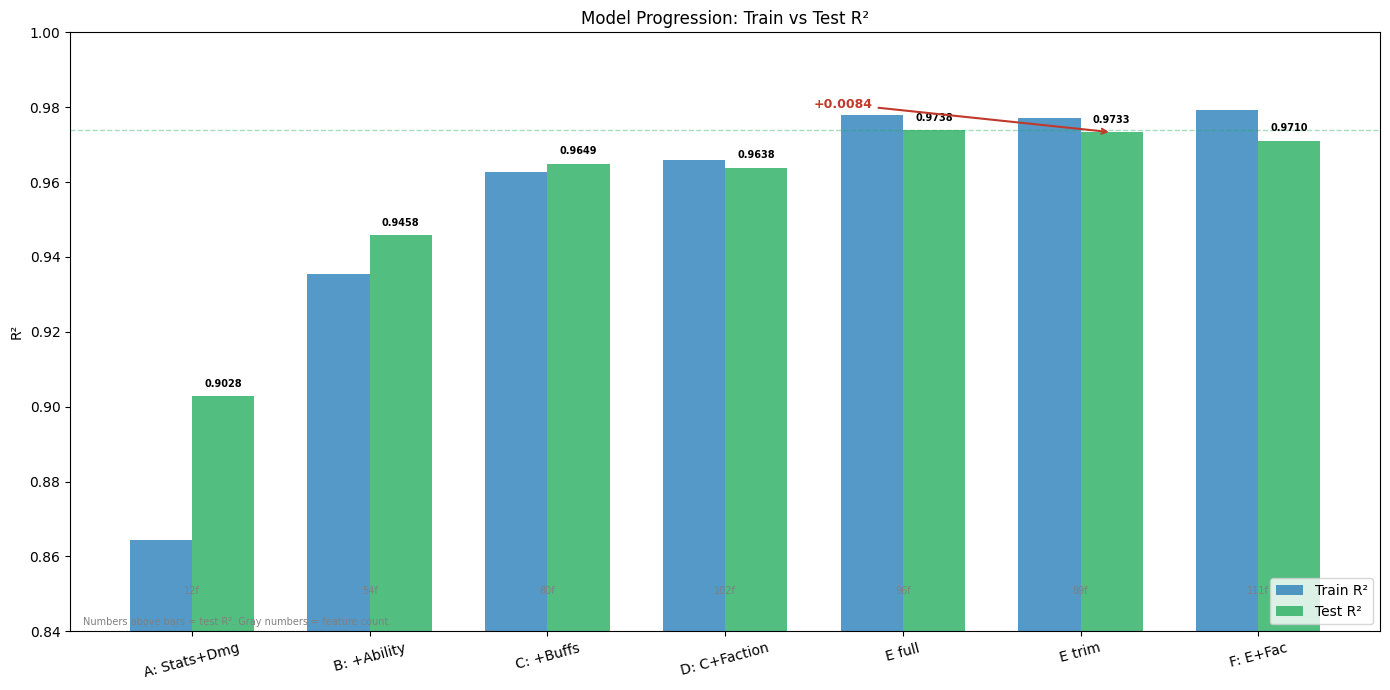

Saved model_progression.png


In [15]:
model_names = ['A: Stats+Dmg', 'B: +Ability', 'C: +Buffs', 'D: C+Faction',
               'E full', 'E trim', 'F: E+Fac']
models_list = [model_A, model_B, model_C, model_D, model_E_full, model_E, model_F]
r2_list = [r2_A, r2_B, r2_C, r2_D, r2_E_full, r2_E, r2_F]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(model_names))
w = 0.35

train_r2s = [m.rsquared for m in models_list]
test_r2s = list(r2_list)
feat_counts = [int(m.df_model) for m in models_list]

bars1 = ax.bar(x - w/2, train_r2s, w, label='Train R²', color='#2980b9', alpha=0.8)
bars2 = ax.bar(x + w/2, test_r2s, w, label='Test R²', color='#27ae60', alpha=0.8)

# Annotate test R² values
for i, (bar, r2) in enumerate(zip(bars2, test_r2s)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{r2:.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# Feature count annotations
for i, (xi, fc) in enumerate(zip(x, feat_counts)):
    ax.text(xi, 0.85, f'{fc}f', ha='center', fontsize=7, color='gray')

# Best model line
best_idx = test_r2s.index(max(test_r2s))
ax.axhline(max(test_r2s), color='#27ae60', linestyle='--', alpha=0.4, linewidth=1)

# Arrow showing C → E improvement
c_idx = model_names.index('C: +Buffs')
e_idx = model_names.index('E trim')
delta = test_r2s[e_idx] - test_r2s[c_idx]
ax.annotate(f'+{delta:.4f}', xy=(e_idx + w/2, test_r2s[e_idx]),
            xytext=(c_idx + 1.5, test_r2s[c_idx] + 0.015),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
            fontsize=9, color='#c0392b', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel('R²')
ax.set_title('Model Progression: Train vs Test R²')
ax.legend(loc='lower right')
ax.set_ylim(0.84, 1.0)
ax.text(0.01, 0.01, 'Numbers above bars = test R². Gray numbers = feature count.',
        transform=ax.transAxes, fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'model_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_progression.png")

### New Feature Importance
Coefficients of the significant new features added in Model E, expressed as % cost impact.

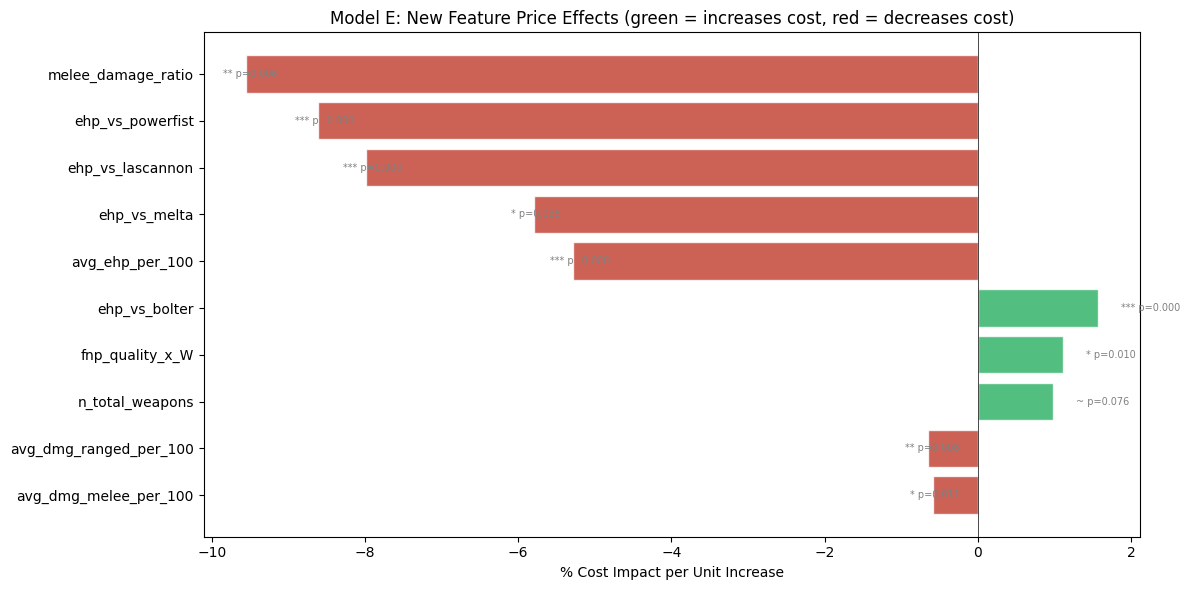

Saved new_feature_importance.png


In [16]:
new_feats_in_model = [f for f in sig_new if f in model_E.params.index]
coefs = [(f, model_E.params[f], model_E.pvalues[f]) for f in new_feats_in_model]
coefs.sort(key=lambda x: abs(x[1]))

fig, ax = plt.subplots(figsize=(12, 6))
names = [c[0] for c in coefs]
pct_impacts = [(np.exp(c[1]) - 1) * 100 for c in coefs]
pvals = [c[2] for c in coefs]
colors = ['#27ae60' if p > 0 else '#c0392b' for p in pct_impacts]

bars = ax.barh(names, pct_impacts, color=colors, alpha=0.8, edgecolor='white')

# p-value annotations
for i, (bar, pv) in enumerate(zip(bars, pvals)):
    sig = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else '~'
    xpos = bar.get_width() + (0.3 if bar.get_width() >= 0 else -0.3)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{sig} p={pv:.3f}', va='center', fontsize=7, color='gray')

ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('% Cost Impact per Unit Increase')
ax.set_title('Model E: New Feature Price Effects (green = increases cost, red = decreases cost)')
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'new_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved new_feature_importance.png")

### EHP Deep Dive
How units perform against different weapon types, and how defensive abilities amplify raw stats.

/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/150932317.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_raw_hp_per_100'] = df['n_models'] * df['W'] / df['cost'] * 100
/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/150932317.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_ehp_boost'] = df['avg_ehp_per_100'] / (df['_raw_hp_per_100'] + 0.01)


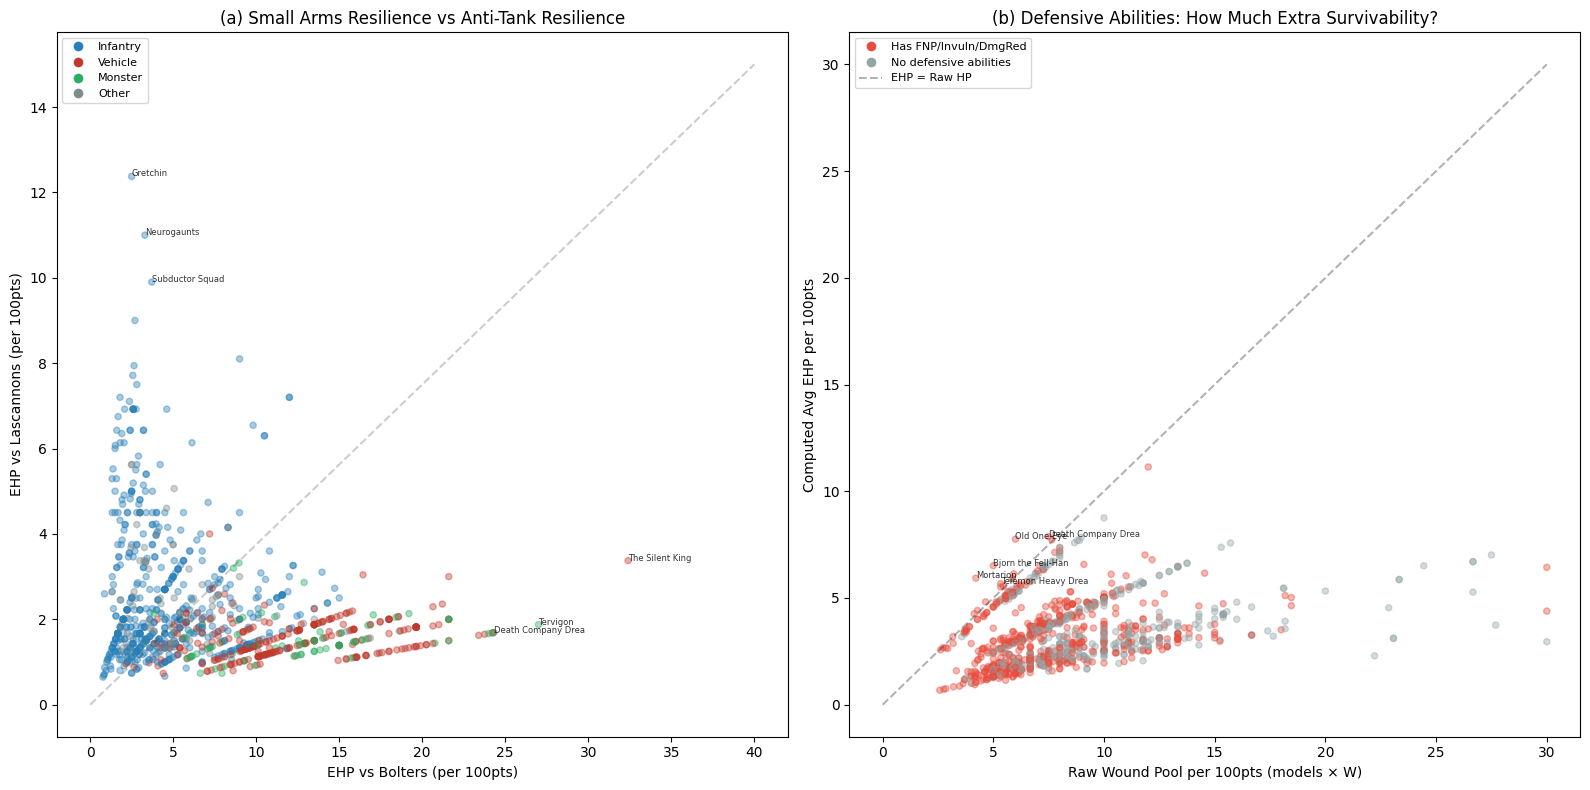

Saved ehp_deep_dive.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# (a) EHP vs bolter vs lascannon — how units handle mass fire vs anti-tank
ax = axes[0]
colors = df['_unit_type'].map({'Infantry': '#2980b9', 'Vehicle': '#c0392b',
                                'Monster': '#27ae60', 'Other': '#7f8c8d'})
ax.scatter(df['ehp_vs_bolter'].clip(upper=40), df['ehp_vs_lascannon'].clip(upper=15),
           c=colors, s=20, alpha=0.4)
ax.plot([0, 40], [0, 15], 'k--', alpha=0.2)  # diagonal reference

# Annotate extreme cases
for _, row in df.nlargest(3, 'ehp_vs_bolter').iterrows():
    ax.annotate(row['unit_name'][:18],
                (min(row['ehp_vs_bolter'], 40), min(row['ehp_vs_lascannon'], 15)),
                fontsize=6, alpha=0.8)
for _, row in df.nlargest(3, 'ehp_vs_lascannon').iterrows():
    ax.annotate(row['unit_name'][:18],
                (min(row['ehp_vs_bolter'], 40), min(row['ehp_vs_lascannon'], 15)),
                fontsize=6, alpha=0.8)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=t)
                   for t, c in [('Infantry', '#2980b9'), ('Vehicle', '#c0392b'),
                                ('Monster', '#27ae60'), ('Other', '#7f8c8d')]]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_xlabel('EHP vs Bolters (per 100pts)')
ax.set_ylabel('EHP vs Lascannons (per 100pts)')
ax.set_title('(a) Small Arms Resilience vs Anti-Tank Resilience')

# (b) Raw HP pool vs computed EHP — shows defensive ability value
ax = axes[1]
df['_raw_hp_per_100'] = df['n_models'] * df['W'] / df['cost'] * 100
has_def_ability = ((df['has_fnp'] == 1) | (df['has_damage_reduction'] == 1) |
                   (df['invuln_quality'] > 0)).astype(int)
colors_def = has_def_ability.map({1: '#e74c3c', 0: '#95a5a6'})

ax.scatter(df['_raw_hp_per_100'].clip(upper=50), df['avg_ehp_per_100'].clip(upper=30),
           c=colors_def, s=20, alpha=0.4)

# 1:1 reference line (where EHP = raw HP, meaning no defensive abilities help)
max_val = 30
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='EHP = Raw HP')

# Annotate units with biggest EHP boost over raw stats
df['_ehp_boost'] = df['avg_ehp_per_100'] / (df['_raw_hp_per_100'] + 0.01)
for _, row in df.nlargest(5, '_ehp_boost').iterrows():
    ax.annotate(row['unit_name'][:18],
                (min(row['_raw_hp_per_100'], 50), min(row['avg_ehp_per_100'], 30)),
                fontsize=6, alpha=0.8)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8,
           label='Has FNP/Invuln/DmgRed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=8,
           label='No defensive abilities'),
    Line2D([0], [0], color='black', linestyle='--', alpha=0.3, label='EHP = Raw HP'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper left')
ax.set_xlabel('Raw Wound Pool per 100pts (models × W)')
ax.set_ylabel('Computed Avg EHP per 100pts')
ax.set_title('(b) Defensive Abilities: How Much Extra Survivability?')

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'ehp_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ehp_deep_dive.png")

Ability/Keyword Feature Pricing (Model E, % cost impact per unit increase):
  *** has_damage_reduction                   +48.9%  (p=0.000)
      has_scouts                             +33.1%  (p=0.099)
  *** has_lone_operative                     +29.1%  (p=0.000)
  **  has_surge_move                         +20.6%  (p=0.002)
  *** has_leader                             +17.6%  (p=0.000)
  *   has_hover                              +16.6%  (p=0.034)
  *   has_fight_first                         +9.1%  (p=0.038)
      has_deadly_demise                       +6.8%  (p=0.169)
  *   has_extended_pile_in                    +6.5%  (p=0.038)
  *   has_grant_sustained_hits                +5.0%  (p=0.027)
      has_minus_to_wound                      +4.3%  (p=0.284)
  *   has_extra_attacks                       +3.6%  (p=0.017)
      has_reroll_hits_all                     +3.4%  (p=0.248)
      has_sustained_hits                      +2.9%  (p=0.099)
      has_indirect_fire                   

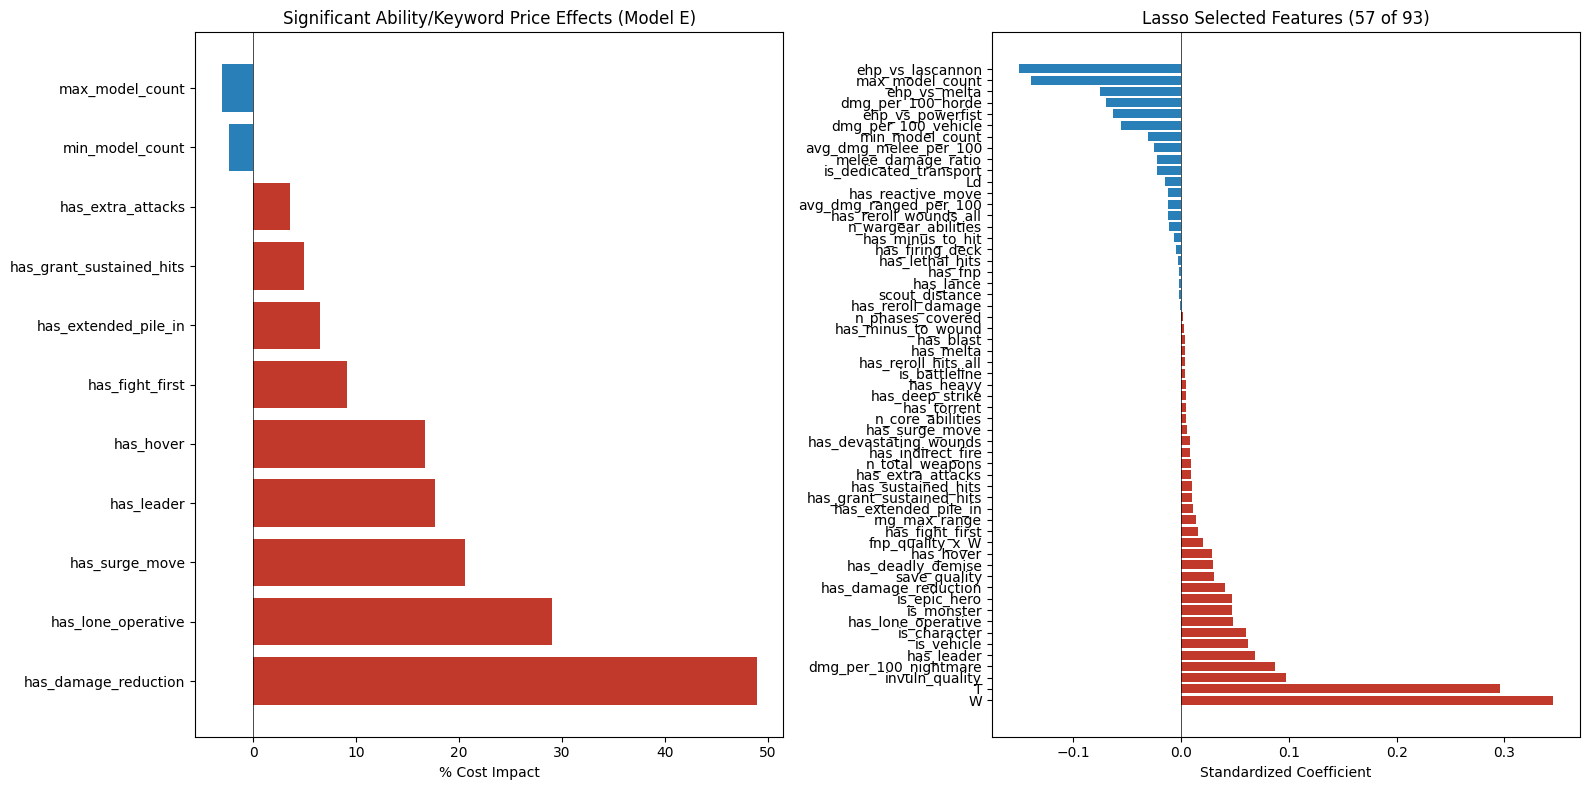

Saved ability_pricing.png


In [18]:
# --- Ability Pricing Analysis ---
# Show Model E coefficients (before faction effects) for ability features
# Express as % cost impact: (exp(coef) - 1) * 100

ability_related = (core_ability_cols + ability_count_cols + buff_cols_present + 
                   weapon_kw_cols + structural_cols)
ability_feats = [f for f in ability_related if f in model_E.params.index]

coef_df = pd.DataFrame({
    'feature': ability_feats,
    'coefficient': [model_E.params[f] for f in ability_feats],
    'pct_impact': [(np.exp(model_E.params[f]) - 1) * 100 for f in ability_feats],
    'p_value': [model_E.pvalues[f] for f in ability_feats],
    'significant': [model_E.pvalues[f] < 0.05 for f in ability_feats],
}).sort_values('pct_impact', ascending=False)

print("Ability/Keyword Feature Pricing (Model E, % cost impact per unit increase):")
print("=" * 80)
for _, row in coef_df.iterrows():
    sig = "***" if row['p_value'] < 0.001 else "** " if row['p_value'] < 0.01 else "*  " if row['p_value'] < 0.05 else "   "
    print(f"  {sig} {row['feature']:<35s} {row['pct_impact']:>+8.1f}%  (p={row['p_value']:.3f})")

# --- Lasso Feature Selection ---
all_feats = feats_E
X_lasso = StandardScaler().fit_transform(df.loc[idx_train, all_feats].astype(float))
y_lasso = y.loc[idx_train]

lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_lasso, y_lasso)
lasso_coefs = pd.Series(lasso.coef_, index=all_feats)
selected = lasso_coefs[lasso_coefs.abs() > 0.001].sort_values(ascending=False)

print(f"\nLasso selected {len(selected)} features (alpha={lasso.alpha_:.4f}):")
print("-" * 60)
for feat, coef in selected.items():
    direction = "↑ cost" if coef > 0 else "↓ cost"
    print(f"  {feat:<35s} {coef:>+8.4f}  ({direction})")

# --- Visualization: Top ability coefficients ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Model C ability coefficients
sig_df = coef_df[coef_df['significant']].nlargest(20, 'pct_impact', keep='all')
if len(sig_df) < 20:
    sig_df = pd.concat([sig_df, coef_df[coef_df['significant']].nsmallest(20 - len(sig_df), 'pct_impact', keep='all')])
colors = ['#c0392b' if v > 0 else '#2980b9' for v in sig_df['pct_impact']]
axes[0].barh(sig_df['feature'], sig_df['pct_impact'], color=colors)
axes[0].set_xlabel('% Cost Impact')
axes[0].set_title('Significant Ability/Keyword Price Effects (Model E)')
axes[0].axvline(0, color='black', linewidth=0.5)

# Plot 2: Lasso selected features
if len(selected) > 0:
    colors2 = ['#c0392b' if v > 0 else '#2980b9' for v in selected]
    axes[1].barh(selected.index, selected.values, color=colors2)
    axes[1].set_xlabel('Standardized Coefficient')
    axes[1].set_title(f'Lasso Selected Features ({len(selected)} of {len(all_feats)})')
    axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'ability_pricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ability_pricing.png")

## Over/Undercosted Units by Faction

Using Model C (stats + abilities + buffs, no faction dummies) to predict what each unit
"should" cost based on its statline and abilities. The residual reveals what GW is
charging above or below the model's prediction — the faction-agnostic fair price.

Faction                   |                  Most OVERCOSTED                   |                  Most UNDERCOSTED                 
                          |          (paying more than stats suggest)          |             (bargain for what you get)            
adepta-sororitas          | Triumph of Saint Kathe (+53%, 235 vs 154ppm)       | Aestred Thurga and Aga (-35%, 35 vs 54ppm)        
adeptus-astartes          | Emperor’s Champion     (+52%, 100 vs 66ppm)        | Wulfen                 (-27%, 17 vs 23ppm)        
adeptus-custodes          | Orion Assault Dropship (+31%, 690 vs 528ppm)       | Witchseekers           (-22%, 11 vs 14ppm)        
adeptus-mechanicus        | Skitarii Rangers       (+18%, 8 vs 7ppm)           | Sydonian Dragoons with (-29%, 55 vs 78ppm)        
aeldari                   | D-cannon Platform      (+75%, 125 vs 71ppm)        | Phantom Titan          (-33%, 2100 vs 3146ppm)    
agents-of-the-imperium    | Subductor Squad        (+75%, 9 vs 5ppm)        

/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/3753381634.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['predicted_log_ppm'] = model_E.predict(X_all)
/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/3753381634.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['predicted_ppm'] = np.exp(df['predicted_log_ppm'])
/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/3753381634.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

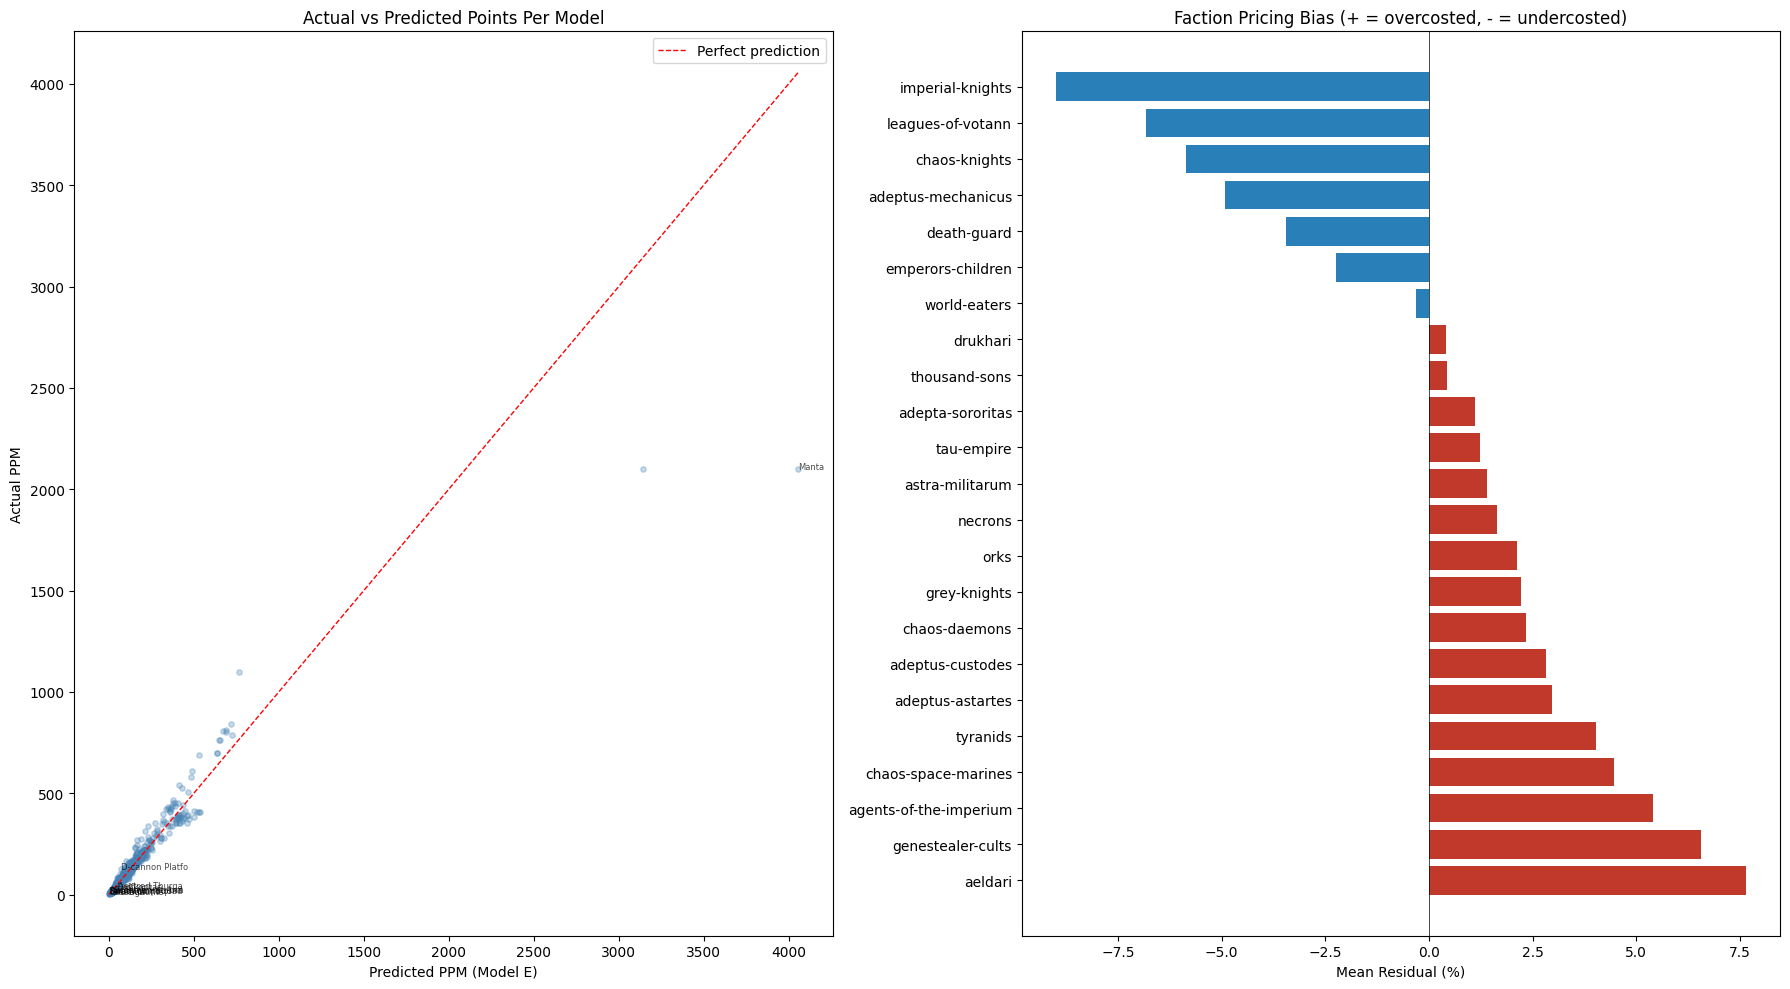

Saved over_undercosted.png


In [19]:
# Compute residuals from Model E (best model, no faction dummies)
# Predict for ALL units, not just train set
X_all = sm.add_constant(df[feats_E].astype(float))
df['predicted_log_ppm'] = model_E.predict(X_all)
df['predicted_ppm'] = np.exp(df['predicted_log_ppm'])
df['residual_pct'] = (df['ppm'] / df['predicted_ppm'] - 1) * 100  # +% = overcosted, -% = undercosted
df['residual_pts'] = df['ppm'] - df['predicted_ppm']  # absolute difference per model

# --- Most over/undercosted per faction ---
# Group by faction, show top 3 overcosted and top 3 undercosted
factions_sorted = sorted(df['faction'].unique())

print(f"{'Faction':<25s} | {'Most OVERCOSTED':^50s} | {'Most UNDERCOSTED':^50s}")
print(f"{'':<25s} | {'(paying more than stats suggest)':^50s} | {'(bargain for what you get)':^50s}")
print("=" * 130)

faction_summaries = []

for faction in factions_sorted:
    fdf = df[df['faction'] == faction].copy()
    if len(fdf) < 3:
        continue
    
    over = fdf.nlargest(1, 'residual_pct').iloc[0]
    under = fdf.nsmallest(1, 'residual_pct').iloc[0]
    
    over_str = f"{over['unit_name'][:22]:<22s} ({over['residual_pct']:+.0f}%, {over['ppm']:.0f} vs {over['predicted_ppm']:.0f}ppm)"
    under_str = f"{under['unit_name'][:22]:<22s} ({under['residual_pct']:+.0f}%, {under['ppm']:.0f} vs {under['predicted_ppm']:.0f}ppm)"
    
    print(f"{faction:<25s} | {over_str:<50s} | {under_str:<50s}")
    
    faction_summaries.append({
        'faction': faction,
        'n_units': len(fdf),
        'mean_residual_pct': fdf['residual_pct'].mean(),
        'overcosted_unit': over['unit_name'],
        'overcosted_pct': over['residual_pct'],
        'undercosted_unit': under['unit_name'],
        'undercosted_pct': under['residual_pct'],
    })

# --- Global top 15 over and undercosted ---
print("\n" + "=" * 100)
print("GLOBAL TOP 15 OVERCOSTED (paying the most above predicted value):")
print("-" * 100)
for _, row in df.nlargest(15, 'residual_pct').iterrows():
    print(f"  {row['unit_name']:<35s} {row['faction']:<22s} "
          f"actual={row['ppm']:>6.0f}ppm  predicted={row['predicted_ppm']:>6.0f}ppm  "
          f"delta={row['residual_pct']:>+6.1f}%")

print("\n" + "=" * 100)
print("GLOBAL TOP 15 UNDERCOSTED (biggest bargains relative to predicted value):")
print("-" * 100)
for _, row in df.nsmallest(15, 'residual_pct').iterrows():
    print(f"  {row['unit_name']:<35s} {row['faction']:<22s} "
          f"actual={row['ppm']:>6.0f}ppm  predicted={row['predicted_ppm']:>6.0f}ppm  "
          f"delta={row['residual_pct']:>+6.1f}%")

# --- Faction-level bias (is a whole faction over/undercosted?) ---
print("\n" + "=" * 100)
print("FACTION-LEVEL PRICING BIAS (mean residual across all units):")
print("-" * 100)
faction_bias = pd.DataFrame(faction_summaries).sort_values('mean_residual_pct', ascending=False)
for _, row in faction_bias.iterrows():
    bar = "+" * max(0, int(row['mean_residual_pct'] / 2)) + "-" * max(0, int(-row['mean_residual_pct'] / 2))
    print(f"  {row['faction']:<25s} {row['mean_residual_pct']:>+6.1f}%  ({row['n_units']:>3d} units)  {bar}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plot 1: Actual vs Predicted PPM scatter
ax = axes[0]
ax.scatter(df['predicted_ppm'], df['ppm'], alpha=0.3, s=15, c='steelblue')
max_val = max(df['ppm'].max(), df['predicted_ppm'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Predicted PPM (Model E)')
ax.set_ylabel('Actual PPM')
ax.set_title('Actual vs Predicted Points Per Model')
ax.legend()
# Annotate biggest outliers
for _, row in df.nlargest(5, 'residual_pct').iterrows():
    ax.annotate(row['unit_name'][:15], (row['predicted_ppm'], row['ppm']),
                fontsize=6, alpha=0.7)
for _, row in df.nsmallest(5, 'residual_pct').iterrows():
    ax.annotate(row['unit_name'][:15], (row['predicted_ppm'], row['ppm']),
                fontsize=6, alpha=0.7)

# Plot 2: Faction bias bar chart
ax2 = axes[1]
colors = ['#c0392b' if v > 0 else '#2980b9' for v in faction_bias['mean_residual_pct']]
ax2.barh(faction_bias['faction'], faction_bias['mean_residual_pct'], color=colors)
ax2.set_xlabel('Mean Residual (%)')
ax2.set_title('Faction Pricing Bias (+ = overcosted, - = undercosted)')
ax2.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'over_undercosted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved over_undercosted.png")


### Melee vs Ranged Pricing Bias
Does Model E price melee and ranged specialists fairly? Checking for systematic residual patterns.

/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_14385/3968776691.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_specialist'] = pd.cut(df['melee_damage_ratio'],


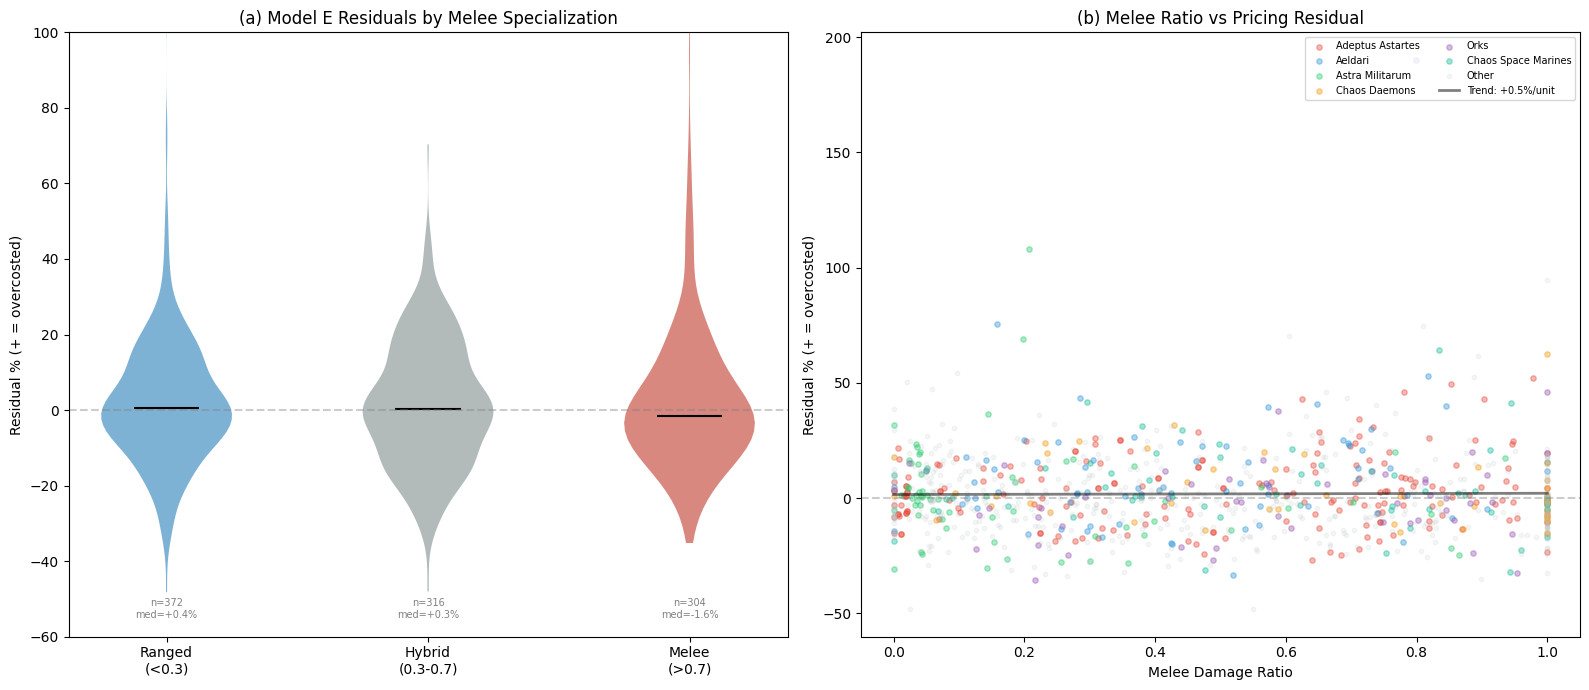

Saved melee_ranged_pricing.png


In [20]:
df['_specialist'] = pd.cut(df['melee_damage_ratio'],
                           bins=[-0.01, 0.3, 0.7, 1.01],
                           labels=['Ranged\n(<0.3)', 'Hybrid\n(0.3-0.7)', 'Melee\n(>0.7)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) Violin: residual by specialist type
ax = axes[0]
specialist_types = ['Ranged\n(<0.3)', 'Hybrid\n(0.3-0.7)', 'Melee\n(>0.7)']
data_groups = [df[df['_specialist'] == s]['residual_pct'].dropna() for s in specialist_types]
vp = ax.violinplot(data_groups, positions=[1, 2, 3], showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(['#2980b9', '#7f8c8d', '#c0392b'][i])
    body.set_alpha(0.6)
vp['cmedians'].set_color('black')

# Overlay box stats
for i, grp in enumerate(data_groups):
    ax.text(i + 1, -55, f'n={len(grp)}\nmed={grp.median():+.1f}%',
            ha='center', fontsize=7, color='gray')

ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(specialist_types)
ax.set_ylabel('Residual % (+ = overcosted)')
ax.set_title('(a) Model E Residuals by Melee Specialization')
ax.set_ylim(-60, 100)

# (b) Scatter: melee_damage_ratio vs residual_pct
ax = axes[1]
top_facs = df['faction'].value_counts().head(6).index.tolist()
fac_colors = dict(zip(top_facs, ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']))

for fac in top_facs:
    mask = df['faction'] == fac
    ax.scatter(df.loc[mask, 'melee_damage_ratio'], df.loc[mask, 'residual_pct'],
               c=fac_colors[fac], s=15, alpha=0.4, label=fac.replace('-', ' ').title())
other_mask = ~df['faction'].isin(top_facs)
ax.scatter(df.loc[other_mask, 'melee_damage_ratio'], df.loc[other_mask, 'residual_pct'],
           c='#bdc3c7', s=10, alpha=0.15, label='Other')

# Trend line
z = np.polyfit(df['melee_damage_ratio'], df['residual_pct'], 1)
p = np.poly1d(z)
xs = np.linspace(0, 1, 100)
ax.plot(xs, p(xs), 'k-', alpha=0.5, linewidth=2, label=f'Trend: {z[0]:+.1f}%/unit')

ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Melee Damage Ratio')
ax.set_ylabel('Residual % (+ = overcosted)')
ax.set_title('(b) Melee Ratio vs Pricing Residual')
ax.legend(fontsize=7, ncol=2, loc='upper right')

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'melee_ranged_pricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved melee_ranged_pricing.png")

In [21]:
# --- Save predictions for CSV generation script ---
import pickle
from datetime import datetime

output_dir = REPO / 'scripts' / 'model_output'
output_dir.mkdir(exist_ok=True)

# Save full predictions DataFrame
df.to_pickle(output_dir / 'unit_predictions.pkl')

# Save metadata
metadata = {
    'timestamp': datetime.now().isoformat(),
    'model': 'E (stats + damage + abilities + buffs + EHP + phase split, no faction dummies)',
    'train_r2': float(model_E.rsquared),
    'test_r2': float(r2_E),
    'n_features': len(feats_E),
    'n_units': len(df),
    'n_factions': int(df['faction'].nunique()),
}
with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {len(df)} unit predictions to {output_dir / 'unit_predictions.pkl'}")
print(f"Factions: {df['faction'].nunique()}, Features: {len(feats_E)}, Test R\u00b2: {r2_E:.4f}")

Saved 992 unit predictions to /Users/will.mitchell/40kdc-data/scripts/model_output/unit_predictions.pkl
Factions: 23, Features: 93, Test R²: 0.9733


## Maximum Damage Combo Search

For each of the 8 target templates, find the unit + buff stack that deals the most
damage per 100 points. Full stack: army rule + detachment rule + stratagem + leader + enhancement.

In [22]:
# --- Target Templates ---
TARGETS = [
    TargetProfile("20 Guardsmen", 20, T=3, W=1, Sv=5, keywords=['Infantry']),
    TargetProfile("10 Assault Intercessors", 10, T=4, W=2, Sv=3, keywords=['Infantry']),
    TargetProfile("5 Terminators", 5, T=5, W=3, Sv=2, invuln=4, keywords=['Infantry', 'Terminator']),
    TargetProfile("Rhino", 1, T=9, W=10, Sv=3, keywords=['Vehicle', 'Transport']),
    TargetProfile("Armiger Warglaive", 1, T=9, W=14, Sv=3, invuln=5, keywords=['Vehicle', 'Walker']),
    TargetProfile("Rogal Dorn", 1, T=12, W=18, Sv=2, keywords=['Vehicle']),
    TargetProfile("Knight Tyrant", 1, T=12, W=28, Sv=3, invuln=5, keywords=['Vehicle', 'Titanic', 'Walker']),
    TargetProfile("C'tan Nightbringer", 1, T=11, W=16, Sv=3, invuln=4, fnp=5,
                  damage_reduction=1, keywords=['Monster', 'Character']),
]

def compute_unit_total_damage(unit: dict, faction: str, target: TargetProfile,
                               buffs: Buffs = None, phase: str = 'shooting') -> float:
    """Compute total expected damage from a unit's weapons against a target.
    For ranged: fires all ranged weapons. For melee: fights with all melee weapons.
    Extra Attacks weapons are additive.
    """
    if buffs is None:
        buffs = Buffs()
    
    faction_weapons = weapon_lookup.get(faction, {})
    wtype = 'ranged' if phase == 'shooting' else 'melee'
    
    # Determine model count (minimum squad size)
    points = unit.get('points', [])
    if not points:
        return 0.0
    min_pts = min(points, key=lambda p: p.get('models', 999))
    n_models = min_pts.get('models', 1)
    
    total_damage = 0.0
    for wid in unit.get('weapon_ids', []):
        w = faction_weapons.get(wid)
        if not w or w.get('type') != wtype:
            continue
        for prof in w.get('profiles', []):
            stats = {**prof.get('stats', {}), 'keywords': prof.get('keywords', [])}
            result = expected_damage(stats, wtype, n_models, target, buffs)
            total_damage += result.get('wounds_inflicted', 0)
    
    return total_damage


def get_best_detachment_buffs(faction: str) -> tuple[str, list[str]]:
    """For a faction, find the detachment whose rule provides the best offensive buff.
    Returns (detachment_name, [description_texts])."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    det_abilities = aa_det_abilities_lookup.get(aa_code, {})
    
    best_det = None
    best_score = -1
    best_descs = []
    
    for det_name, abilities in det_abilities.items():
        descs = [a.get('description', '') for a in abilities if a.get('description')]
        score = 0
        for desc in descs:
            extracted = extract_buffs_from_text(desc)
            if extracted.get('reroll_hits_all'): score += 5
            elif extracted.get('reroll_hits_1s'): score += 2
            if extracted.get('reroll_wounds_all'): score += 5
            elif extracted.get('reroll_wounds_1s'): score += 2
            if extracted.get('grant_lethal_hits'): score += 4
            if extracted.get('grant_sustained_hits'): score += 3
            if extracted.get('grant_devastating_wounds'): score += 3
            if extracted.get('plus_to_hit'): score += 3
            if extracted.get('plus_to_wound'): score += 3
            if extracted.get('extra_ap'): score += 2
            if extracted.get('extra_attacks'): score += 2
        
        if score > best_score:
            best_score = score
            best_det = det_name
            best_descs = descs
    
    return best_det or '', best_descs


def get_best_stratagem_buff(faction: str, detachment: str, phase: str) -> tuple[str, str]:
    """Find the best damage-boosting stratagem for a faction/detachment/phase.
    Returns (stratagem_name, description)."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    strats = aa_strat_lookup.get(aa_code, {}).get(detachment, [])
    
    best_strat = None
    best_score = -1
    best_desc = ''
    
    for s in strats:
        # Filter by phase
        strat_phases = [p.lower() for p in s.get('phases', [])]
        if phase.lower() not in strat_phases and not any(phase.lower() in p for p in strat_phases):
            continue
        
        desc = s.get('description', '')
        extracted = extract_buffs_from_text(desc)
        score = 0
        if extracted.get('reroll_hits_all'): score += 5
        elif extracted.get('reroll_hits_1s'): score += 2
        if extracted.get('reroll_wounds_all'): score += 5
        elif extracted.get('reroll_wounds_1s'): score += 2
        if extracted.get('grant_lethal_hits'): score += 4
        if extracted.get('grant_sustained_hits'): score += 3
        if extracted.get('grant_devastating_wounds'): score += 3
        if extracted.get('plus_to_hit'): score += 3
        if extracted.get('plus_to_wound'): score += 3
        if extracted.get('extra_ap'): score += 2
        if extracted.get('extra_attacks'): score += 2
        if extracted.get('extra_strength'): score += 2
        
        if score > best_score:
            best_score = score
            best_strat = s.get('name', '')
            best_desc = desc
    
    return best_strat or '', best_desc


def get_best_leader_damage(unit: dict, faction: str, target: TargetProfile,
                            base_buffs: Buffs, phase: str) -> tuple[str, float, int]:
    """Find the leader that adds the most damage when attached.
    Returns (leader_id, additional_damage, leader_cost)."""
    leader_ids = bodyguard_leaders.get((faction, unit['id']), [])
    if not leader_ids:
        return '', 0.0, 0
    
    best_leader = ''
    best_extra_dmg = 0.0
    best_cost = 0
    
    for lid in leader_ids:
        leader = unit_lookup.get((faction, lid))
        if not leader:
            continue
        
        # Leader cost
        lpts = leader.get('points', [])
        if not lpts:
            continue
        lcost = min(p.get('cost', 999) for p in lpts)
        
        # Leader's own weapon damage
        leader_dmg = compute_unit_total_damage(leader, faction, target, base_buffs, phase)
        
        # Leader's ability buffs
        leader_abilities = unit_abilities.get((faction, lid), [])
        leader_descs = [a.get('description', '') for a in leader_abilities if a.get('description')]
        leader_buffs = text_to_buffs_object(leader_descs)
        
        # Merge leader buffs with base buffs (best of each)
        combined = Buffs(
            hit_mod=max(base_buffs.hit_mod, leader_buffs.hit_mod),
            wound_mod=max(base_buffs.wound_mod, leader_buffs.wound_mod),
            reroll_hits='all' if leader_buffs.reroll_hits == 'all' or base_buffs.reroll_hits == 'all'
                        else '1s' if leader_buffs.reroll_hits == '1s' or base_buffs.reroll_hits == '1s'
                        else 'none',
            reroll_wounds='all' if leader_buffs.reroll_wounds == 'all' or base_buffs.reroll_wounds == 'all'
                          else '1s' if leader_buffs.reroll_wounds == '1s' or base_buffs.reroll_wounds == '1s'
                          else 'none',
            reroll_damage=base_buffs.reroll_damage or leader_buffs.reroll_damage,
            extra_attacks=base_buffs.extra_attacks,  # leader attacks are separate
            extra_ap=max(base_buffs.extra_ap, leader_buffs.extra_ap),
            extra_strength=max(base_buffs.extra_strength, leader_buffs.extra_strength),
            grant_lethal_hits=base_buffs.grant_lethal_hits or leader_buffs.grant_lethal_hits,
            grant_sustained_hits=max(base_buffs.grant_sustained_hits, leader_buffs.grant_sustained_hits),
            grant_devastating_wounds=base_buffs.grant_devastating_wounds or leader_buffs.grant_devastating_wounds,
            grant_twin_linked=base_buffs.grant_twin_linked or leader_buffs.grant_twin_linked,
            assume_stationary=base_buffs.assume_stationary,
            assume_charged=base_buffs.assume_charged,
            assume_half_range=base_buffs.assume_half_range,
        )
        
        # Recompute unit damage with leader buffs + leader's own damage
        unit_dmg_with_buffs = compute_unit_total_damage(unit, faction, target, combined, phase)
        total_extra = unit_dmg_with_buffs + leader_dmg - compute_unit_total_damage(unit, faction, target, base_buffs, phase)
        
        # Efficiency: extra damage per extra cost
        if lcost > 0 and total_extra / lcost > best_extra_dmg / max(best_cost, 1):
            best_leader = lid
            best_extra_dmg = total_extra
            best_cost = lcost
    
    return best_leader, best_extra_dmg, best_cost

print("Combo search functions defined.")

Combo search functions defined.


In [23]:
# --- Run combo search for all targets ---
all_results = {}

for target in TARGETS:
    print(f"\n{'='*80}")
    print(f"TARGET: {target.name} (T{target.T}/W{target.W}/Sv{target.Sv}+"
          f"{f'/Inv{target.invuln}+' if target.invuln else ''}"
          f"{f'/FNP{target.fnp}+' if target.fnp else ''}"
          f"{f'/-{target.damage_reduction}D' if target.damage_reduction else ''})")
    print(f"{'='*80}")
    
    results = []
    for u in all_units:
        faction = u['_faction']
        points = u.get('points', [])
        if not points or not any(p.get('cost', 0) > 0 for p in points):
            continue
        
        min_pts = min(points, key=lambda p: p.get('models', 999))
        cost = min_pts.get('cost', 0)
        if cost <= 0:
            continue
        
        # Phase: use shooting for ranged, fight for melee. Compute both, take better.
        for phase in ['shooting', 'fight']:
            # Base damage (no buffs)
            base_buffs = Buffs(
                assume_stationary=(phase == 'shooting'),
                assume_charged=(phase == 'fight'),
                assume_half_range=True,
            )
            base_dmg = compute_unit_total_damage(u, faction, target, base_buffs, phase)
            if base_dmg <= 0:
                continue
            
            # Build buff stack
            buff_descs = []
            combo_parts = [u.get('name', u['id'])]
            
            # 1. Unit abilities
            unit_abs = unit_abilities.get((faction, u['id']), [])
            for ab in unit_abs:
                if ab.get('description'):
                    buff_descs.append(ab['description'])
            
            # 2. Army rule (faction abilities)
            aa_code = FOURTYDC_TO_AA.get(faction, '')
            faction_rules = aa_faction_rules.get(aa_code, [])
            for fr in faction_rules:
                if fr.get('description'):
                    buff_descs.append(fr['description'])
            
            # 3. Best detachment rule
            det_name, det_descs = get_best_detachment_buffs(faction)
            buff_descs.extend(det_descs)
            if det_name:
                combo_parts.append(f"det:{det_name}")
            
            # 4. Best stratagem
            strat_name, strat_desc = get_best_stratagem_buff(faction, det_name, phase.capitalize())
            if strat_desc:
                buff_descs.append(strat_desc)
                combo_parts.append(f"strat:{strat_name}")
            
            # Build buffs object
            full_buffs = text_to_buffs_object(buff_descs)
            full_buffs.assume_stationary = (phase == 'shooting')
            full_buffs.assume_charged = (phase == 'fight')
            full_buffs.assume_half_range = True
            
            buffed_dmg = compute_unit_total_damage(u, faction, target, full_buffs, phase)
            
            # 5. Leader
            leader_id, leader_extra, leader_cost = get_best_leader_damage(
                u, faction, target, full_buffs, phase
            )
            total_cost = cost + leader_cost
            total_dmg = buffed_dmg + leader_extra
            if leader_id:
                leader_unit = unit_lookup.get((faction, leader_id))
                if leader_unit:
                    combo_parts.append(f"leader:{leader_unit.get('name', leader_id)}")
            
            # Damage per 100 points
            dmg_per_100 = total_dmg / total_cost * 100
            
            results.append({
                'unit_name': u.get('name', u['id']),
                'faction': faction,
                'phase': phase,
                'cost': total_cost,
                'base_dmg': base_dmg,
                'buffed_dmg': total_dmg,
                'dmg_per_100': dmg_per_100,
                'combo': ' + '.join(combo_parts),
                'wounds_or_kills': total_dmg if target.models == 1 else total_dmg / target.W,
            })
    
    # Sort by damage per 100 points
    results.sort(key=lambda r: r['dmg_per_100'], reverse=True)
    all_results[target.name] = results
    
    # Print top 10
    print(f"\nTop 10 by damage per 100pts:")
    print(f"{'Rank':<5} {'Unit':<30} {'Faction':<20} {'Phase':<8} {'Cost':>5} "
          f"{'Base':>6} {'Buffed':>7} {'Dmg/100':>8} {'Kills/W':>8}")
    print("-" * 120)
    seen = set()
    rank = 0
    for r in results:
        key = (r['unit_name'], r['faction'])
        if key in seen:
            continue
        seen.add(key)
        rank += 1
        if rank > 10:
            break
        metric = f"{r['wounds_or_kills']:.1f}k" if target.models > 1 else f"{r['wounds_or_kills']:.1f}w"
        print(f"{rank:<5} {r['unit_name']:<30} {r['faction']:<20} {r['phase']:<8} "
              f"{r['cost']:>5} {r['base_dmg']:>6.1f} {r['buffed_dmg']:>7.1f} "
              f"{r['dmg_per_100']:>8.2f} {metric:>8}")
    
    # Print best combo breakdown
    if results:
        best = results[0]
        print(f"\n  Best combo: {best['combo']}")

print(f"\n{'='*80}")
print("Combo search complete.")


TARGET: 20 Guardsmen (T3/W1/Sv5+)



Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   105   99.4   196.6   187.21   196.6k
2     Tactical Squad                 adeptus-astartes     shooting   215  208.8   331.3   154.07   331.3k
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155  134.6   214.4   138.35   214.4k
4     Battle Sisters Squad           adepta-sororitas     shooting   155  138.4   210.0   135.50   210.0k
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   49.0    81.2   135.42    81.2k
6     Cadian Shock Troops            astra-militarum      shooting   105   77.2   139.2   132.61   139.2k
7     Kasrkin                        astra-militarum      shooting   150  114.3   197.5   131.65   197.5k


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   130   80.2   217.1   166.98   108.5k
2     Tactical Squad                 adeptus-astartes     shooting   215  180.2   321.7   149.65   160.9k
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155  119.0   198.8   128.29    99.4k
4     Kasrkin                        astra-militarum      shooting   150   88.0   186.7   124.47    93.3k
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   49.4    74.1   123.54    37.1k
6     Battle Sisters Squad           adepta-sororitas     shooting   155  124.4   183.0   118.05    91.5k
7     Tempestus Aquilons             astra-militarum      shooting   100   83.1   117.2   117.18    58.6k


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   220  104.7   225.2   102.35    75.1k
2     Death Korps of Krieg           astra-militarum      shooting   105   35.8   103.8    98.88    34.6k
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155   63.7   143.8    92.75    47.9k
4     Helbrute                       thousand-sons        shooting   110    9.6   100.9    91.72    33.6k
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   28.9    51.8    86.25    17.2k
6     Helbrute                       world-eaters         shooting   120   10.4    96.2    80.15    32.1k
7     Kasrkin                        astra-militarum      shooting   150   42.1   116.6    77.73    38.9k


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   130   38.4   137.7   105.90   137.7w
2     Tactical Squad                 adeptus-astartes     shooting   220  101.5   181.4    82.45   181.4w
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155   62.6   115.1    74.27   115.1w
4     Helbrute                       thousand-sons        shooting   110   12.8    77.4    70.33    77.4w
5     Kasrkin                        astra-militarum      shooting   150   42.2   104.8    69.87   104.8w
6     Tempestus Aquilons             astra-militarum      shooting   100   40.1    69.6    69.58    69.6w
7     Catachan Command Squad         astra-militarum      shooting    65   26.5    43.0    66.20    43.0w


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   130   38.1   135.1   103.96   135.1w
2     Tactical Squad                 adeptus-astartes     shooting   220  111.3   222.7   101.23   222.7w
3     Helbrute                       thousand-sons        shooting   110   10.9    99.9    90.82    99.9w
4     Sisters of Battle Squad        agents-of-the-imperium shooting   155   65.1   136.7    88.17   136.7w
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   33.1    49.5    82.43    49.5w
6     Jakhals                        world-eaters         fight       65   18.4    52.2    80.30    52.2w
7     Helbrute                       world-eaters         shooting   120   12.9    95.6    79.65    95.6w


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   220   94.3   243.7   110.76   243.7w
2     Death Korps of Krieg           astra-militarum      shooting   130   30.0   139.1   106.99   139.1w
3     Helbrute                       thousand-sons        shooting   110    7.3   111.0   100.94   111.0w
4     Sisters of Battle Squad        agents-of-the-imperium shooting   155   54.8   142.4    91.90   142.4w
5     Helbrute                       world-eaters         shooting   120    8.6   103.1    85.88   103.1w
6     Servitor Battleclade           adeptus-mechanicus   shooting    60   25.0    49.8    82.92    49.8w
7     Jakhals                        world-eaters         fight       65   20.8    52.3    80.40    52.3w


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   225  114.5   312.3   138.78   312.3w
2     Sisters of Battle Squad        agents-of-the-imperium shooting   155   57.2   181.2   116.88   181.2w
3     Death Korps of Krieg           astra-militarum      shooting   105   32.5   122.5   116.65   122.5w
4     Helbrute                       thousand-sons        shooting   110    7.9   125.3   113.89   125.3w
5     Helbrute                       world-eaters         shooting   120    9.5   134.2   111.83   134.2w
6     Imperial Navy Breachers        agents-of-the-imperium shooting   130   26.8   142.8   109.88   142.8w
7     Jakhals                        world-eaters         fight       65   28.1    70.9   109.15    70.


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   225   38.6   139.8    62.15   139.8w
2     Sisters of Battle Squad        agents-of-the-imperium shooting   155   26.3    88.0    56.79    88.0w
3     Imperial Navy Breachers        agents-of-the-imperium shooting   130   10.6    71.8    55.20    71.8w
4     Jakhals                        world-eaters         fight       65    7.8    33.9    52.21    33.9w
5     Helbrute                       world-eaters         shooting   120    4.0    61.6    51.32    61.6w
6     Fortis Kill Team               adeptus-astartes     shooting   245   47.9   125.0    51.01   125.0w
7     Helbrute                       thousand-sons        shooting   110    3.0    55.1    50.12    55.

OVERCOSTED UNITS — DO THEY DELIVER DAMAGE?
Unit                           Faction               Resid%  AvgDmg/100  vs Horde  vs Elite vs Vehicle  vs C'tan Verdict             
--------------------------------------------------------------------------------------------------------------------------------------------
Gretchin                       orks                   +190%        17.5      57.0      10.7       14.3       4.8 EFFICIENT (model is blind)
Death Korps of Krieg           astra-militarum        +108%        70.6     153.0      55.1       58.5      19.3 EFFICIENT (model is blind)
Neurogaunts                    tyranids                +95%         8.3      27.2       5.4        5.4       3.6 EFFICIENT (model is blind)
D-cannon Platform              aeldari                 +75%         3.1       3.3       2.5        3.0       1.4 GENUINELY OVERCOSTED
Subductor Squad                agents-of-the-imperium    +75%         3.6      13.4       2.1        1.8       1.2 GENUINELY OVE

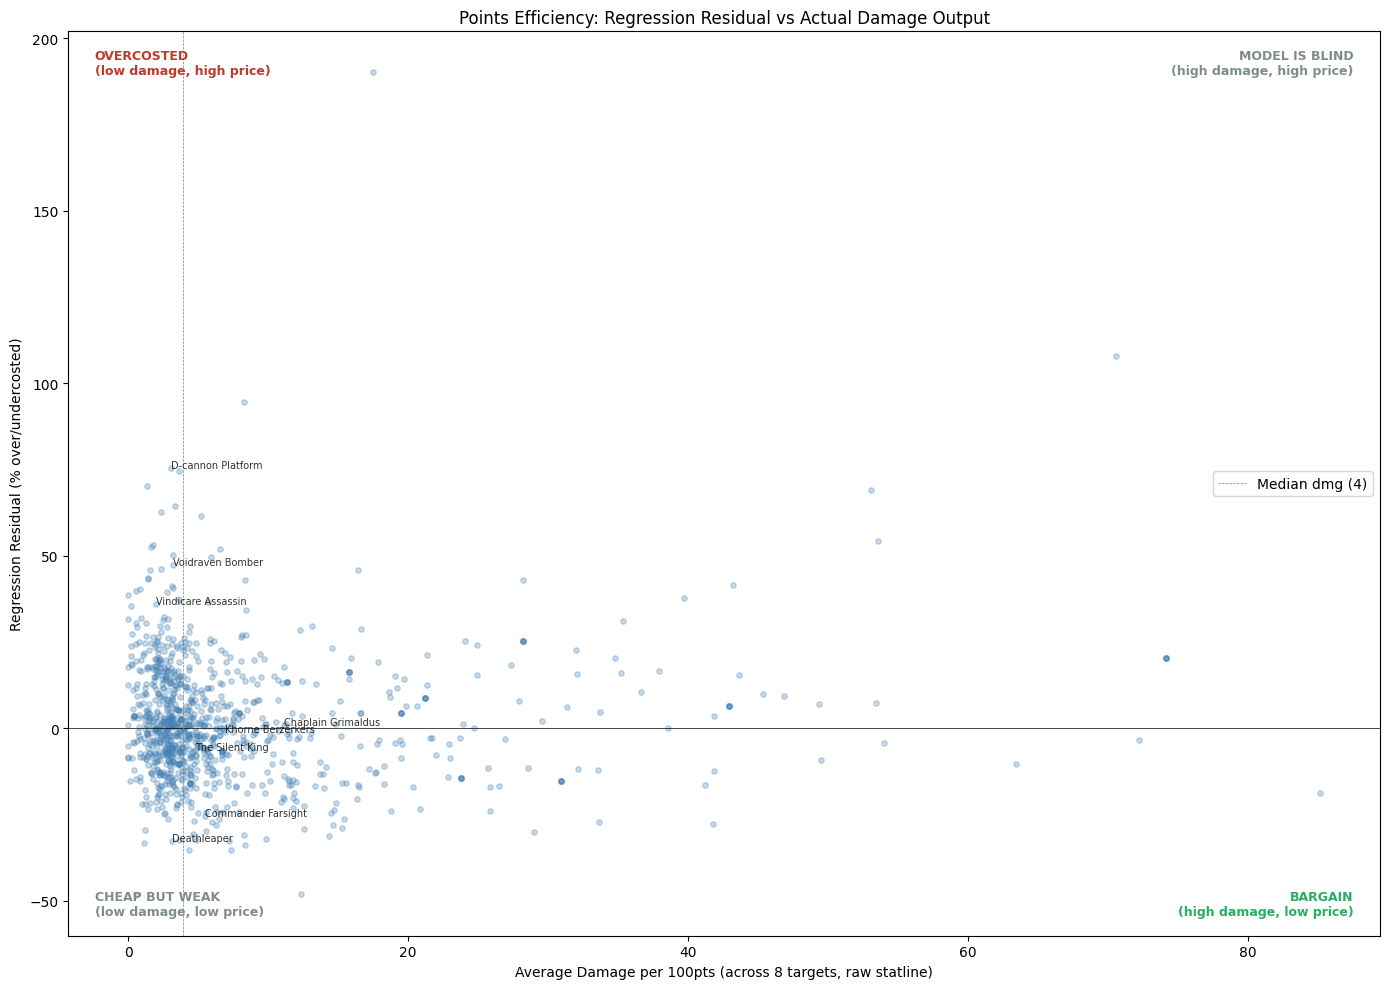

Saved residual_vs_damage.png


In [24]:
# --- Cross-reference: residual vs actual damage efficiency ---
# For every unit, compute average damage per 100pts across all 8 targets (shooting + melee best)
# This reveals whether "overcosted" units actually deliver damage or are genuinely overpriced.

unit_damage_efficiency = []

for u in all_units:
    faction = u['_faction']
    points = u.get('points', [])
    if not points or not any(p.get('cost', 0) > 0 for p in points):
        continue
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    if cost <= 0:
        continue
    
    # Compute damage into each target (no buffs — raw statline only)
    target_damages = []
    for target in TARGETS:
        best_phase_dmg = 0
        for phase in ['shooting', 'fight']:
            buffs = Buffs(
                assume_stationary=(phase == 'shooting'),
                assume_charged=(phase == 'fight'),
                assume_half_range=True,
            )
            dmg = compute_unit_total_damage(u, faction, target, buffs, phase)
            best_phase_dmg = max(best_phase_dmg, dmg)
        target_damages.append(best_phase_dmg)
    
    avg_dmg = np.mean(target_damages)
    avg_dmg_per_100 = avg_dmg / cost * 100
    
    unit_damage_efficiency.append({
        'unit_id': u['id'],
        'unit_name': u.get('name', ''),
        'faction': faction,
        'cost': cost,
        'avg_dmg_per_100': avg_dmg_per_100,
        'avg_raw_dmg': avg_dmg,
        'dmg_vs_horde': target_damages[0] / cost * 100,  # guardsmen
        'dmg_vs_elite': target_damages[2] / cost * 100,   # terminators
        'dmg_vs_vehicle': target_damages[4] / cost * 100,  # armiger
        'dmg_vs_nightmare': target_damages[7] / cost * 100,  # nightbringer
    })

dmg_df = pd.DataFrame(unit_damage_efficiency)

# Merge with residuals from df
merge_df = df[['unit_id', 'faction', 'residual_pct', 'ppm', 'predicted_ppm']].copy()
combined = dmg_df.merge(merge_df, on=['unit_id', 'faction'], how='inner')

# --- Print the overcosted units WITH their damage efficiency ---
print("OVERCOSTED UNITS — DO THEY DELIVER DAMAGE?")
print("=" * 140)
print(f"{'Unit':<30s} {'Faction':<20s} {'Resid%':>7s} {'AvgDmg/100':>11s} "
      f"{'vs Horde':>9s} {'vs Elite':>9s} {'vs Vehicle':>10s} {'vs C\'tan':>9s} {'Verdict':<20s}")
print("-" * 140)

# Get the top 20 overcosted
overcosted = combined.nlargest(20, 'residual_pct')
# Also get the median damage efficiency as reference
median_dmg = combined['avg_dmg_per_100'].median()

for _, row in overcosted.iterrows():
    verdict = "EFFICIENT (model is blind)" if row['avg_dmg_per_100'] > median_dmg else "GENUINELY OVERCOSTED"
    print(f"{row['unit_name']:<30s} {row['faction']:<20s} {row['residual_pct']:>+6.0f}% "
          f"{row['avg_dmg_per_100']:>11.1f} "
          f"{row['dmg_vs_horde']:>9.1f} {row['dmg_vs_elite']:>9.1f} "
          f"{row['dmg_vs_vehicle']:>10.1f} {row['dmg_vs_nightmare']:>9.1f} {verdict:<20s}")

print(f"\nMedian damage/100pts across all units: {median_dmg:.1f}")
print(f"Units above median are delivering real damage — the model just can't see it.")

# --- Print the GENUINELY overcosted (high residual + LOW damage) ---
print("\n" + "=" * 140)
print("GENUINELY OVERCOSTED: high residual AND below-median damage output")
print("-" * 140)
genuine_over = combined[(combined['residual_pct'] > 20) & (combined['avg_dmg_per_100'] < median_dmg)]
genuine_over = genuine_over.sort_values('residual_pct', ascending=False)
for _, row in genuine_over.head(20).iterrows():
    print(f"  {row['unit_name']:<30s} {row['faction']:<20s} resid={row['residual_pct']:>+6.0f}%  "
          f"dmg/100={row['avg_dmg_per_100']:>6.1f} (median={median_dmg:.1f})")

# --- And the GENUINELY undercosted (low residual + HIGH damage) ---
print("\n" + "=" * 140)
print("GENUINELY UNDERCOSTED: low residual AND above-median damage output")
print("-" * 140)
genuine_under = combined[(combined['residual_pct'] < -20) & (combined['avg_dmg_per_100'] > median_dmg)]
genuine_under = genuine_under.sort_values('residual_pct')
for _, row in genuine_under.head(20).iterrows():
    print(f"  {row['unit_name']:<30s} {row['faction']:<20s} resid={row['residual_pct']:>+6.0f}%  "
          f"dmg/100={row['avg_dmg_per_100']:>6.1f} (median={median_dmg:.1f})")

# --- Scatter: residual vs damage efficiency ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(combined['avg_dmg_per_100'], combined['residual_pct'], alpha=0.3, s=15, c='steelblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(median_dmg, color='gray', linewidth=0.5, linestyle='--', label=f'Median dmg ({median_dmg:.0f})')
ax.set_xlabel('Average Damage per 100pts (across 8 targets, raw statline)')
ax.set_ylabel('Regression Residual (% over/undercosted)')
ax.set_title('Points Efficiency: Regression Residual vs Actual Damage Output')

# Quadrant labels
ax.text(0.02, 0.98, 'OVERCOSTED\n(low damage, high price)', transform=ax.transAxes,
        va='top', ha='left', fontsize=9, color='#c0392b', weight='bold')
ax.text(0.98, 0.98, 'MODEL IS BLIND\n(high damage, high price)', transform=ax.transAxes,
        va='top', ha='right', fontsize=9, color='#7f8c8d', weight='bold')
ax.text(0.02, 0.02, 'CHEAP BUT WEAK\n(low damage, low price)', transform=ax.transAxes,
        va='bottom', ha='left', fontsize=9, color='#7f8c8d', weight='bold')
ax.text(0.98, 0.02, 'BARGAIN\n(high damage, low price)', transform=ax.transAxes,
        va='bottom', ha='right', fontsize=9, color='#27ae60', weight='bold')

# Annotate notable units
notable = [
    'Khorne Berzerkers', 'Voidraven Bomber', 'D-cannon Platform',
    "Emperor\'s Champion", 'Vindicare Assassin', 'The Silent King',
    'Deathleaper', 'Commander Farsight', 'Chaplain Grimaldus',
]
for _, row in combined.iterrows():
    if any(n.replace("\\'", "\'") in row['unit_name'] for n in notable):
        ax.annotate(row['unit_name'][:20], (row['avg_dmg_per_100'], row['residual_pct']),
                    fontsize=7, alpha=0.8)

ax.legend()
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'residual_vs_damage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved residual_vs_damage.png")


### Points Efficiency Dashboard
Cost efficiency from multiple angles: do expensive units deliver more damage or durability per point?

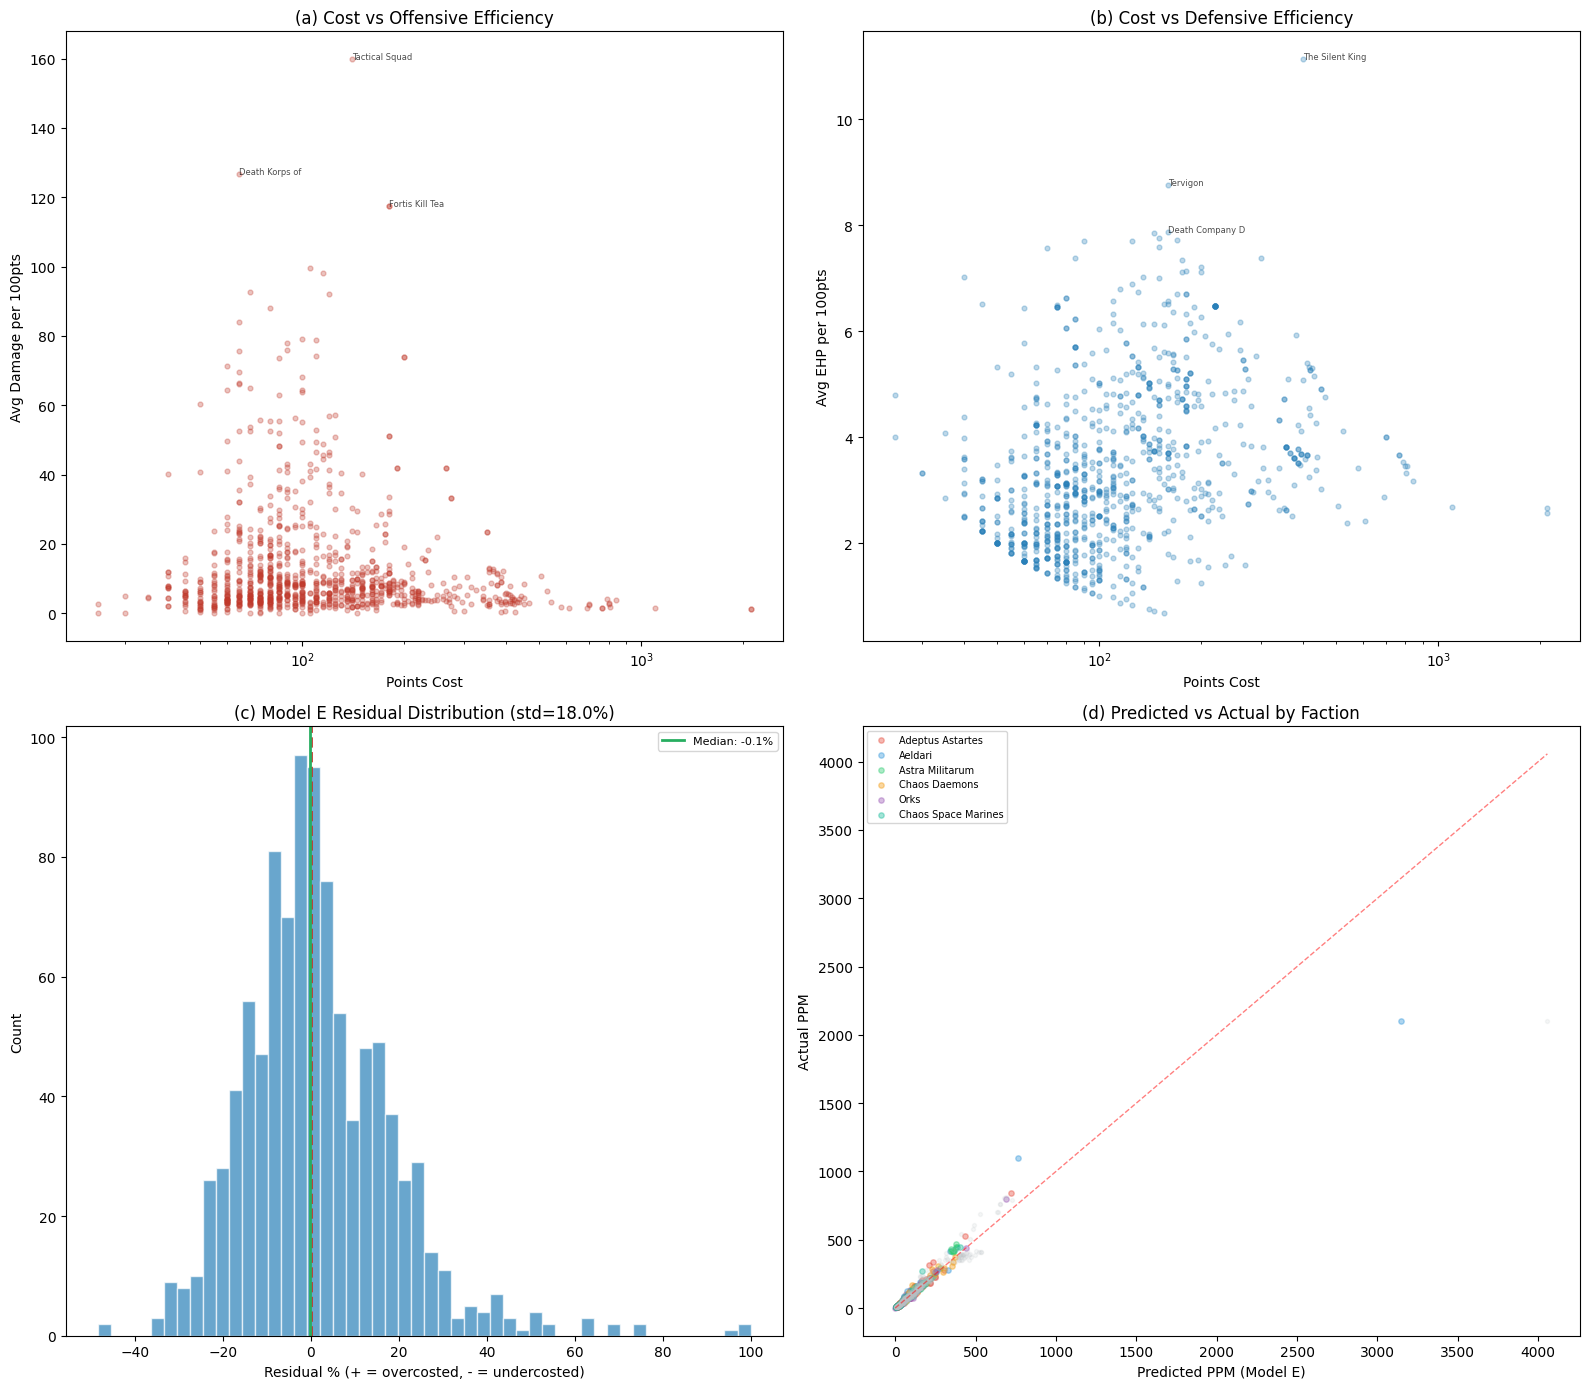

Saved efficiency_dashboard.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# (a) Cost vs damage per 100pts
ax = axes[0, 0]
ax.scatter(df['cost'], df['avg_dmg_per_100'], s=12, alpha=0.3, c='#c0392b')
ax.set_xlabel('Points Cost')
ax.set_ylabel('Avg Damage per 100pts')
ax.set_title('(a) Cost vs Offensive Efficiency')
ax.set_xscale('log')
# Annotate corners
for _, row in df.nlargest(3, 'avg_dmg_per_100').iterrows():
    ax.annotate(row['unit_name'][:15], (row['cost'], row['avg_dmg_per_100']), fontsize=6, alpha=0.7)

# (b) Cost vs EHP per 100pts
ax = axes[0, 1]
ax.scatter(df['cost'], df['avg_ehp_per_100'], s=12, alpha=0.3, c='#2980b9')
ax.set_xlabel('Points Cost')
ax.set_ylabel('Avg EHP per 100pts')
ax.set_title('(b) Cost vs Defensive Efficiency')
ax.set_xscale('log')
for _, row in df.nlargest(3, 'avg_ehp_per_100').iterrows():
    ax.annotate(row['unit_name'][:15], (row['cost'], row['avg_ehp_per_100']), fontsize=6, alpha=0.7)

# (c) Residual distribution
ax = axes[1, 0]
ax.hist(df['residual_pct'].clip(-60, 100), bins=50, color='#2980b9', alpha=0.7, edgecolor='white')
ax.axvline(0, color='#c0392b', linewidth=2, linestyle='--')
ax.axvline(df['residual_pct'].median(), color='#27ae60', linewidth=2, linestyle='-',
           label=f'Median: {df["residual_pct"].median():+.1f}%')
ax.set_xlabel('Residual % (+ = overcosted, - = undercosted)')
ax.set_ylabel('Count')
ax.set_title(f'(c) Model E Residual Distribution (std={df["residual_pct"].std():.1f}%)')
ax.legend(fontsize=8)

# (d) Predicted vs Actual PPM colored by top factions
ax = axes[1, 1]
top_facs = df['faction'].value_counts().head(6).index.tolist()
fac_colors = dict(zip(top_facs, ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']))
for fac in top_facs:
    mask = df['faction'] == fac
    ax.scatter(df.loc[mask, 'predicted_ppm'], df.loc[mask, 'ppm'],
               c=fac_colors[fac], s=15, alpha=0.4, label=fac.replace('-', ' ').title())
other_mask = ~df['faction'].isin(top_facs)
ax.scatter(df.loc[other_mask, 'predicted_ppm'], df.loc[other_mask, 'ppm'],
           c='#bdc3c7', s=8, alpha=0.15)
max_val = max(df['ppm'].max(), df['predicted_ppm'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, alpha=0.5)
ax.set_xlabel('Predicted PPM (Model E)')
ax.set_ylabel('Actual PPM')
ax.set_title('(d) Predicted vs Actual by Faction')
ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'efficiency_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved efficiency_dashboard.png")

## Marginal Buff Attribution: Leader-Bodyguard Pricing

Some leaders provide strong damage buffs (full hit rerolls, +1 to wound, lethal hits) that make
their bodyguard dramatically more lethal. GW prices the leader+bodyguard combo as a package,
but our regression model prices each unit independently — creating phantom over/undercosting.

For every valid (leader, bodyguard) pair we decompose damage into three buckets:
- **bodyguard base**: unit damage with its own abilities only
- **leader solo**: leader's own weapon damage
- **buff uplift**: extra damage the bodyguard gains from the leader's buffs (synergy)

Then we test whether accounting for leader buff access improves the pricing model.

In [26]:
# --- Compute marginal buff attribution for all (leader, bodyguard) pairs ---

pair_records = []
skipped = 0

for (faction, bg_id), leader_ids in bodyguard_leaders.items():
    bg = unit_lookup.get((faction, bg_id))
    if not bg or not bg.get('points'):
        skipped += 1
        continue
    bg_pts = [p for p in bg['points'] if p.get('cost', 0) > 0]
    if not bg_pts:
        skipped += 1
        continue
    bg_cost = min(p['cost'] for p in bg_pts)

    for lid in leader_ids:
        ldr = unit_lookup.get((faction, lid))
        if not ldr or not ldr.get('points'):
            continue
        ldr_pts = [p for p in ldr['points'] if p.get('cost', 0) > 0]
        if not ldr_pts:
            continue
        ldr_cost = min(p['cost'] for p in ldr_pts)

        for arch_name, target in ARCHETYPE_TARGETS.items():
            for phase in ['shooting', 'fight']:
                # 1. Bodyguard with own DSL buffs only
                bg_buffs = dsl_to_buffs(faction, bg_id, phase)
                bg_base = compute_unit_total_damage(bg, faction, target, bg_buffs, phase)

                # 2. Leader's own weapon damage
                ldr_buffs = get_leader_dsl_buffs(faction, lid, phase)
                ldr_solo = compute_unit_total_damage(ldr, faction, target, ldr_buffs, phase)

                # 3. Bodyguard with leader buffs merged in
                combined_buffs = merge_buffs(bg_buffs, ldr_buffs)
                bg_with_ldr = compute_unit_total_damage(bg, faction, target, combined_buffs, phase)

                buff_uplift = bg_with_ldr - bg_base

                pair_records.append({
                    'faction': faction,
                    'leader_id': lid,
                    'bodyguard_id': bg_id,
                    'leader_name': ldr.get('name', lid),
                    'bodyguard_name': bg.get('name', bg_id),
                    'leader_cost': ldr_cost,
                    'bodyguard_cost': bg_cost,
                    'target': arch_name,
                    'phase': phase,
                    'bg_base_dmg': bg_base,
                    'ldr_solo_dmg': ldr_solo,
                    'bg_with_ldr_dmg': bg_with_ldr,
                    'buff_uplift': buff_uplift,
                    'combined_dmg': bg_with_ldr + ldr_solo,
                })

raw_pair_df = pd.DataFrame(pair_records)
print(f'Computed {len(raw_pair_df)} raw records '
      f'({len(raw_pair_df) // 8} pairs x 4 targets x 2 phases), '
      f'skipped {skipped} bodyguards with no points')

# --- Aggregate: best phase per target, then average across targets ---
# For each (faction, leader, bodyguard, target): take the phase with higher combined damage
best_phase = (raw_pair_df
    .sort_values('combined_dmg', ascending=False)
    .groupby(['faction', 'leader_id', 'bodyguard_id', 'target'])
    .first()
    .reset_index())

# Average across 4 archetype targets
pair_df = (best_phase
    .groupby(['faction', 'leader_id', 'bodyguard_id', 'leader_name', 'bodyguard_name',
              'leader_cost', 'bodyguard_cost'])
    .agg({
        'bg_base_dmg': 'mean',
        'ldr_solo_dmg': 'mean',
        'bg_with_ldr_dmg': 'mean',
        'buff_uplift': 'mean',
        'combined_dmg': 'mean',
    })
    .reset_index())

pair_df['combined_cost'] = pair_df['leader_cost'] + pair_df['bodyguard_cost']
pair_df['buff_uplift_pct'] = np.where(
    pair_df['bg_base_dmg'] > 0,
    pair_df['buff_uplift'] / pair_df['bg_base_dmg'] * 100,
    0)
pair_df['uplift_per_ldr_pt'] = pair_df['buff_uplift'] / pair_df['leader_cost']
pair_df['combined_dmg_per_100'] = pair_df['combined_dmg'] / pair_df['combined_cost'] * 100

print(f'Aggregated to {len(pair_df)} unique (leader, bodyguard) pairs')
print(f'Pairs with nonzero buff uplift: {(pair_df["buff_uplift"] > 0.01).sum()}')
print(f'Average buff uplift: {pair_df["buff_uplift"].mean():.2f} damage '
      f'({pair_df["buff_uplift_pct"].mean():.1f}% of bodyguard base)')

Computed 5848 raw records (731 pairs x 4 targets x 2 phases), skipped 3 bodyguards with no points
Aggregated to 731 unique (leader, bodyguard) pairs
Pairs with nonzero buff uplift: 276
Average buff uplift: 2.28 damage (9.3% of bodyguard base)


In [27]:
# --- Leader Buff Attribution: Rankings & Tables ---

# 1. Top 20 leaders by average buff uplift (across their best bodyguard)
leader_best_bg = (pair_df
    .sort_values('buff_uplift', ascending=False)
    .groupby(['faction', 'leader_id', 'leader_name', 'leader_cost'])
    .first()
    .reset_index()
    .sort_values('buff_uplift', ascending=False))

print('=' * 120)
print('TOP 20 LEADERS BY BUFF UPLIFT (damage added to their best bodyguard)')
print('-' * 120)
print(f'{"Leader":<30s} {"Faction":<22s} {"Cost":>5s} {"Best Bodyguard":<25s} '
      f'{"Buff Uplift":>11s} {"Uplift %":>9s} {"Uplift/pt":>10s}')
print('-' * 120)
for _, row in leader_best_bg.head(20).iterrows():
    print(f'{row["leader_name"][:29]:<30s} {row["faction"][:21]:<22s} '
          f'{row["leader_cost"]:>5.0f} {row["bodyguard_name"][:24]:<25s} '
          f'{row["buff_uplift"]:>+10.2f}d {row["buff_uplift_pct"]:>+8.1f}% '
          f'{row["uplift_per_ldr_pt"]:>9.4f}')

# 2. Top 20 bodyguards by best available leader buff
bg_best_ldr = (pair_df
    .sort_values('buff_uplift', ascending=False)
    .groupby(['faction', 'bodyguard_id', 'bodyguard_name', 'bodyguard_cost'])
    .first()
    .reset_index()
    .sort_values('buff_uplift', ascending=False))

print()
print('=' * 120)
print('TOP 20 BODYGUARDS BY LEADER ACCESS VALUE (most damage gained from best leader)')
print('-' * 120)
print(f'{"Bodyguard":<30s} {"Faction":<22s} {"Cost":>5s} {"Best Leader":<25s} '
      f'{"Buff Uplift":>11s} {"Uplift %":>9s} {"Base Dmg":>9s}')
print('-' * 120)
for _, row in bg_best_ldr.head(20).iterrows():
    print(f'{row["bodyguard_name"][:29]:<30s} {row["faction"][:21]:<22s} '
          f'{row["bodyguard_cost"]:>5.0f} {row["leader_name"][:24]:<25s} '
          f'{row["buff_uplift"]:>+10.2f}d {row["buff_uplift_pct"]:>+8.1f}% '
          f'{row["bg_base_dmg"]:>8.2f}d')

# 3. Leader efficiency: buff uplift per leader point
leader_efficiency = (pair_df
    .sort_values('uplift_per_ldr_pt', ascending=False)
    .groupby(['faction', 'leader_id', 'leader_name', 'leader_cost'])
    .first()
    .reset_index()
    .sort_values('uplift_per_ldr_pt', ascending=False))

print()
print('=' * 120)
print('TOP 20 LEADERS BY BUFF EFFICIENCY (most buff uplift per point spent on leader)')
print('-' * 120)
print(f'{"Leader":<30s} {"Faction":<22s} {"Cost":>5s} {"Best Bodyguard":<25s} '
      f'{"Uplift/pt":>10s} {"Buff Uplift":>11s}')
print('-' * 120)
for _, row in leader_efficiency.head(20).iterrows():
    print(f'{row["leader_name"][:29]:<30s} {row["faction"][:21]:<22s} '
          f'{row["leader_cost"]:>5.0f} {row["bodyguard_name"][:24]:<25s} '
          f'{row["uplift_per_ldr_pt"]:>9.4f}d {row["buff_uplift"]:>+10.2f}d')

# 4. Synergy breakdown: top 20 combos by combined damage, showing share of each bucket
top_combos = pair_df.nlargest(20, 'combined_dmg').copy()
top_combos['bg_base_share'] = top_combos['bg_base_dmg'] / top_combos['combined_dmg'] * 100
top_combos['ldr_solo_share'] = top_combos['ldr_solo_dmg'] / top_combos['combined_dmg'] * 100
top_combos['buff_uplift_share'] = top_combos['buff_uplift'] / top_combos['combined_dmg'] * 100

print()
print('=' * 130)
print('TOP 20 COMBOS BY COMBINED DAMAGE (share breakdown: base / leader wpns / buff uplift)')
print('-' * 130)
print(f'{"Leader + Bodyguard":<50s} {"Faction":<18s} {"Cost":>5s} '
      f'{"Combined":>9s} {"Base":>6s} {"Ldr":>6s} {"Buff":>6s} '
      f'{"Dmg/100":>8s}')
print('-' * 130)
for _, row in top_combos.iterrows():
    combo_name = f'{row["leader_name"][:22]} + {row["bodyguard_name"][:24]}'
    print(f'{combo_name:<50s} {row["faction"][:17]:<18s} {row["combined_cost"]:>5.0f} '
          f'{row["combined_dmg"]:>8.2f}d {row["bg_base_share"]:>5.0f}% '
          f'{row["ldr_solo_share"]:>5.0f}% {row["buff_uplift_share"]:>5.0f}% '
          f'{row["combined_dmg_per_100"]:>7.2f}d')

TOP 20 LEADERS BY BUFF UPLIFT (damage added to their best bodyguard)
------------------------------------------------------------------------------------------------------------------------
Leader                         Faction                 Cost Best Bodyguard            Buff Uplift  Uplift %  Uplift/pt
------------------------------------------------------------------------------------------------------------------------
Ministorum Priest              agents-of-the-imperiu     40 Sisters of Battle Squad       +62.15d    +85.8%    1.5538
Ministorum Priest              astra-militarum           40 Kasrkin                       +60.07d    +93.4%    1.5018
Ministorum Priest              adepta-sororitas          50 Battle Sisters Squad          +56.96d    +70.5%    1.1392
Captain                        adeptus-astartes          80 Tactical Squad                +32.66d    +16.9%    0.4082
Blood Angels Captain           adeptus-astartes          80 Tactical Squad                +32.66d 

In [28]:
# --- Does leader buff value explain residuals? ---
# Compute best_leader_buff_value per bodyguard unit, then add to regression

# Per bodyguard: best leader's buff uplift
bg_best_uplift = (pair_df
    .groupby(['faction', 'bodyguard_id'])
    .agg(best_leader_buff_value=('buff_uplift', 'max'),
         best_leader_buff_pct=('buff_uplift_pct', 'max'))
    .reset_index()
    .rename(columns={'bodyguard_id': 'unit_id'}))

# Merge into df (drop old columns if re-running)
_drop = [c for c in ['best_leader_buff_value', 'best_leader_buff_pct',
                      'predicted_log_ppm_G', 'predicted_ppm_G',
                      'residual_pct_G', 'residual_change'] if c in df.columns]
if _drop:
    df = df.drop(columns=_drop)
df = (df
    .merge(bg_best_uplift, on=['faction', 'unit_id'], how='left')
    .fillna({'best_leader_buff_value': 0, 'best_leader_buff_pct': 0}))
df['best_leader_buff_value'] = pd.to_numeric(df['best_leader_buff_value'], errors='coerce').fillna(0)

print(f'Units with leader buff access: {(df["best_leader_buff_value"] > 0).sum()} '
      f'of {len(df)} ({(df["best_leader_buff_value"] > 0).mean()*100:.0f}%)')
print(f'Mean buff value (where nonzero): '
      f'{df.loc[df["best_leader_buff_value"] > 0, "best_leader_buff_value"].mean():.2f} damage')

# Run Model G: Model E + best_leader_buff_value
feats_G = feats_E + ['best_leader_buff_value']
model_G, r2_G = run_ols(feats_G, 'Model G')

print(f'\n{"Model":<25s} {"Train R²":>10s} {"Test R²":>10s} {"Features":>10s}')
print('-' * 60)
print(f'{"E (current best)":<25s} {model_E.rsquared:>10.4f} {r2_E:>10.4f} {model_E.df_model:>10.0f}')
print(f'{"G (E + leader buff)":<25s} {model_G.rsquared:>10.4f} {r2_G:>10.4f} {model_G.df_model:>10.0f}')
print(f'{"Delta":<25s} {model_G.rsquared - model_E.rsquared:>+10.4f} {r2_G - r2_E:>+10.4f}')

# Leader buff coefficient
coef = model_G.params.get('best_leader_buff_value', 0)
pval = model_G.pvalues.get('best_leader_buff_value', 1)
pct_effect = (np.exp(coef) - 1) * 100
sig = '***' if pval < 0.001 else '** ' if pval < 0.01 else '*  ' if pval < 0.05 else 'ns '
print(f'\nbest_leader_buff_value coefficient: {pct_effect:+.1f}% per unit of buff damage '
      f'(p={pval:.4f}) {sig}')

# --- Before/After residuals for top overcosted units ---
X_all_G = sm.add_constant(df[feats_G].astype(float))
predicted_log_ppm_G = model_G.predict(X_all_G)
predicted_ppm_G = np.exp(predicted_log_ppm_G)
residual_pct_G = (df['ppm'] / predicted_ppm_G - 1) * 100
residual_change = residual_pct_G - df['residual_pct']
df = df.copy()  # defragment before adding columns
df = df.assign(predicted_log_ppm_G=predicted_log_ppm_G,
               predicted_ppm_G=predicted_ppm_G,
               residual_pct_G=residual_pct_G,
               residual_change=residual_change)
has_leader_access = df['best_leader_buff_value'] > 0

print(f'\n{"="*100}')
print('RESIDUAL CHANGE: Top 15 overcosted units from Model E \u2192 how they change in Model G')
print(f'Negative change = moved toward fair pricing (leader buff access explains some overcosting)')
print(f'{"-"*100}')
print(f'{"Unit":<35s} {"Faction":<20s} {"Buff":>6s} {"E resid":>8s} {"G resid":>8s} {"Change":>8s} {"Leader":>1s}')
print(f'{"-"*100}')
top_overcosted = df.nlargest(15, 'residual_pct')
for _, row in top_overcosted.iterrows():
    has_ldr = '*' if row['best_leader_buff_value'] > 0 else ' '
    print(f'{row["unit_name"][:34]:<35s} {row["faction"][:19]:<20s} '
          f'{row["best_leader_buff_value"]:>5.1f}d '
          f'{row["residual_pct"]:>+7.1f}% {row["residual_pct_G"]:>+7.1f}% '
          f'{row["residual_change"]:>+7.1f}% {has_ldr}')

# Units that moved the MOST toward fair pricing
big_movers = df[has_leader_access].nsmallest(15, 'residual_change')
print(f'\n{"="*100}')
print('BIGGEST MOVERS: Units whose pricing is most explained by leader buff access')
print(f'{"-"*100}')
print(f'{"Unit":<35s} {"Faction":<20s} {"Buff":>6s} {"E resid":>8s} {"G resid":>8s} {"Change":>8s}')
print(f'{"-"*100}')
for _, row in big_movers.iterrows():
    print(f'{row["unit_name"][:34]:<35s} {row["faction"][:19]:<20s} '
          f'{row["best_leader_buff_value"]:>5.1f}d '
          f'{row["residual_pct"]:>+7.1f}% {row["residual_pct_G"]:>+7.1f}% '
          f'{row["residual_change"]:>+7.1f}%')


Units with leader buff access: 146 of 992 (15%)
Mean buff value (where nonzero): 7.44 damage

Model                       Train R²    Test R²   Features
------------------------------------------------------------
E (current best)              0.9770     0.9733         89
G (E + leader buff)           0.9772     0.9738         90
Delta                        +0.0002    +0.0005

best_leader_buff_value coefficient: +0.5% per unit of buff damage (p=0.0743) ns 

RESIDUAL CHANGE: Top 15 overcosted units from Model E → how they change in Model G
Negative change = moved toward fair pricing (leader buff access explains some overcosting)
----------------------------------------------------------------------------------------------------
Unit                                Faction                Buff  E resid  G resid   Change Leader
----------------------------------------------------------------------------------------------------
Gretchin                            orks                   4.6d

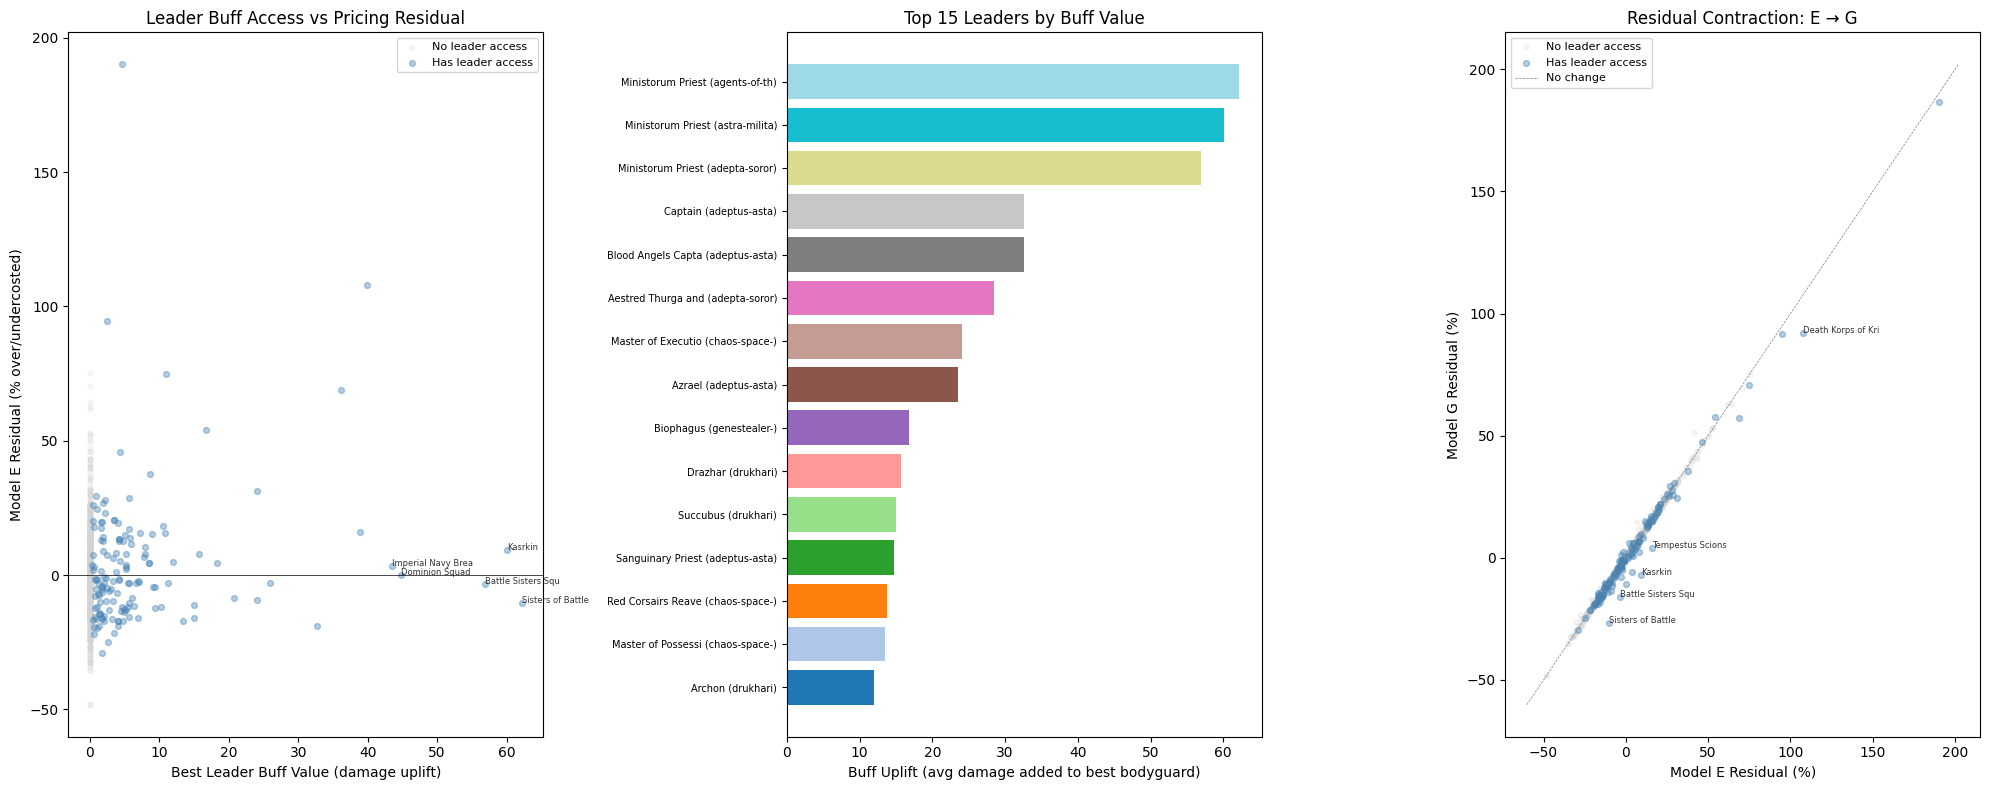

Saved leader_buff_attribution.png


In [29]:
# --- Leader Buff Attribution Visualizations ---

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1. Scatter: leader buff value vs Model E residual
ax = axes[0]
has_buff = df['best_leader_buff_value'] > 0
ax.scatter(df.loc[~has_buff, 'best_leader_buff_value'],
           df.loc[~has_buff, 'residual_pct'],
           alpha=0.2, s=12, c='lightgray', label='No leader access')
ax.scatter(df.loc[has_buff, 'best_leader_buff_value'],
           df.loc[has_buff, 'residual_pct'],
           alpha=0.4, s=18, c='steelblue', label='Has leader access')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Best Leader Buff Value (damage uplift)')
ax.set_ylabel('Model E Residual (% over/undercosted)')
ax.set_title('Leader Buff Access vs Pricing Residual')
ax.legend(fontsize=8)
# Annotate outliers
for _, row in df[has_buff].nlargest(5, 'best_leader_buff_value').iterrows():
    ax.annotate(row['unit_name'][:18],
                (row['best_leader_buff_value'], row['residual_pct']),
                fontsize=6, alpha=0.8)

# 2. Bar: top 15 leaders by buff uplift
ax = axes[1]
top15 = leader_best_bg.head(15).iloc[::-1]  # reverse for horizontal bars
labels = [f'{r["leader_name"][:18]} ({r["faction"][:12]})' for _, r in top15.iterrows()]
colors = plt.cm.tab20(np.linspace(0, 1, 15))
ax.barh(range(len(top15)), top15['buff_uplift'].values, color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Buff Uplift (avg damage added to best bodyguard)')
ax.set_title('Top 15 Leaders by Buff Value')

# 3. Scatter: Model E residual vs Model G residual (contraction toward zero)
ax = axes[2]
ax.scatter(df.loc[~has_buff, 'residual_pct'],
           df.loc[~has_buff, 'residual_pct_G'],
           alpha=0.2, s=12, c='lightgray', label='No leader access')
ax.scatter(df.loc[has_buff, 'residual_pct'],
           df.loc[has_buff, 'residual_pct_G'],
           alpha=0.4, s=18, c='steelblue', label='Has leader access')
# Identity line (no change)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', linewidth=0.5, label='No change')
ax.set_xlabel('Model E Residual (%)')
ax.set_ylabel('Model G Residual (%)')
ax.set_title('Residual Contraction: E → G')
ax.legend(fontsize=8)
# Annotate biggest movers
for _, row in big_movers.head(5).iterrows():
    ax.annotate(row['unit_name'][:18],
                (row['residual_pct'], row['residual_pct_G']),
                fontsize=6, alpha=0.8)

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'leader_buff_attribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved leader_buff_attribution.png')

## Deep Dive: Ability Mechanics and Unit Pricing

With structured DSL data covering every damage-relevant ability in the game,
we can now decompose exactly how GW prices individual mechanics — rerolls,
keyword grants, stat modifiers, and their interactions.

In [30]:
# === REROLL PRICING ===
# How much does each type of reroll add to a unit's cost?
# Compare: reroll-all-hits vs reroll-1s-hits vs reroll-wounds vs reroll-damage

# Extract reroll features from DSL data for each unit
reroll_features = []
for u in all_units:
    faction = u['_faction']
    uid = u['id']
    points = u.get('points', [])
    if not points: continue
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    n_models = min_pts.get('models', 1)
    if cost <= 0 or n_models <= 0: continue
    
    # Get DSL buffs
    b = dsl_to_buffs(faction, uid, 'shooting')
    b_melee = dsl_to_buffs(faction, uid, 'fight')
    
    reroll_features.append({
        'unit_name': u.get('name', ''),
        'faction': faction,
        'ppm': cost / n_models,
        'rr_hits_all': b.reroll_hits == 'all' or b_melee.reroll_hits == 'all',
        'rr_hits_1s': b.reroll_hits == '1s' or b_melee.reroll_hits == '1s',
        'rr_wounds_all': b.reroll_wounds == 'all' or b_melee.reroll_wounds == 'all',
        'rr_wounds_1s': b.reroll_wounds == '1s' or b_melee.reroll_wounds == '1s',
        'rr_damage': b.reroll_damage or b_melee.reroll_damage,
        'grant_lethal': b.grant_lethal_hits or b_melee.grant_lethal_hits,
        'grant_sustained': max(b.grant_sustained_hits, b_melee.grant_sustained_hits),
        'grant_dw': b.grant_devastating_wounds or b_melee.grant_devastating_wounds,
        'extra_attacks': max(b.extra_attacks, b_melee.extra_attacks),
        'extra_strength': max(b.extra_strength, b_melee.extra_strength),
        'extra_ap': max(b.extra_ap, b_melee.extra_ap),
        'hit_mod': max(b.hit_mod, b_melee.hit_mod),
        'wound_mod': max(b.wound_mod, b_melee.wound_mod),
    })

rr_df = pd.DataFrame(reroll_features)

# Merge with regression residuals from Model C
rr_df = rr_df.merge(
    df[['unit_name', 'faction', 'ppm', 'log_ppm', 'predicted_ppm', 'residual_pct',
        'T', 'W', 'save_quality']].rename(columns={'ppm': 'ppm_reg'}),
    on=['unit_name', 'faction'], how='inner'
)

print("=== REROLL VALUE ANALYSIS ===")
print(f"Units with reroll all hits:    {rr_df['rr_hits_all'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_hits_all']]['ppm'].median():>6.0f}  "
      f"vs no-reroll: {rr_df[~rr_df['rr_hits_all'] & ~rr_df['rr_hits_1s']]['ppm'].median():>6.0f}")
print(f"Units with reroll 1s hits:     {rr_df['rr_hits_1s'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_hits_1s']]['ppm'].median():>6.0f}")
print(f"Units with reroll all wounds:  {rr_df['rr_wounds_all'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_wounds_all']]['ppm'].median():>6.0f}")
print(f"Units with reroll 1s wounds:   {rr_df['rr_wounds_1s'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_wounds_1s']]['ppm'].median():>6.0f}")
print(f"Units with reroll damage:      {rr_df['rr_damage'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_damage']]['ppm'].median():>6.0f}")

# Mean residual by reroll type (controlling for stats via Model E residual)
print("\n=== REROLL PREMIUM (Model E residual — what GW charges ABOVE stat prediction) ===")
mechanics = [
    ('Reroll ALL hits', 'rr_hits_all'),
    ('Reroll 1s hits', 'rr_hits_1s'),
    ('Reroll ALL wounds', 'rr_wounds_all'),
    ('Reroll 1s wounds', 'rr_wounds_1s'),
    ('Reroll damage', 'rr_damage'),
    ('Lethal Hits (ability)', 'grant_lethal'),
    ('Devastating Wounds (ability)', 'grant_dw'),
    ('+1 to hit', lambda df: df['hit_mod'] >= 1),
    ('+1 to wound', lambda df: df['wound_mod'] >= 1),
    ('Extra attacks (any)', lambda df: df['extra_attacks'] > 0),
    ('Extra AP', lambda df: df['extra_ap'] > 0),
    ('Extra strength', lambda df: df['extra_strength'] > 0),
    ('Sustained Hits (ability)', lambda df: df['grant_sustained'] > 0),
]

print(f"{'Mechanic':<30s} {'Count':>6s} {'Mean Residual%':>15s} {'Median PPM':>11s} {'vs Baseline':>12s}")
print("-" * 80)
baseline_ppm = rr_df['ppm'].median()
for name, col in mechanics:
    if callable(col):
        mask = col(rr_df)
    else:
        mask = rr_df[col]
    count = mask.sum()
    if count < 3:
        continue
    mean_resid = rr_df.loc[mask, 'residual_pct'].mean()
    med_ppm = rr_df.loc[mask, 'ppm'].median()
    print(f"{name:<30s} {count:>6d} {mean_resid:>+14.1f}% {med_ppm:>11.0f} {med_ppm/baseline_ppm:>11.1f}x")


=== REROLL VALUE ANALYSIS ===
Units with reroll all hits:     279  median PPM:     75  vs no-reroll:     75
Units with reroll 1s hits:       60  median PPM:     65
Units with reroll all wounds:   276  median PPM:     75
Units with reroll 1s wounds:     26  median PPM:     21
Units with reroll damage:        16  median PPM:    140

=== REROLL PREMIUM (Model E residual — what GW charges ABOVE stat prediction) ===
Mechanic                        Count  Mean Residual%  Median PPM  vs Baseline
--------------------------------------------------------------------------------
Reroll ALL hits                   279           +2.4%          75         1.0x
Reroll 1s hits                     60           -1.2%          65         0.9x
Reroll ALL wounds                 276           +2.6%          75         1.0x
Reroll 1s wounds                   26           +0.1%          21         0.3x
Reroll damage                      16           +4.9%         140         1.9x
Lethal Hits (ability)         

In [31]:
# === WEAPON KEYWORD PRICING ===
# How much does each weapon keyword add to unit cost?
# Use Model E residuals to control for stats — the residual shows what GW charges
# above/below the prediction from stats+abilities.

keyword_features = [
    ('Torrent', 'has_torrent'),
    ('Blast', 'has_blast'),
    ('Lethal Hits (weapon)', 'has_lethal_hits'),
    ('Sustained Hits (weapon)', 'has_sustained_hits'),
    ('Devastating Wounds (weapon)', 'has_devastating_wounds'),
    ('Twin-linked', 'has_twin_linked'),
    ('Melta', 'has_melta'),
    ('Lance', 'has_lance'),
    ('Heavy', 'has_heavy'),
    ('Indirect Fire', 'has_indirect_fire'),
    ('Precision', 'has_precision'),
    ('Anti-Infantry', 'has_anti_infantry'),
    ('Anti-Vehicle', 'has_anti_vehicle'),
    ('Anti-Monster', 'has_anti_monster'),
]

print("=== WEAPON KEYWORD PRICING (from Model E coefficients) ===")
print(f"{'Keyword':<30s} {'Coef (log)':>10s} {'% Cost':>10s} {'p-value':>10s} {'Sig':>5s} {'Units with':>10s}")
print("-" * 80)

for name, col in keyword_features:
    if col in model_E.params.index:
        coef = model_E.params[col]
        pct = (np.exp(coef) - 1) * 100
        pval = model_E.pvalues[col]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        count = int(df[col].sum()) if col in df.columns else 0
        print(f"{name:<30s} {coef:>+10.4f} {pct:>+9.1f}% {pval:>10.3f} {sig:>5s} {count:>10d}")

# Interaction analysis: which keyword COMBINATIONS are most valuable?
print("\n=== KEYWORD COMBINATIONS (top 10 by frequency) ===")
kw_cols = [col for _, col in keyword_features if col in df.columns]
combo_counts = df[kw_cols].apply(lambda row: tuple(c for c in kw_cols if row[c]), axis=1)
combo_freq = combo_counts.value_counts().head(15)
print(f"{'Combination':<60s} {'Count':>6s} {'Median PPM':>10s}")
print("-" * 80)
for combo, count in combo_freq.items():
    if not combo or count < 5:
        continue
    mask = pd.Series(True, index=df.index)
    for c in combo:
        mask &= df[c] == 1
    combo_name = ' + '.join(c.replace('has_', '').replace('_', ' ').title() for c in combo)
    if len(combo_name) > 58:
        combo_name = combo_name[:55] + '...'
    med = df.loc[mask, 'ppm'].median()
    print(f"{combo_name:<60s} {count:>6d} {med:>10.0f}")


=== WEAPON KEYWORD PRICING (from Model E coefficients) ===
Keyword                        Coef (log)     % Cost    p-value   Sig Units with
--------------------------------------------------------------------------------
Torrent                           +0.0177      +1.8%      0.328              269
Blast                             +0.0123      +1.2%      0.555              297
Lethal Hits (weapon)              -0.0187      -1.9%      0.363              149
Sustained Hits (weapon)           +0.0289      +2.9%      0.099              296
Devastating Wounds (weapon)       +0.0152      +1.5%      0.363              308
Twin-linked                       -0.0041      -0.4%      0.827              243
Melta                             +0.0254      +2.6%      0.278              142
Lance                             -0.0138      -1.4%      0.692               34
Heavy                             +0.0226      +2.3%      0.357              148
Indirect Fire                     +0.0262      +2.

=== COUNTERFACTUAL DAMAGE UPLIFT BY TARGET (median % improvement from buff) ===
Mechanic                         vs Horde   vs Elite vs Vehicle   vs C'tan
---------------------------------------------------------------------------
Reroll ALL hits                      +17%       +17%       +17%       +17%
Reroll 1s hits                       +17%       +17%       +17%       +17%
Reroll ALL wounds                    +13%       +25%       +36%       +41%
Reroll 1s wounds                     +17%       +17%       +17%       +17%
Reroll damage                         +0%        +0%       +10%       +12%
Lethal Hits (ability)                 +3%        +4%       +17%       +21%
Devastating Wounds (ability)          +4%       +57%       +32%       +36%
+1 to hit                            +25%       +25%       +20%       +20%
+1 to wound                           +6%       +15%       +29%       +37%
Extra attacks (any)                  +35%       +50%       +55%       +54%
Extra AP           

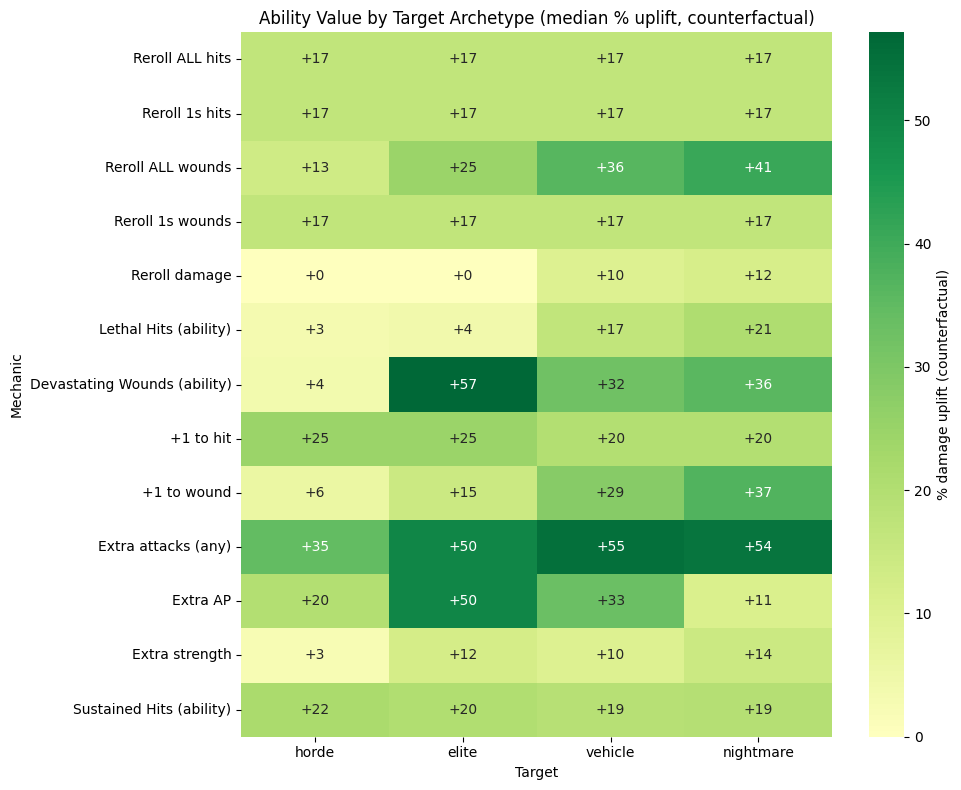

Saved buff_heatmap.png


In [32]:
# === ABILITY VALUE BY TARGET ARCHETYPE (Counterfactual Analysis) ===
# For each buff, compute the median % damage improvement it provides by comparing
# each unit's damage WITH the buff vs WITHOUT it (holding everything else constant).
# This isolates the buff's mechanical contribution from the unit's baseline profile.

from dataclasses import replace as dc_replace

def build_full_buffs(faction, unit_id, phase):
    """Build the full buff stack for a unit (same pipeline as compute_unit_damage_features)."""
    buffs = dsl_to_buffs(faction, unit_id, phase)
    det_name, det_descs = get_best_detachment_buffs(faction)
    strat_name, strat_desc = get_best_stratagem_buff(faction, det_name, phase.capitalize())
    text_descs = det_descs + ([strat_desc] if strat_desc else [])
    text_buffs = text_to_buffs_object(text_descs)

    # Merge: DSL buffs take precedence, text buffs fill gaps
    if text_buffs.reroll_hits == 'all' and buffs.reroll_hits != 'all':
        buffs.reroll_hits = 'all'
    elif text_buffs.reroll_hits == '1s' and buffs.reroll_hits == 'none':
        buffs.reroll_hits = '1s'
    if text_buffs.reroll_wounds == 'all' and buffs.reroll_wounds != 'all':
        buffs.reroll_wounds = 'all'
    elif text_buffs.reroll_wounds == '1s' and buffs.reroll_wounds == 'none':
        buffs.reroll_wounds = '1s'
    buffs.hit_mod = max(buffs.hit_mod, text_buffs.hit_mod)
    buffs.wound_mod = max(buffs.wound_mod, text_buffs.wound_mod)
    buffs.extra_ap = max(buffs.extra_ap, text_buffs.extra_ap)
    buffs.extra_strength = max(buffs.extra_strength, text_buffs.extra_strength)
    buffs.grant_lethal_hits = buffs.grant_lethal_hits or text_buffs.grant_lethal_hits
    buffs.grant_sustained_hits = max(buffs.grant_sustained_hits, text_buffs.grant_sustained_hits)
    buffs.grant_devastating_wounds = buffs.grant_devastating_wounds or text_buffs.grant_devastating_wounds
    return buffs

# Map: (display_name, rr_df_column_or_fn, buffs_field_to_zero, zero_value)
MECHANIC_OVERRIDES = [
    ('Reroll ALL hits',              'rr_hits_all',   'reroll_hits',              'none'),
    ('Reroll 1s hits',               'rr_hits_1s',    'reroll_hits',              'none'),
    ('Reroll ALL wounds',            'rr_wounds_all', 'reroll_wounds',            'none'),
    ('Reroll 1s wounds',             'rr_wounds_1s',  'reroll_wounds',            'none'),
    ('Reroll damage',                'rr_damage',     'reroll_damage',            False),
    ('Lethal Hits (ability)',        'grant_lethal',  'grant_lethal_hits',        False),
    ('Devastating Wounds (ability)', 'grant_dw',      'grant_devastating_wounds', False),
    ('+1 to hit',                    lambda df: df['hit_mod'] >= 1, 'hit_mod',    0),
    ('+1 to wound',                  lambda df: df['wound_mod'] >= 1, 'wound_mod', 0),
    ('Extra attacks (any)',          lambda df: df['extra_attacks'] > 0, 'extra_attacks', 0),
    ('Extra AP',                     lambda df: df['extra_ap'] > 0, 'extra_ap',  0),
    ('Extra strength',               lambda df: df['extra_strength'] > 0, 'extra_strength', 0),
    ('Sustained Hits (ability)',     lambda df: df['grant_sustained'] > 0, 'grant_sustained_hits', 0),
]

# Look up unit dicts by (name, faction) so we can recompute damage
name_faction_to_unit = {}
for u in all_units:
    name_faction_to_unit[(u.get('name', ''), u['_faction'])] = u

buff_impact = []
for mech_name, col_or_fn, buff_field, zero_val in MECHANIC_OVERRIDES:
    if callable(col_or_fn):
        mask = col_or_fn(rr_df)
    else:
        mask = rr_df[col_or_fn]

    count = mask.sum()
    if count < 5:
        continue

    # For each unit with this buff, compute counterfactual uplift per target
    uplifts = {arch: [] for arch in ARCHETYPE_TARGETS}

    for _, r in rr_df[mask].iterrows():
        unit = name_faction_to_unit.get((r['unit_name'], r['faction']))
        if unit is None:
            continue

        faction = unit['_faction']
        uid = unit['id']
        points = unit.get('points', [])
        if not points:
            continue
        min_pts = min(points, key=lambda p: p.get('models', 999))
        cost = min_pts.get('cost', 0)
        if cost <= 0:
            continue

        for arch_name, target in ARCHETYPE_TARGETS.items():
            # Compute per-phase uplift, take the best phase where the buff helps
            best_uplift = 0.0
            for phase in ['shooting', 'fight']:
                full_buffs = build_full_buffs(faction, uid, phase)
                zeroed_buffs = dc_replace(full_buffs, **{buff_field: zero_val})

                dmg_with = compute_unit_total_damage(unit, faction, target, full_buffs, phase)
                dmg_without = compute_unit_total_damage(unit, faction, target, zeroed_buffs, phase)

                if dmg_without > 0.01:
                    phase_uplift = (dmg_with / dmg_without - 1) * 100
                elif dmg_with > 0:
                    phase_uplift = 100.0
                else:
                    phase_uplift = 0.0
                best_uplift = max(best_uplift, phase_uplift)

            uplifts[arch_name].append(best_uplift)

    row = {'Mechanic': mech_name, 'Count': int(count)}
    for arch_name in ARCHETYPE_TARGETS:
        if uplifts[arch_name]:
            row[arch_name] = np.median(uplifts[arch_name])
    buff_impact.append(row)

impact_df = pd.DataFrame(buff_impact)
print("=== COUNTERFACTUAL DAMAGE UPLIFT BY TARGET (median % improvement from buff) ===")
ctan = "vs C'tan"
print(f"{'Mechanic':<30s} {'vs Horde':>10s} {'vs Elite':>10s} {'vs Vehicle':>10s} {ctan:>10s}")
print("-" * 75)
for _, row in impact_df.iterrows():
    print(f"{row['Mechanic']:<30s} "
          f"{row.get('horde', 0):>+9.0f}% "
          f"{row.get('elite', 0):>+9.0f}% "
          f"{row.get('vehicle', 0):>+9.0f}% "
          f"{row.get('nightmare', 0):>+9.0f}%")

# Visualization: heatmap of buff value by target
if len(impact_df) > 3:
    fig, ax = plt.subplots(figsize=(10, 8))
    target_cols = ['horde', 'elite', 'vehicle', 'nightmare']
    existing_cols = [c for c in target_cols if c in impact_df.columns]
    heatmap_data = impact_df.set_index('Mechanic')[existing_cols]
    sns.heatmap(heatmap_data, annot=True, fmt='+.0f', cmap='RdYlGn', center=0,
                ax=ax, cbar_kws={'label': '% damage uplift (counterfactual)'})
    ax.set_title('Ability Value by Target Archetype (median % uplift, counterfactual)')
    ax.set_xlabel('Target')
    ax.set_ylabel('Mechanic')
    plt.tight_layout()
    plt.savefig(REPO / 'scripts' / 'buff_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved buff_heatmap.png")


Mechanic                         Cost %   Uplift %   Efficiency
-----------------------------------------------------------------
Extra attacks (any)               +3.6%     +48.4%       13.4x
Devastating Wounds (ability)      -1.5%     +32.3%       free!
Reroll ALL wounds                 -6.7%     +28.9%       free!
Extra AP                          -0.4%     +28.6%       free!
+1 to hit                         -1.8%     +22.5%       free!
+1 to wound                       -1.3%     +21.7%       free!
Sustained Hits (ability)          +5.0%     +20.1%        4.1x
Reroll 1s hits                    +2.1%     +16.7%        8.0x
Reroll ALL hits                   +3.4%     +16.7%        4.8x
Reroll 1s wounds                  -0.5%     +16.7%       free!
Lethal Hits (ability)             -1.3%     +11.3%       free!
Extra strength                    -2.9%      +9.9%       free!
Reroll damage                     -6.0%      +5.5%       free!


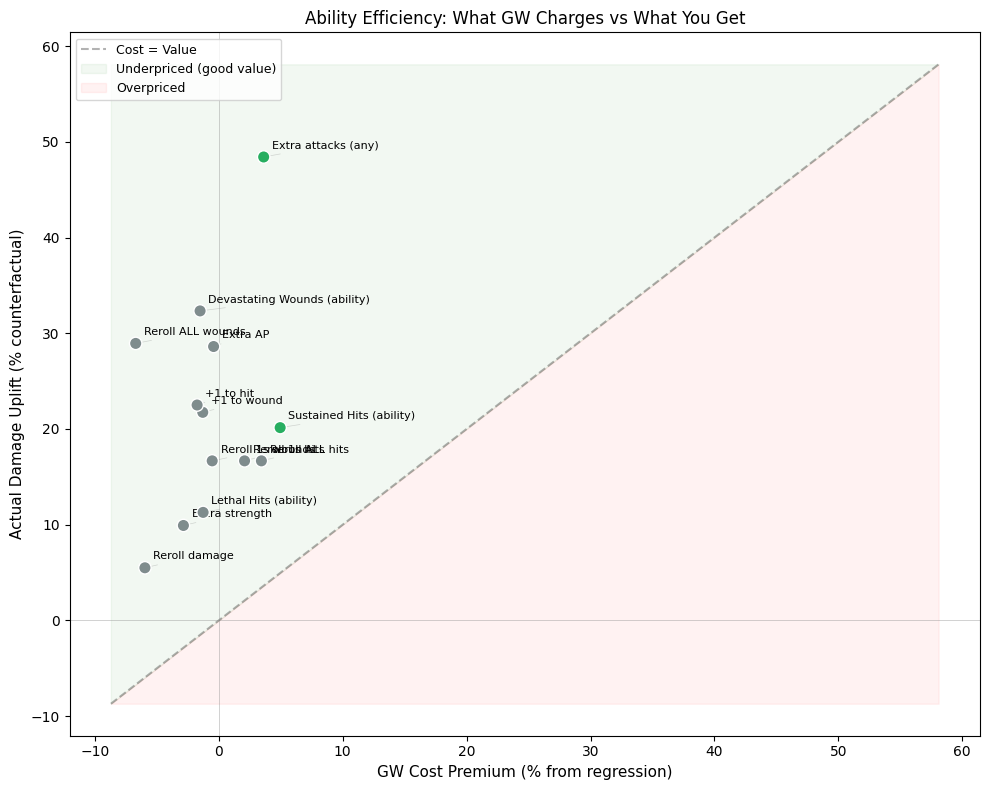

Saved cost_vs_uplift.png


In [33]:
# === ABILITY COST vs DAMAGE VALUE ===
# Scatter: regression cost (what GW charges) vs counterfactual damage uplift (what you get)
# Abilities above the diagonal are bargains; below are overpriced.

# Map regression feature names to heatmap mechanic names
REGRESSION_TO_MECHANIC = {
    'has_reroll_hits_all': 'Reroll ALL hits',
    'has_reroll_hits_1s': 'Reroll 1s hits',
    'has_reroll_wounds_all': 'Reroll ALL wounds',
    'has_reroll_wounds_1s': 'Reroll 1s wounds',
    'has_reroll_damage': 'Reroll damage',
    'has_grant_lethal_hits': 'Lethal Hits (ability)',
    'has_grant_devastating_wounds': 'Devastating Wounds (ability)',
    'has_plus_to_hit': '+1 to hit',
    'has_plus_to_wound': '+1 to wound',
    'has_extra_attacks': 'Extra attacks (any)',
    'has_extra_ap': 'Extra AP',
    'has_extra_strength': 'Extra strength',
    'has_grant_sustained_hits': 'Sustained Hits (ability)',
}

# Average counterfactual uplift across targets for each mechanic
target_cols = ['horde', 'elite', 'vehicle', 'nightmare']
uplift_by_mechanic = {}
for _, row in impact_df.iterrows():
    vals = [row[c] for c in target_cols if c in row and pd.notna(row[c])]
    if vals:
        uplift_by_mechanic[row['Mechanic']] = np.mean(vals)

# Build scatter data: match regression coefficients to counterfactual uplift
scatter_data = []
for _, row in coef_df.iterrows():
    feat = row['feature']
    if feat in REGRESSION_TO_MECHANIC:
        mech = REGRESSION_TO_MECHANIC[feat]
        if mech in uplift_by_mechanic:
            scatter_data.append({
                'label': mech,
                'cost_pct': row['pct_impact'],
                'uplift_pct': uplift_by_mechanic[mech],
                'significant': row['significant'],
            })

sdf = pd.DataFrame(scatter_data)
print(f"{'Mechanic':<30s} {'Cost %':>8s} {'Uplift %':>10s} {'Efficiency':>12s}")
print('-' * 65)
for _, r in sdf.sort_values('uplift_pct', ascending=False).iterrows():
    if r['cost_pct'] <= 0 and r['uplift_pct'] > 0:
        eff_str = '     free!'
    elif r['cost_pct'] > 0:
        eff_str = f"{r['uplift_pct'] / r['cost_pct']:>9.1f}x"
    else:
        eff_str = '       n/a'
    print(f"{r['label']:<30s} {r['cost_pct']:>+7.1f}% {r['uplift_pct']:>+9.1f}%  {eff_str}")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Diagonal: cost = value
lim_max = max(sdf['cost_pct'].max(), sdf['uplift_pct'].max()) * 1.2
lim_min = min(sdf['cost_pct'].min(), 0) - 2
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.3, label='Cost = Value')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

# Fill regions
ax.fill_between([lim_min, lim_max], [lim_min, lim_max], lim_max,
                alpha=0.05, color='green', label='Underpriced (good value)')
ax.fill_between([lim_min, lim_max], lim_min, [lim_min, lim_max],
                alpha=0.05, color='red', label='Overpriced')

# Plot points
colors = ['#27ae60' if row['significant'] else '#7f8c8d' for _, row in sdf.iterrows()]
ax.scatter(sdf['cost_pct'], sdf['uplift_pct'], c=colors, s=80, zorder=5, edgecolors='white')

# Labels
for _, r in sdf.iterrows():
    ax.annotate(r['label'], (r['cost_pct'], r['uplift_pct']),
                textcoords='offset points', xytext=(6, 6), fontsize=8,
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.3, lw=0.5))

ax.set_xlabel('GW Cost Premium (% from regression)', fontsize=11)
ax.set_ylabel('Actual Damage Uplift (% counterfactual)', fontsize=11)
ax.set_title('Ability Efficiency: What GW Charges vs What You Get')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'cost_vs_uplift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved cost_vs_uplift.png')


In [34]:
# === INTERACTION EFFECTS: Which ability combos are worth more than the sum of parts? ===
# Some buffs synergize (reroll hits + Lethal Hits), others are redundant.
# Check if GW prices combos differently than individual abilities.

print("=== ABILITY SYNERGY ANALYSIS ===")
print("Do buff combinations cost more than individual buffs sum would predict?\n")

# Define interesting combos to test
combos = [
    ('Reroll hits + Reroll wounds', lambda df: df['rr_hits_all'] & df['rr_wounds_all']),
    ('Reroll hits + Lethal Hits', lambda df: df['rr_hits_all'] & df['grant_lethal']),
    ('Reroll hits + Sustained Hits', lambda df: df['rr_hits_all'] & (df['grant_sustained'] > 0)),
    ('Lethal + Sustained', lambda df: df['grant_lethal'] & (df['grant_sustained'] > 0)),
    ('+Attacks + +Strength', lambda df: (df['extra_attacks'] > 0) & (df['extra_strength'] > 0)),
    ('Reroll wounds + +wound mod', lambda df: df['rr_wounds_all'] & (df['wound_mod'] >= 1)),
    ('Reroll hits + +hit mod', lambda df: df['rr_hits_all'] & (df['hit_mod'] >= 1)),
]

print(f"{'Combo':<40s} {'Count':>6s} {'Median PPM':>10s} {'Mean Resid%':>12s} {'Verdict':>15s}")
print("-" * 90)

# Baseline
baseline_resid = rr_df['residual_pct'].median()

for name, mask_fn in combos:
    mask = mask_fn(rr_df)
    count = mask.sum()
    if count < 2:
        print(f"{name:<40s} {count:>6d}    (too few)")
        continue
    med_ppm = rr_df.loc[mask, 'ppm'].median()
    mean_resid = rr_df.loc[mask, 'residual_pct'].mean()
    verdict = "PREMIUM" if mean_resid > 10 else "DISCOUNT" if mean_resid < -10 else "FAIR"
    print(f"{name:<40s} {count:>6d} {med_ppm:>10.0f} {mean_resid:>+11.1f}% {verdict:>15s}")

print(f"\nBaseline (all units): median residual = {baseline_resid:+.1f}%")


=== ABILITY SYNERGY ANALYSIS ===
Do buff combinations cost more than individual buffs sum would predict?

Combo                                     Count Median PPM  Mean Resid%         Verdict
------------------------------------------------------------------------------------------
Reroll hits + Reroll wounds                 250         75        +2.8%            FAIR
Reroll hits + Lethal Hits                    14         68        +0.8%            FAIR
Reroll hits + Sustained Hits                 16         75        -2.5%            FAIR
Lethal + Sustained                           29        105        +0.1%            FAIR
+Attacks + +Strength                         57         70        +1.4%            FAIR
Reroll wounds + +wound mod                  239         75        +2.7%            FAIR
Reroll hits + +hit mod                       40         95        +3.6%            FAIR

Baseline (all units): median residual = +0.1%


=== FACTION RULE VALUE DECOMPOSITION ===
How much damage does each faction's army rule add per 100pts?

Faction                    With Rule    Without     Uplift
----------------------------------------------------------
adeptus-astartes                89.2       52.1       +71%
world-eaters                    42.6       30.7       +39%
orks                            65.4       47.1       +39%
thousand-sons                   43.6       35.0       +24%
death-guard                     38.8       32.0       +21%
leagues-of-votann               62.7       52.2       +20%
tau-empire                      34.7       29.1       +19%
astra-militarum                 77.2       66.0       +17%
adeptus-mechanicus              39.1       33.4       +17%
chaos-space-marines             69.7       60.1       +16%
adepta-sororitas                77.0       67.8       +14%
adeptus-custodes                20.3       18.2       +12%
imperial-knights                31.2       28.4       +10%
tyranids   

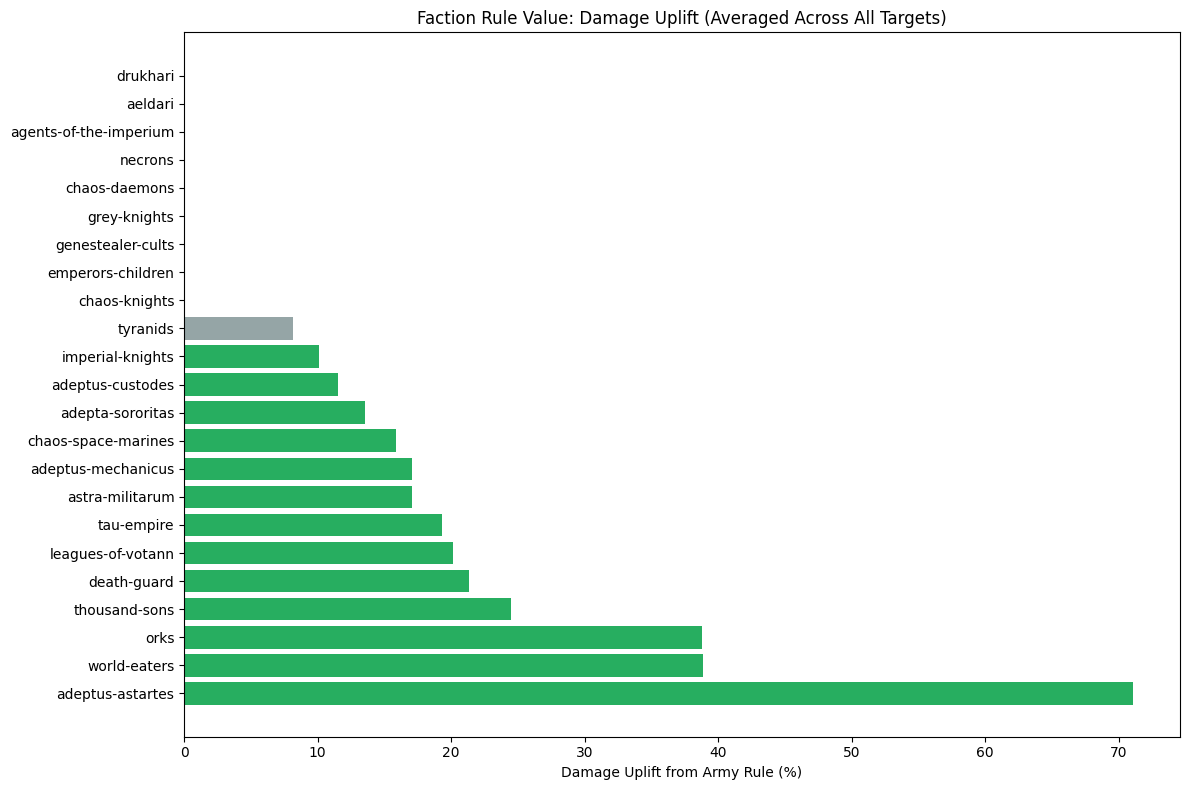

Saved faction_rule_value.png


In [35]:
# === FACTION RULE VALUE ===
# How much of each faction's pricing premium comes from its army rule?
# Compare: damage with army rule ON vs OFF, averaged across all 4 archetype targets

print("=== FACTION RULE VALUE DECOMPOSITION ===")
print("How much damage does each faction's army rule add per 100pts?\n")

# For each faction, compute average damage with and without the faction rule
faction_rule_impact = []

for faction in sorted(factions_list):
    if faction == '_example':
        continue
    
    faction_units = [u for u in all_units if u['_faction'] == faction]
    if len(faction_units) < 5:
        continue
    
    dmg_with_rule = []
    dmg_without_rule = []
    
    for u in faction_units[:30]:  # Sample to keep it fast
        points = u.get('points', [])
        if not points: continue
        min_pts = min(points, key=lambda p: p.get('models', 999))
        cost = min_pts.get('cost', 0)
        if cost <= 0: continue
        
        # Average across all 4 archetype targets
        unit_dmg_with = []
        unit_dmg_without = []
        for arch_name, target in ARCHETYPE_TARGETS.items():
            for phase in ['shooting', 'fight']:
                # With faction rule (full DSL buffs)
                buffs_with = dsl_to_buffs(faction, u['id'], phase)
                dmg_w = compute_unit_total_damage(u, faction, target, buffs_with, phase)
                
                # Without faction rule (only unit abilities)
                buffs_without = Buffs(assume_stationary=(phase == 'shooting'),
                                      assume_charged=(phase == 'fight'),
                                      assume_half_range=True)
                for ab in dsl_by_unit.get((faction, u['id']), []):
                    walk_effect_to_buffs(ab.get('effect'), buffs_without)
                dmg_wo = compute_unit_total_damage(u, faction, target, buffs_without, phase)
                
                unit_dmg_with.append(dmg_w)
                unit_dmg_without.append(dmg_wo)
        
        total_with = sum(unit_dmg_with)
        total_without = sum(unit_dmg_without)
        if total_without > 0:
            dmg_with_rule.append(total_with / cost * 100)
            dmg_without_rule.append(total_without / cost * 100)
    
    if len(dmg_with_rule) >= 3:
        avg_with = np.mean(dmg_with_rule)
        avg_without = np.mean(dmg_without_rule)
        uplift = (avg_with / max(avg_without, 0.01) - 1) * 100
        faction_rule_impact.append({
            'faction': faction,
            'dmg_with_rule': avg_with,
            'dmg_without_rule': avg_without,
            'uplift_pct': uplift,
        })

fri = pd.DataFrame(faction_rule_impact).sort_values('uplift_pct', ascending=False)
print(f"{'Faction':<25s} {'With Rule':>10s} {'Without':>10s} {'Uplift':>10s}")
print("-" * 58)
for _, row in fri.iterrows():
    print(f"{row['faction']:<25s} {row['dmg_with_rule']:>10.1f} {row['dmg_without_rule']:>10.1f} {row['uplift_pct']:>+9.0f}%")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#27ae60' if v > 10 else '#e74c3c' if v < -5 else '#95a5a6' for v in fri['uplift_pct']]
ax.barh(fri['faction'], fri['uplift_pct'], color=colors)
ax.set_xlabel('Damage Uplift from Army Rule (%)')
ax.set_title('Faction Rule Value: Damage Uplift (Averaged Across All Targets)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'faction_rule_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved faction_rule_value.png")


=== FACTION RULE: DAMAGE VALUE vs POINTS PREMIUM ===



Faction                    Dmg Uplift  Pts Premium  Efficiency    n
--------------------------------------------------------------------
adeptus-astartes               +48.3%        +2.7%      17.78x   30
orks                           +33.8%        +0.8%      42.26x   30
world-eaters                   +26.2%        +1.2%      21.25x   25
death-guard                    +24.3%        -0.4%     243.01x   30
leagues-of-votann              +14.5%        +0.3%      54.84x   22
astra-militarum                +13.6%        +0.0%     136.09x   28
thousand-sons                  +11.9%        -0.0%     119.45x   28
adepta-sororitas               +10.8%        +1.0%      11.28x   30
imperial-knights                +8.1%        +1.1%       7.27x   21
adeptus-custodes                +6.6%        +0.0%      65.85x   30
tyranids                        +5.3%        +0.2%      24.44x   29
chaos-knights                   +0.0%        +0.0%       0.00x   20
chaos-space-marines             +0.0%        +0

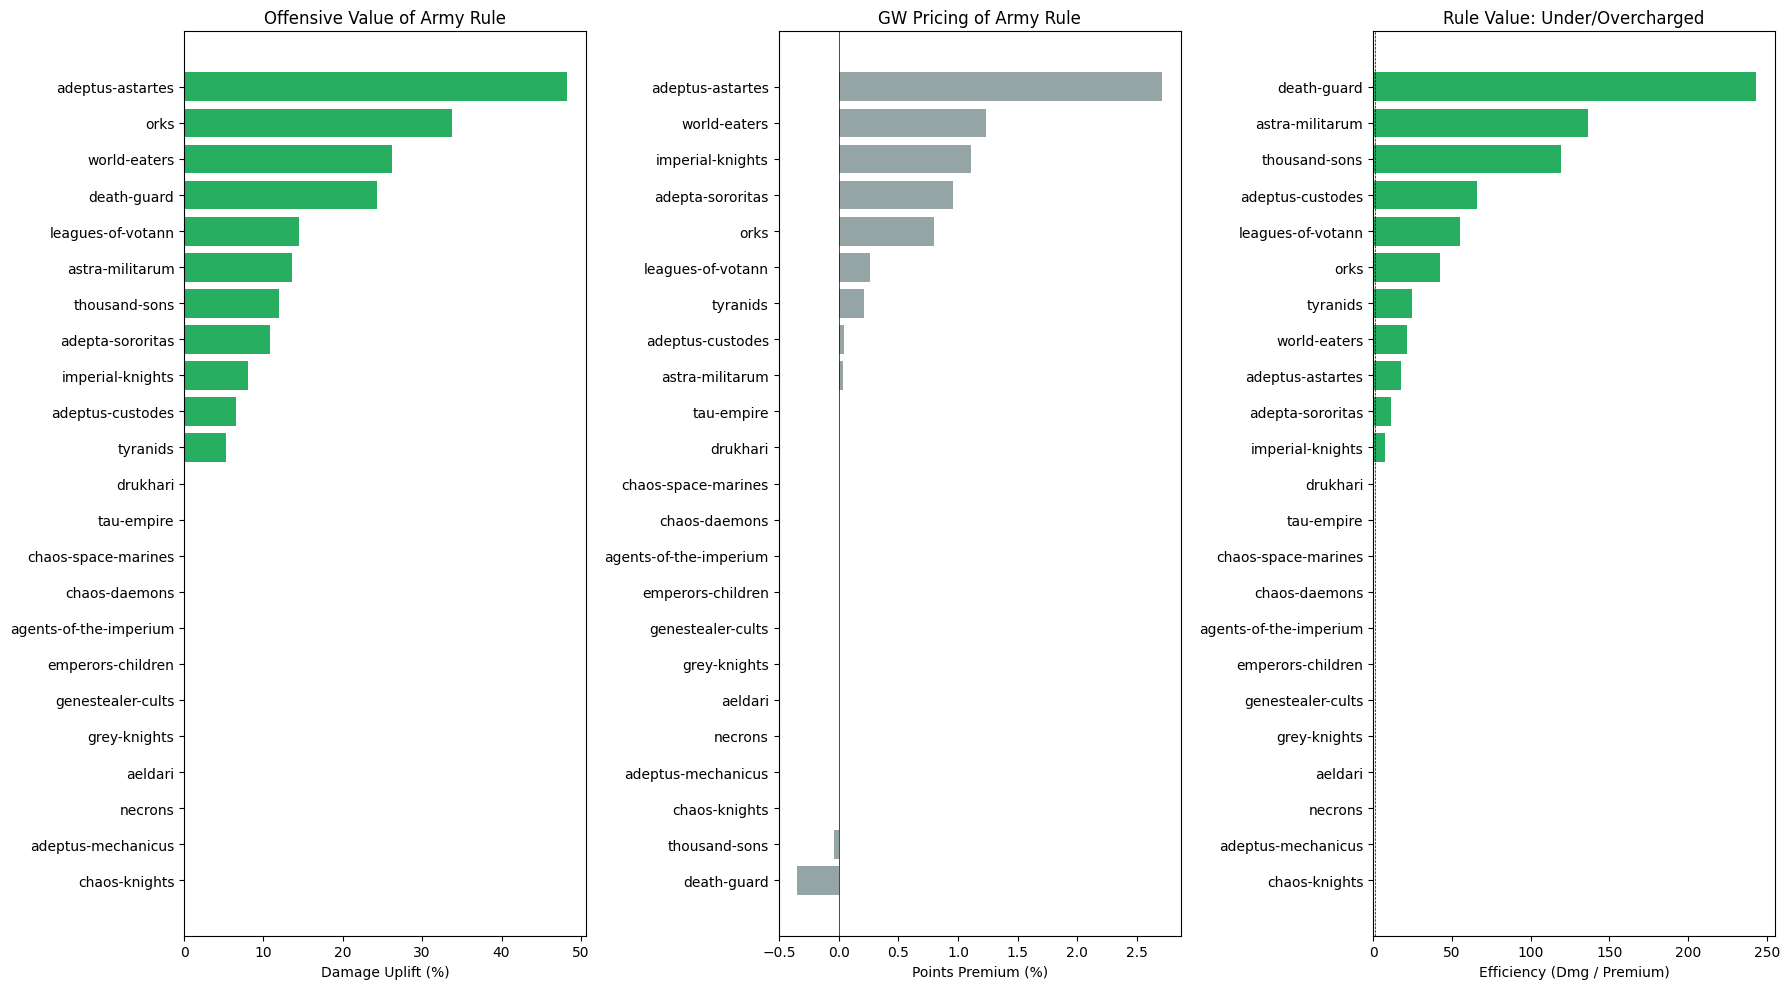

Saved faction_rule_pricing.png


In [36]:
# === FACTION RULE: PRICING & RANKING ===
# For each faction, compute two views of the army rule's value:
# 1. Damage uplift: how much more damage does the rule provide?
# 2. Points premium: how many points does the regression think GW charges for it?

print("=== FACTION RULE: DAMAGE VALUE vs POINTS PREMIUM ===\n")

damage_cols_to_modify = ['dmg_per_100_horde', 'dmg_per_100_elite',
                         'dmg_per_100_vehicle', 'dmg_per_100_nightmare', 'avg_dmg_per_100']


def dsl_to_buffs_no_faction_rule(faction, unit_id, phase='shooting'):
    """Like dsl_to_buffs but skips the faction rule — unit abilities only."""
    b = Buffs()
    b.assume_stationary = (phase == 'shooting')
    b.assume_charged = (phase == 'fight')
    b.assume_half_range = True
    for ab in dsl_by_unit.get((faction, unit_id), []):
        walk_effect_to_buffs(ab.get('effect'), b)
    return b


def compute_damage_features_custom(unit, faction, buffs_fn):
    """Recompute damage features using a custom buffs function."""
    points = unit.get('points', [])
    if not points:
        return {}
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    if cost <= 0:
        return {}

    feats = {}
    dmg_values = []

    for arch_name, target in ARCHETYPE_TARGETS.items():
        best_dmg = 0
        for phase in ['shooting', 'fight']:
            buffs = buffs_fn(faction, unit['id'], phase)
            # Also add detachment + stratagem text buffs (same as compute_unit_damage_features)
            det_name, det_descs = get_best_detachment_buffs(faction)
            strat_name, strat_desc = get_best_stratagem_buff(faction, det_name, phase.capitalize())
            text_descs = det_descs + ([strat_desc] if strat_desc else [])
            text_buffs = text_to_buffs_object(text_descs)
            # Merge
            if text_buffs.reroll_hits == 'all' and buffs.reroll_hits != 'all':
                buffs.reroll_hits = 'all'
            elif text_buffs.reroll_hits == '1s' and buffs.reroll_hits == 'none':
                buffs.reroll_hits = '1s'
            if text_buffs.reroll_wounds == 'all' and buffs.reroll_wounds != 'all':
                buffs.reroll_wounds = 'all'
            elif text_buffs.reroll_wounds == '1s' and buffs.reroll_wounds == 'none':
                buffs.reroll_wounds = '1s'
            buffs.hit_mod = max(buffs.hit_mod, text_buffs.hit_mod)
            buffs.wound_mod = max(buffs.wound_mod, text_buffs.wound_mod)
            buffs.extra_ap = max(buffs.extra_ap, text_buffs.extra_ap)
            buffs.extra_strength = max(buffs.extra_strength, text_buffs.extra_strength)
            buffs.grant_lethal_hits = buffs.grant_lethal_hits or text_buffs.grant_lethal_hits
            buffs.grant_sustained_hits = max(buffs.grant_sustained_hits, text_buffs.grant_sustained_hits)
            buffs.grant_devastating_wounds = buffs.grant_devastating_wounds or text_buffs.grant_devastating_wounds

            dmg = compute_unit_total_damage(unit, faction, target, buffs, phase)
            best_dmg = max(best_dmg, dmg)
        feats[f'dmg_per_100_{arch_name}'] = best_dmg / cost * 100
        dmg_values.append(best_dmg / cost * 100)

    feats['avg_dmg_per_100'] = np.mean(dmg_values)
    return feats


# For each faction, compute damage uplift AND regression-predicted points premium
results = []

for faction in sorted(factions_list):
    if faction == '_example':
        continue

    faction_df = df[df['faction'] == faction].copy()
    if len(faction_df) < 5:
        continue

    faction_units = [u for u in all_units if u['_faction'] == faction]
    unit_lookup = {u['id']: u for u in faction_units}

    dmg_uplifts = []
    pts_premiums = []

    for _, row in faction_df.head(30).iterrows():
        uid = row['unit_id']
        unit = unit_lookup.get(uid)
        if unit is None:
            continue

        # Damage without faction rule
        feats_without = compute_damage_features_custom(unit, faction, dsl_to_buffs_no_faction_rule)
        if not feats_without or 'avg_dmg_per_100' not in feats_without:
            continue

        # Damage uplift
        dmg_with = row['avg_dmg_per_100']
        dmg_without = feats_without['avg_dmg_per_100']
        if dmg_without > 0.01:
            dmg_uplifts.append((dmg_with / dmg_without - 1) * 100)

        # Points premium via regression
        # Create modified feature row with "without" damage values
        row_without = row.copy()
        for col in damage_cols_to_modify:
            row_without[col] = feats_without.get(col, 0)

        # Predict log_ppm for both
        X_with = sm.add_constant(pd.DataFrame([row[feats_E]]).astype(float))
        X_without = sm.add_constant(pd.DataFrame([row_without[feats_E]]).astype(float))

        # Align columns with model
        for c in model_E.params.index:
            if c not in X_with.columns:
                X_with[c] = 0
                X_without[c] = 0
        X_with = X_with[model_E.params.index]
        X_without = X_without[model_E.params.index]

        pred_with = model_E.predict(X_with).iloc[0]
        pred_without = model_E.predict(X_without).iloc[0]

        # Convert log_ppm difference to points premium (% of unit cost)
        pct_premium = (np.exp(pred_with - pred_without) - 1) * 100
        pts_premiums.append(pct_premium)

    if len(dmg_uplifts) >= 3:
        results.append({
            'faction': faction,
            'dmg_uplift_pct': np.mean(dmg_uplifts),
            'pts_premium_pct': np.mean(pts_premiums),
            'n_units': len(dmg_uplifts),
        })

res_df = pd.DataFrame(results)
res_df['efficiency'] = res_df['dmg_uplift_pct'] / res_df['pts_premium_pct'].clip(lower=0.1)

# Sort by damage uplift
res_df = res_df.sort_values('dmg_uplift_pct', ascending=False)

print(f"{'Faction':<25s} {'Dmg Uplift':>11s} {'Pts Premium':>12s} {'Efficiency':>11s} {'n':>4s}")
print("-" * 68)
for _, r in res_df.iterrows():
    print(f"{r['faction']:<25s} {r['dmg_uplift_pct']:>+10.1f}% {r['pts_premium_pct']:>+11.1f}% {r['efficiency']:>10.2f}x {r['n_units']:>4.0f}")

print(f"\nDmg Uplift = how much more damage the faction rule provides (averaged across 4 targets)")
print(f"Pts Premium = how many more points the model predicts GW charges for the rule")
print(f"Efficiency = dmg uplift / pts premium (>1 = undercharged, <1 = overcharged)")

# Visualization: side-by-side bars
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# Sort by damage uplift for left panel
by_dmg = res_df.sort_values('dmg_uplift_pct')
axes[0].barh(by_dmg['faction'], by_dmg['dmg_uplift_pct'],
             color=['#27ae60' if v > 5 else '#95a5a6' for v in by_dmg['dmg_uplift_pct']])
axes[0].set_xlabel('Damage Uplift (%)')
axes[0].set_title('Offensive Value of Army Rule')
axes[0].axvline(0, color='black', linewidth=0.5)

# Sort by points premium for middle panel
by_pts = res_df.sort_values('pts_premium_pct')
axes[1].barh(by_pts['faction'], by_pts['pts_premium_pct'],
             color=['#e67e22' if v > 5 else '#95a5a6' for v in by_pts['pts_premium_pct']])
axes[1].set_xlabel('Points Premium (%)')
axes[1].set_title('GW Pricing of Army Rule')
axes[1].axvline(0, color='black', linewidth=0.5)

# Sort by efficiency for right panel
by_eff = res_df.sort_values('efficiency')
axes[2].barh(by_eff['faction'], by_eff['efficiency'],
             color=['#27ae60' if v > 1.2 else '#e74c3c' if v < 0.8 else '#95a5a6'
                    for v in by_eff['efficiency']])
axes[2].set_xlabel('Efficiency (Dmg / Premium)')
axes[2].set_title('Rule Value: Under/Overcharged')
axes[2].axvline(1.0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'faction_rule_pricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved faction_rule_pricing.png")
